# 📈 Linear Regression — Least Squares, Diagnostics, Inference & Regularization

> **What you'll learn:** how linear regression fits a line (and a plane, and a hyperplane), why the least-squares answer is a *projection*, how to fit it with gradient descent, how to check its assumptions with real diagnostics, how to read coefficients, p-values and confidence intervals with `statsmodels`, and how Ridge, Lasso, ElasticNet and Huber regression make it robust. You finish by pricing houses on real data.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb) (loss, gradient descent, overfitting, cross-validation) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, `ColumnTransformer`, CV) · [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (p-values, confidence intervals) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · statsmodels 0.15 · numpy 2.5 · pandas 3.0 · scipy 1.18 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ Very high — "derive the normal equations", "list the OLS assumptions", "Ridge vs Lasso and why Lasso is sparse", R² vs adjusted R², multicollinearity and VIF, heteroscedasticity, "what does this coefficient / p-value mean?" |

## 🤔 What Is Linear Regression?

Think of a **taxi fare**:

```
fare = base fare + (price per km) × km + (price per minute) × minutes
         β₀            β₁                  β₂
```

If you only had a pile of old receipts (distance, minutes, fare), you could *work out* the base fare and the two prices. That is linear regression: it **learns one number per input (a coefficient, β) plus a starting value (the intercept, β₀)** so that the weighted sum is as close as possible to the real answers.

- **Simple linear regression**: one input → a straight **line**.
- **Multiple linear regression**: many inputs → a flat **plane** (a *hyperplane* in more than 3 dimensions).
- **"As close as possible"** usually means **least squares**: make the sum of squared errors (the *residuals*, actual − predicted) as small as possible. This is called **OLS**, ordinary least squares.
- **"Linear"** means linear in the *coefficients*. You may still feed in `km²` or `log(minutes)` — the model stays a weighted sum.

Everything else in this notebook — gradient descent, diagnostics, p-values, Ridge and Lasso — is about fitting those coefficients well and knowing when to trust them.

## 🎯 Why It Matters

- **It is the first model you try.** A regularized linear model is the baseline every fancier model must beat, and it often wins when data is small or noisy.
- **It explains.** Pricing, economics, marketing-mix models, A/B-test analysis (regression adjustment, CUPED) and medical studies use coefficients with confidence intervals to answer *"how much does X change Y?"*.
- **It is everywhere inside other models.** Logistic regression, GLMs, the last layer of a neural network, linear probes on embeddings, and the "linear" in attention all reuse these ideas.
- **It scales.** `SGDRegressor` and online learning handle data that doesn't fit in memory.
- **In interviews** it is asked constantly: *"derive OLS"*, *"what are the assumptions and how do you check them?"*, *"what happens with correlated features?"*, *"R² vs adjusted R²?"*, *"L1 vs L2, and why does L1 give zeros?"*, *"when would you use statsmodels instead of scikit-learn?"*, *"your coefficient has the wrong sign — why?"*.

## 🃏 Algorithm Card

| | Linear regression (OLS, Ridge, Lasso, ElasticNet, Huber) |
|---|---|
| **Learning type** | Supervised |
| **Tasks** | Regression (a continuous target). The same machinery underlies GLMs and logistic regression |
| **Model / objective** | $\hat y = \beta_0 + \beta^\top x$. OLS minimizes $\sum_i (y_i - \hat y_i)^2$. Ridge adds $\alpha\lVert\beta\rVert_2^2$, Lasso adds $\alpha\lVert\beta\rVert_1$, ElasticNet mixes both, Huber swaps squared error for the Huber loss |
| **Key hyperparameters** | OLS: none · Ridge `alpha` (1e-3 – 1e3, log scale) · Lasso/ElasticNet `alpha` (1e-4 – 10) and `l1_ratio` (0.1 – 1) · Huber `epsilon` (1.1 – 2, default 1.35) · `PolynomialFeatures(degree)` (1 – 3) · SGD `alpha`, `eta0`, `learning_rate` |
| **Needs feature scaling?** | OLS predictions: no. Gradient descent, SGD, Ridge/Lasso/ElasticNet, Huber, and comparing coefficient sizes: **yes** |
| **Handles missing values / categoricals?** | No. Impute first, one-hot encode categoricals (drop one level when there is an intercept and you want interpretable coefficients) |
| **Training & prediction complexity** | OLS via QR/SVD: $O(np^2 + p^3)$ time, $O(np)$ memory · SGD: $O(np)$ per epoch · Prediction: $O(p)$ per row |
| **Interpretability** | Very high: one coefficient per feature, with standard errors, p-values and confidence intervals |
| **Strengths** | Fast, stable, works with little data, closed-form solution, statistical inference, easy to deploy and monitor, a strong baseline |
| **Weaknesses** | Only additive relationships unless you engineer features · sensitive to outliers · correlated features make coefficients unstable · inference needs assumptions |
| **Use it when** | You need a baseline, an explanation ("how much does X move Y?"), few rows, many features (regularized), or a very fast model |
| **Avoid it when** | Strong non-linear interactions dominate (try gradient boosting) · the target is binary or a count (use logistic / Poisson GLMs) · heavy outliers (use Huber or quantile regression) |
| **Best libraries** | scikit-learn (`LinearRegression`, `RidgeCV`, `LassoCV`, `ElasticNetCV`, `HuberRegressor`, `SGDRegressor`) for prediction · `statsmodels` (`OLS`, formulas, diagnostics, robust standard errors) for inference |

## ✅ By the End You Can

- [ ] Derive the normal equations, solve them stably, and explain OLS as a projection onto the column space
- [ ] Fit linear regression with batch, mini-batch and stochastic gradient descent and pick a learning rate that converges
- [ ] Check linearity, independence, homoscedasticity, normality and multicollinearity with residual plots, a Q–Q plot, Durbin–Watson, Breusch–Pagan and VIF
- [ ] Read raw vs standardized coefficients, p-values, confidence and prediction intervals, and choose `statsmodels` or scikit-learn for the job
- [ ] Use categorical encoding, interactions, polynomial features, Ridge, Lasso, ElasticNet and Huber regression, and choose `alpha` by cross-validation
- [ ] Build OLS, gradient descent and Ridge from scratch and prove they match scikit-learn

## 📋 Table of Contents

1. [Simple Linear Regression: One Feature, One Line](#1.-Simple-Linear-Regression:-One-Feature,-One-Line-🟢)
2. [Multiple Regression and the Normal Equations](#2.-Multiple-Regression-and-the-Normal-Equations-🟢)
3. [The Geometry: OLS Is a Projection](#3.-The-Geometry:-OLS-Is-a-Projection-🟡)
4. [Gradient Descent: Batch, Mini-Batch, and SGD](#4.-Gradient-Descent:-Batch,-Mini-Batch,-and-SGD-🟡)
5. [Assumptions and Diagnostics](#5.-Assumptions-and-Diagnostics-🟡)
6. [Interpreting Coefficients: Raw vs Standardized](#6.-Interpreting-Coefficients:-Raw-vs-Standardized-🟢)
7. [Inference With statsmodels vs Prediction With scikit-learn](#7.-Inference-With-statsmodels-vs-Prediction-With-scikit-learn-🟡)
8. [Categorical Features and Interactions](#8.-Categorical-Features-and-Interactions-🟡)
9. [Polynomial Features and Overfitting](#9.-Polynomial-Features-and-Overfitting-🟡)
10. [Regularization: Ridge, Lasso, and ElasticNet](#10.-Regularization:-Ridge,-Lasso,-and-ElasticNet-🟡)
11. [Outliers, Leverage, and Robust Regression](#11.-Outliers,-Leverage,-and-Robust-Regression-🔴)
12. [Regression Metrics and When They Mislead](#12.-Regression-Metrics-and-When-They-Mislead-🟢)
13. [Large Data With SGDRegressor](#13.-Large-Data-With-SGDRegressor-🟡)
14. [A Fair Head-to-Head Comparison](#14.-A-Fair-Head-to-Head-Comparison-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Ames-House-Prices-With-Diagnostics-and-Regularization) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

Two real datasets are downloaded once (about 1 MB in total) and cached under `_outputs/datasets/`:
- **California housing** (scikit-learn): 20,640 census districts from 1990, 8 numeric features, target = median house value in units of \$100,000.
- **Ames house prices** (OpenML 42165): 1,460 house sales in Ames, Iowa (2006–2010), 79 numeric and categorical features, target = sale price in dollars.

In [1]:
# %pip install -q "scikit-learn>=1.8" "statsmodels>=0.14" "numpy>=2.0" "pandas>=2.2" "scipy>=1.11" matplotlib

import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.optimize import brentq
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    ElasticNet,
    ElasticNetCV,
    HuberRegressor,
    Lasso,
    LassoCV,
    LinearRegression,
    Ridge,
    RidgeCV,
    SGDRegressor,
    enet_path,
    lasso_path,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    LeaveOneOut,
    cross_val_predict,
    cross_validate,
    train_test_split,
    validation_curve,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | statsmodels {statsmodels.__version__} | "
      f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
OUTPUT_DIR = Path("_outputs")                 # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "datasets"            # dataset cache
DATA_DIR.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


housing = fetch_california_housing(as_frame=True, data_home=DATA_DIR)
X_cal, y_cal = housing.data, housing.target
# Concept sections compare models on a validation split. This notebook's single final TEST evaluation
# happens in the Mini Project (Ames), so California only needs train + validation.
X_train, X_val, y_train, y_val = train_test_split(X_cal, y_cal, test_size=0.25, random_state=SEED)
print(f"California housing: train {X_train.shape} | validation {X_val.shape}")
print(X_cal.head(3))

Python 3.12.11 | scikit-learn 1.9.1 | statsmodels 0.15.0 | numpy 2.5.3 | pandas 3.0.5 | scipy 1.18.1 | matplotlib 3.11.2
California housing: train (15480, 8) | validation (5160, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
0  8.3252      41.0    6.9841     1.0238       322.0    2.5556     37.88    -122.23
1  8.3014      21.0    6.2381     0.9719      2401.0    2.1098     37.86    -122.22
2  7.2574      52.0    8.2881     1.0734       496.0    2.8023     37.85    -122.24


## 1. Simple Linear Regression: One Feature, One Line 🟢

Start with one feature: **median income** of a district (`MedInc`, in \$10,000s) → **median house value** (in \$100,000s).

The model is a line: $\hat y = \beta_0 + \beta_1 x$. Least squares picks the line with the smallest **sum of squared residuals**. For one feature the answer has a famous closed form:

$$\beta_1 = \frac{\sum_i (x_i - \bar x)(y_i - \bar y)}{\sum_i (x_i - \bar x)^2} = r_{xy}\,\frac{s_y}{s_x}, \qquad \beta_0 = \bar y - \beta_1 \bar x$$

In words: the slope is "how much x and y move together" divided by "how much x moves on its own", and the line always passes through the point of means $(\bar x, \bar y)$.

**Why squared errors?** They are smooth (easy to minimize with calculus), punish big misses more than small ones, and give the *mean* of y at each x. (Absolute errors give the *median* instead — see Section 12.)

In [2]:
x_inc = X_train["MedInc"].to_numpy()
y_tr = y_train.to_numpy()

slope = np.sum((x_inc - x_inc.mean()) * (y_tr - y_tr.mean())) / np.sum((x_inc - x_inc.mean()) ** 2)
intercept = y_tr.mean() - slope * x_inc.mean()

simple_model = LinearRegression().fit(X_train[["MedInc"]], y_train)
assert np.isclose(slope, simple_model.coef_[0]) and np.isclose(intercept, simple_model.intercept_)
print(f"by hand : value = {intercept:.4f} + {slope:.4f} × MedInc")
print(f"sklearn : value = {simple_model.intercept_:.4f} + {simple_model.coef_[0]:.4f} × MedInc  ✅ identical")
print(f"→ each extra $10k of median income adds about ${slope * 100_000:,.0f} to the predicted median house value")

r = np.corrcoef(x_inc, y_tr)[0, 1]
print(f"\ncorrelation r = {r:.4f} | r² = {r ** 2:.4f} | training R² of the line = {simple_model.score(X_train[['MedInc']], y_train):.4f}")
print(f"share of districts whose value is capped at 5.0 ($500k+): {(y_cal >= 5.0).mean():.1%}")

by hand : value = 0.4497 + 0.4179 × MedInc
sklearn : value = 0.4497 + 0.4179 × MedInc  ✅ identical
→ each extra $10k of median income adds about $41,788 to the predicted median house value

correlation r = 0.6887 | r² = 0.4743 | training R² of the line = 0.4743
share of districts whose value is capped at 5.0 ($500k+): 4.8%


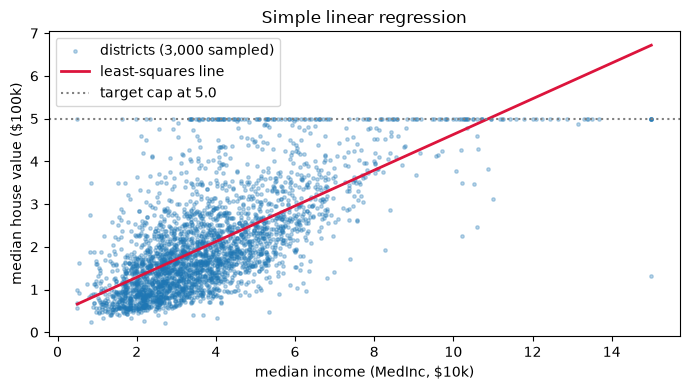

In [3]:
show = rng.choice(len(x_inc), size=3000, replace=False)
grid_inc = np.linspace(x_inc.min(), x_inc.max(), 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_inc[show], y_tr[show], s=6, alpha=0.3, label="districts (3,000 sampled)")
ax.plot(grid_inc, intercept + slope * grid_inc, color="crimson", lw=2, label="least-squares line")
ax.axhline(5.0, ls=":", color="gray", label="target cap at 5.0")
ax.set(xlabel="median income (MedInc, \\$10k)", ylabel="median house value (\\$100k)", title="Simple linear regression")
ax.legend()
plt.tight_layout()
plt.show()

Two things to notice already:
- For one feature, **R² equals the squared correlation**. About half of the variation in house value is explained by income alone.
- The flat row of points at 5.0 is a **capped (censored) target**: the census recorded "\$500,000 or more" as 5.0. A straight line can't follow a ceiling, so the model will systematically over-predict for rich districts. We'll see this again in the residual plots.

### ✍️ Your Turn

Using only `slope` and `intercept` (no `.predict`), compute the predicted median house value for a district with `MedInc = 6.0`. Store it in `pred_6`.

In [4]:
pred_6 = None  # TODO: your code here
check("pred_6", pred_6, simple_model.predict(pd.DataFrame({"MedInc": [6.0]}))[0],
      hint="A line: intercept + slope * x.")

⏳ pred_6: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pred_6 = intercept + slope * 6.0
check("pred_6", pred_6, simple_model.predict(pd.DataFrame({"MedInc": [6.0]}))[0])
```

A prediction is just "start at the intercept, add slope × feature". About 2.97 means roughly \$297,000.
</details>

> 💡 **Interview angle:** "How are the slope and the correlation related?" — $\beta_1 = r \cdot s_y / s_x$. With standardized x and y the slope *is* the correlation, and for simple regression $R^2 = r^2$.

## 2. Multiple Regression and the Normal Equations 🟢

With $p$ features we stack the data into a **design matrix** $X$ of shape $(n, p+1)$: one row per district, one column per feature, plus a first column of 1s for the intercept. The model and the loss are:

$$\hat y = X\beta, \qquad \text{RSS}(\beta) = \lVert y - X\beta \rVert^2 = (y - X\beta)^\top (y - X\beta)$$

**Deriving OLS (a classic interview question).** Take the gradient and set it to zero:

$$\nabla_\beta \text{RSS} = -2X^\top(y - X\beta) = 0 \quad\Longrightarrow\quad X^\top X\,\beta = X^\top y \quad\Longrightarrow\quad \hat\beta = (X^\top X)^{-1} X^\top y$$

The middle equation is the **normal equations**. The loss is a bowl (convex; $X^\top X$ is positive semi-definite), so this stationary point is the global minimum. It is unique when the columns of $X$ are linearly independent.

**How to actually solve it:**
- ❌ `np.linalg.inv(X.T @ X) @ X.T @ y` — explicit inverses are slower and lose precision.
- 🆗 `np.linalg.solve(X.T @ X, X.T @ y)` — fine when $X^\top X$ is well conditioned.
- ✅ `np.linalg.lstsq(X, y)` (SVD) or a QR decomposition — works directly on $X$. Forming $X^\top X$ **squares the condition number** (how much rounding errors get amplified), so these are more accurate. scikit-learn's `LinearRegression` uses SciPy's `lstsq`.

In [5]:
A_train = np.column_stack([np.ones(len(X_train)), X_train.to_numpy()])      # intercept column + 8 features
beta_normal = np.linalg.solve(A_train.T @ A_train, A_train.T @ y_tr)
beta_lstsq, *_ = np.linalg.lstsq(A_train, y_tr, rcond=None)
multi_model = LinearRegression().fit(X_train, y_train)

assert np.allclose(beta_normal, beta_lstsq) and np.allclose(beta_lstsq[1:], multi_model.coef_)
assert np.isclose(beta_lstsq[0], multi_model.intercept_)
print("✅ normal equations, lstsq and LinearRegression agree\n")
print(pd.Series(beta_lstsq, index=["intercept", *X_train.columns]).round(5).to_string())

A_std = np.column_stack([np.ones(len(X_train)), StandardScaler().fit_transform(X_train)])
print(f"\ncondition number of XᵀX: raw features {np.linalg.cond(A_train.T @ A_train):.2e} | "
      f"standardized features {np.linalg.cond(A_std.T @ A_std):.2e}")

✅ normal equations, lstsq and LinearRegression agree

intercept    -37.0278
MedInc         0.4476
HouseAge       0.0096
AveRooms      -0.1248
AveBedrms      0.7945
Population    -0.0000
AveOccup      -0.0034
Latitude      -0.4186
Longitude     -0.4334



condition number of XᵀX: raw features 5.66e+10 | standardized features 4.30e+01


In [6]:
for name, cols in [("simple (MedInc only)", ["MedInc"]), ("multiple (all 8 features)", list(X_train.columns))]:
    model = LinearRegression().fit(X_train[cols], y_train)
    print(f"{name:26s} validation RMSE {root_mean_squared_error(y_val, model.predict(X_val[cols])):.4f} | "
          f"validation R² {r2_score(y_val, model.predict(X_val[cols])):.4f}")

simple (MedInc only)       validation RMSE 0.8368 | validation R² 0.4708
multiple (all 8 features)  validation RMSE 0.7356 | validation R² 0.5911


The extra seven features lower the validation error. The raw design matrix is badly conditioned because `Population` is in the thousands while `AveBedrms` is around 1; standardizing fixes the conditioning (it doesn't change OLS predictions, but it matters for gradient descent and regularization).

### ✍️ Your Turn

Solve the normal equations yourself for the tiny dataset below (the first column is the intercept). Use `np.linalg.solve`. Store the coefficient vector in `beta_tiny`.

In [7]:
X_tiny = np.array([[1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])
y_tiny = np.array([2.0, 3.0, 5.0])
beta_tiny = None  # TODO: your code here
check("beta_tiny", beta_tiny, [1 / 3, 1.5], hint="np.linalg.solve(X_tiny.T @ X_tiny, X_tiny.T @ y_tiny)")

⏳ beta_tiny: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_tiny = np.array([[1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])
y_tiny = np.array([2.0, 3.0, 5.0])
beta_tiny = np.linalg.solve(X_tiny.T @ X_tiny, X_tiny.T @ y_tiny)
check("beta_tiny", beta_tiny, [1 / 3, 1.5])
```

Check by hand: $\bar x = 2$, $\bar y = 10/3$, slope $= \frac{(-1)(-4/3) + 0 + (1)(5/3)}{2} = 1.5$, intercept $= 10/3 - 1.5 \cdot 2 = 1/3$.
</details>

> 💡 **Interview angle:** "Derive the OLS solution. What is its complexity?" — set $\nabla\lVert y-X\beta\rVert^2 = -2X^\top(y-X\beta)=0$ to get $X^\top X\beta = X^\top y$. Forming $X^\top X$ costs $O(np^2)$ and solving it $O(p^3)$; in practice use QR/SVD (`lstsq`) for stability, and gradient descent when $p$ or $n$ is huge.

## 3. The Geometry: OLS Is a Projection 🟡

Picture the target $y$ as **one vector with $n$ entries** (one per row). Every possible prediction $X\beta$ lives in the **column space** of $X$: the flat subspace you can reach by mixing the columns. OLS picks the point in that subspace **closest to $y$**, and the closest point is the **perpendicular (orthogonal) projection**:

```
                y  (the actual targets, a point in n-dimensional space)
                │
                │  e = y − ŷ   residual vector, perpendicular to the plane
                │
 ───────────────ŷ────────────────   the plane of all possible predictions Xβ
                                    (spanned by the columns of X)
```

Consequences you can check numerically:
- The **hat matrix** $H = X(X^\top X)^{-1}X^\top$ maps $y$ to $\hat y = Hy$ ("puts the hat on y").
- $H$ is symmetric and **idempotent** ($H^2 = H$: projecting twice changes nothing), and $\text{trace}(H) = p + 1$, the number of columns.
- The residuals are **orthogonal to every column**: $X^\top e = 0$ (this is exactly the normal equations). With an intercept column, the residuals sum to 0.
- **Pythagoras**: $\lVert y - \bar y\rVert^2 = \lVert \hat y - \bar y\rVert^2 + \lVert e\rVert^2$, i.e. total = explained + residual variation. That is why $R^2 = \text{explained} / \text{total}$ lies between 0 and 1 on the training data.
- The diagonal entries $h_{ii}$ are each row's **leverage** (Section 11).

In [8]:
small_rows = rng.choice(len(X_train), size=500, replace=False)       # H is n×n, so use 500 rows
A_small = A_train[small_rows]
y_small = y_tr[small_rows]

H = A_small @ np.linalg.solve(A_small.T @ A_small, A_small.T)
beta_small, *_ = np.linalg.lstsq(A_small, y_small, rcond=None)
y_hat_small = H @ y_small
e_small = y_small - y_hat_small

print("ŷ = Hy matches Xβ̂        :", np.allclose(y_hat_small, A_small @ beta_small))
print("H symmetric, H² = H       :", np.allclose(H, H.T), np.allclose(H @ H, H, atol=1e-8))
print(f"trace(H)                  : {np.trace(H):.4f}  (= {A_small.shape[1]} columns)")
print(f"max |Xᵀe| (orthogonality) : {np.abs(A_small.T @ e_small).max():.2e}")
print(f"sum of residuals          : {e_small.sum():.2e}")
total = np.sum((y_small - y_small.mean()) ** 2)
explained = np.sum((y_hat_small - y_small.mean()) ** 2)
print(f"total {total:.3f} = explained {explained:.3f} + residual {np.sum(e_small ** 2):.3f} "
      f"→ {np.isclose(total, explained + np.sum(e_small ** 2))}")

ŷ = Hy matches Xβ̂        : True
H symmetric, H² = H       : True True
trace(H)                  : 9.0000  (= 9 columns)
max |Xᵀe| (orthogonality) : 4.36e-08
sum of residuals          : 1.80e-11
total 712.257 = explained 459.678 + residual 252.580 → True


### ✍️ Your Turn

Using the Pythagoras split above, compute **R² = explained / total** for the 500-row fit (from `y_small` and `y_hat_small`). Store it in `r2_geometry`. The checker compares it with `r2_score`.

In [9]:
r2_geometry = None  # TODO: your code here
check("r2_geometry", r2_geometry, r2_score(y_small, y_hat_small),
      hint="np.sum((y_hat_small - y_small.mean())**2) / np.sum((y_small - y_small.mean())**2)")

⏳ r2_geometry: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
r2_geometry = np.sum((y_hat_small - y_small.mean()) ** 2) / np.sum((y_small - y_small.mean()) ** 2)
check("r2_geometry", r2_geometry, r2_score(y_small, y_hat_small))
```

This identity holds for OLS **with an intercept on its own training data**. On new data (or without an intercept) the split breaks, and R² can even be negative.
</details>

> 💡 **Interview angle:** "Give a geometric interpretation of least squares." — $\hat y$ is the orthogonal projection of $y$ onto the column space of $X$; the residual is perpendicular to every feature column ($X^\top e=0$), which is exactly the normal equations. Bonus: residuals are uncorrelated with every feature *by construction*, so "residuals vs feature" plots must look for curves, not straight trends.

## 4. Gradient Descent: Batch, Mini-Batch, and SGD 🟡

The closed form needs $X^\top X$ in memory and an $O(p^3)$ solve. **Gradient descent** instead walks downhill on the loss. With the mean squared error $J(\beta) = \frac{1}{n}\lVert X\beta - y\rVert^2$:

$$\nabla J(\beta) = \frac{2}{n} X^\top (X\beta - y), \qquad \beta \leftarrow \beta - \eta\,\nabla J(\beta)$$

| Flavour | Rows per update | Updates per epoch | Behaviour |
|---|---|---|---|
| **Batch** GD | all $n$ | 1 | smooth, exact gradient, slow per step on big data |
| **Mini-batch** GD | e.g. 32–1024 | $n / b$ | noisy but fast; vectorized; what deep learning uses |
| **Stochastic** GD (SGD) | 1 | $n$ | very noisy; needs a decaying learning rate to settle |

**The learning rate η.** The MSE is a quadratic bowl whose steepest curvature is $L = \lambda_{\max}\!\left(\frac{2}{n}X^\top X\right)$. Batch GD converges only if $\eta < 2/L$. Too small crawls, too big **diverges**. Unscaled features make $L$ enormous (and the bowl a long thin valley), which is why you **standardize before gradient descent**.

largest curvature L = 4.046 → batch GD converges only for lr < 2/L = 0.494


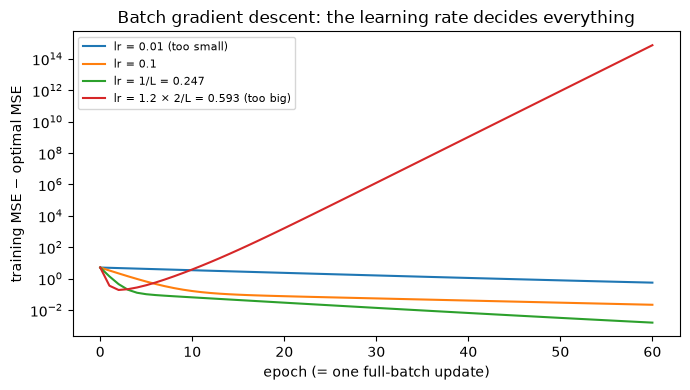

lr = 0.01 (too small)            excess MSE after 60 epochs: 5.569e-01 → still descending
lr = 0.1                         excess MSE after 60 epochs: 2.168e-02 → still descending
lr = 1/L = 0.247                 excess MSE after 60 epochs: 1.580e-03 → still descending
lr = 1.2 × 2/L = 0.593 (too big) excess MSE after 60 epochs: 7.399e+14 → DIVERGED


In [10]:
gd_scaler = StandardScaler().fit(X_train)
Z_train = np.column_stack([np.ones(len(X_train)), gd_scaler.transform(X_train)])
Z_val = np.column_stack([np.ones(len(X_val)), gd_scaler.transform(X_val)])
beta_star, *_ = np.linalg.lstsq(Z_train, y_tr, rcond=None)                     # the exact optimum
mse_star = np.mean((Z_train @ beta_star - y_tr) ** 2)


def mse_grad(Z, y, beta):
    """Gradient of the mean squared error (1/n)·||Zβ − y||² with respect to β."""
    return 2 / len(y) * Z.T @ (Z @ beta - y)


def gradient_descent(Z, y, lr, epochs, batch_size=None, seed=SEED):
    """batch_size=None → full batch. Returns β and the full training MSE after every epoch."""
    rng_gd = np.random.default_rng(seed)
    n = len(y)
    size = n if batch_size is None else batch_size
    beta = np.zeros(Z.shape[1])
    history = [np.mean((Z @ beta - y) ** 2)]
    for _ in range(epochs):
        order = rng_gd.permutation(n) if size < n else np.arange(n)   # reshuffle every epoch
        for start in range(0, n, size):
            rows = order[start:start + size]
            beta = beta - lr * mse_grad(Z[rows], y[rows], beta)
        history.append(np.mean((Z @ beta - y) ** 2))
    return beta, np.array(history)


L_curv = np.linalg.eigvalsh(2 / len(y_tr) * Z_train.T @ Z_train).max()
print(f"largest curvature L = {L_curv:.3f} → batch GD converges only for lr < 2/L = {2 / L_curv:.3f}")

learning_rates = {"lr = 0.01 (too small)": 0.01, "lr = 0.1": 0.1, f"lr = 1/L = {1 / L_curv:.3f}": 1 / L_curv,
                  f"lr = 1.2 × 2/L = {2.4 / L_curv:.3f} (too big)": 2.4 / L_curv}
lr_histories = {name: gradient_descent(Z_train, y_tr, lr, epochs=60)[1] for name, lr in learning_rates.items()}

fig, ax = plt.subplots(figsize=(7, 4))
for name, hist in lr_histories.items():
    ax.plot(np.maximum(hist - mse_star, 1e-12), label=name)
ax.set(yscale="log", xlabel="epoch (= one full-batch update)", ylabel="training MSE − optimal MSE",
       title="Batch gradient descent: the learning rate decides everything")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
for name, hist in lr_histories.items():
    status = "DIVERGED" if hist[-1] > hist[0] else ("converged" if hist[-1] - mse_star < 1e-6 else "still descending")
    print(f"{name:32s} excess MSE after 60 epochs: {hist[-1] - mse_star:.3e} → {status}")

squared row norms ‖zᵢ‖²: median 5.1, max 10,807 (a district with AveOccup = 1,243) → safe single-row lr < 9.25e-05


                                    updates/epoch  excess MSE after epoch 1  excess MSE after epoch 8  val RMSE   seconds
flavour                                                                                                                  
batch (n rows, lr=1/L)                          1                    1.3928                    0.0755    0.7706 2.710e-03
mini-batch (32 rows, lr=0.01)                 484                    0.0312                    0.0175    0.7340    0.0194
SGD (1 row, lr=0.001)                       15480                   32.5056                 4.249e+24 2.932e+11    0.3724
SGD (1 row, lr=1/max‖zᵢ‖²=9.3e-05)          15480                    0.1091                 5.399e-03    0.7368    0.4085
closed-form OLS validation RMSE: 0.7356


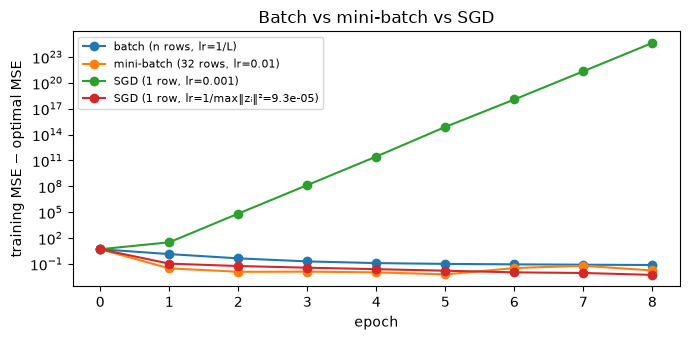

→ Diverged: ['SGD (1 row, lr=0.001)'].
→ After ONE pass over the data, 'mini-batch (32 rows, lr=0.01)' is closest to the optimum among the stable runs: many cheap noisy updates beat one exact update.
→ With a constant learning rate, mini-batch and SGD then hover near a noise floor; a decaying learning rate (SGDRegressor's default) or taming extreme features (Section 5) helps.


In [11]:
row_sq_norms = np.sum(Z_train ** 2, axis=1)
safe_sgd_lr = 1 / row_sq_norms.max()          # a one-row step is stable only if lr < 1/‖zᵢ‖² for EVERY row
print(f"squared row norms ‖zᵢ‖²: median {np.median(row_sq_norms):.1f}, max {row_sq_norms.max():,.0f} "
      f"(a district with AveOccup = {X_train['AveOccup'].iloc[row_sq_norms.argmax()]:,.0f}) → safe single-row lr < {safe_sgd_lr:.2e}")
flavours = {"batch (n rows, lr=1/L)": dict(batch_size=None, lr=1 / L_curv),
            "mini-batch (32 rows, lr=0.01)": dict(batch_size=32, lr=0.01),
            "SGD (1 row, lr=0.001)": dict(batch_size=1, lr=0.001),
            f"SGD (1 row, lr=1/max‖zᵢ‖²={safe_sgd_lr:.1e})": dict(batch_size=1, lr=safe_sgd_lr)}
flavour_rows, flavour_hist = [], {}
for name, cfg in flavours.items():
    start = time.perf_counter()
    beta_f, hist = gradient_descent(Z_train, y_tr, lr=cfg["lr"], epochs=8, batch_size=cfg["batch_size"])
    seconds = time.perf_counter() - start
    flavour_hist[name] = hist
    size = len(y_tr) if cfg["batch_size"] is None else cfg["batch_size"]
    flavour_rows.append({"flavour": name, "updates/epoch": math.ceil(len(y_tr) / size),
                         "excess MSE after epoch 1": hist[1] - mse_star, "excess MSE after epoch 8": hist[-1] - mse_star,
                         "val RMSE": root_mean_squared_error(y_val, Z_val @ beta_f), "seconds": seconds})
flavour_table = pd.DataFrame(flavour_rows).set_index("flavour")
print(flavour_table.to_string(float_format=lambda v: f"{v:.3e}" if (abs(v) < 0.01 or abs(v) >= 1e4) else f"{v:.4f}"))
print(f"closed-form OLS validation RMSE: {root_mean_squared_error(y_val, Z_val @ beta_star):.4f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, hist in flavour_hist.items():
    ax.plot(np.maximum(hist - mse_star, 1e-12), marker="o", label=name)
ax.set(yscale="log", xlabel="epoch", ylabel="training MSE − optimal MSE", title="Batch vs mini-batch vs SGD")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

diverged = [name for name, hist in flavour_hist.items() if not np.isfinite(hist[-1]) or hist[-1] > hist[0]]
stable = flavour_table.drop(index=diverged)
print(f"→ Diverged: {diverged or 'none'}.")
print(f"→ After ONE pass over the data, '{stable['excess MSE after epoch 1'].idxmin()}' is closest to the optimum among the stable runs: "
      "many cheap noisy updates beat one exact update.")
print("→ With a constant learning rate, mini-batch and SGD then hover near a noise floor; a decaying learning rate "
      "(SGDRegressor's default) or taming extreme features (Section 5) helps.")

**Why did one SGD run explode?** A single-row step changes that row's prediction by $2\eta\lVert z_i\rVert^2$ times its error. If that factor exceeds 2, the row overshoots further every time it is visited. California has a district whose standardized `AveOccup` is about 100 standard deviations from the mean, so $\lVert z_i\rVert^2$ is in the thousands. Averaging over a mini-batch divides that kick by the batch size, and a learning rate below $1/\max_i\lVert z_i\rVert^2$ (or taming extreme features first) keeps SGD stable. You rarely see this on textbook data, but it's common on real data.

### ✍️ Your Turn

Compute the MSE gradient **at β = 0** for the tiny dataset from Section 2 (`X_tiny`, `y_tiny`) using the formula $\frac{2}{n}X^\top(X\beta - y)$. Don't call `mse_grad`. Store it in `grad_at_zero`.

In [12]:
grad_at_zero = None  # TODO: your code here
check("grad_at_zero", grad_at_zero, [-20 / 3, -46 / 3], hint="At β = 0 the prediction is 0, so the gradient is 2/n · Xᵀ(0 − y).")

⏳ grad_at_zero: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_tiny = np.array([[1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])
y_tiny = np.array([2.0, 3.0, 5.0])
grad_at_zero = 2 / len(y_tiny) * X_tiny.T @ (X_tiny @ np.zeros(2) - y_tiny)
check("grad_at_zero", grad_at_zero, [-20 / 3, -46 / 3])
```

Both components are negative, so a gradient step *increases* both coefficients — towards the solution $[1/3, 1.5]$.
</details>

> 💡 **Interview angle:** "Why use gradient descent when OLS has a closed form?" — the closed form costs $O(np^2 + p^3)$ and needs $X^\top X$ in memory; GD costs $O(np)$ per epoch, streams data in mini-batches, and generalizes to losses with no closed form (Lasso, logistic, neural nets). Mention: standardize features, and the learning rate must satisfy $\eta < 2/L$.

## 5. Assumptions and Diagnostics 🟡

OLS *always* returns coefficients. Whether you can **trust** them depends on assumptions about the errors $\varepsilon = y - X\beta$:

| Assumption | Plain English | If it breaks… | Diagnostic | Typical fix |
|---|---|---|---|---|
| **Linearity** | the average of y really is a weighted sum of the features | predictions are biased in some regions | residuals vs fitted / vs each feature show curves | transform features (log, splines), add interactions |
| **Independent errors** | one row's error tells you nothing about another's | standard errors are too small, p-values too optimistic | Durbin–Watson (time/space order), residual maps | clustered / HAC standard errors, time-aware models |
| **Homoscedasticity** | errors have the same spread everywhere | coefficients OK, but standard errors and intervals are wrong | residual funnel, **Breusch–Pagan** test | robust (HC3) standard errors, log target, weighted LS |
| **Normal errors** | errors are bell-shaped | small-sample p-values and prediction intervals are off | **Q–Q plot**, Jarque–Bera | larger n (CLT), transform y, bootstrap |
| **Low multicollinearity** | features aren't near copies of each other | coefficients unstable, huge standard errors; predictions still fine | correlation matrix, **VIF** | drop/combine features, Ridge, PCA |

Key idea: **for prediction** you mostly care about linearity (and a good validation score). **For inference** (p-values, confidence intervals, "what is the effect of X?") you need all of them.

We fit OLS with `statsmodels` on the California training split and run every check.

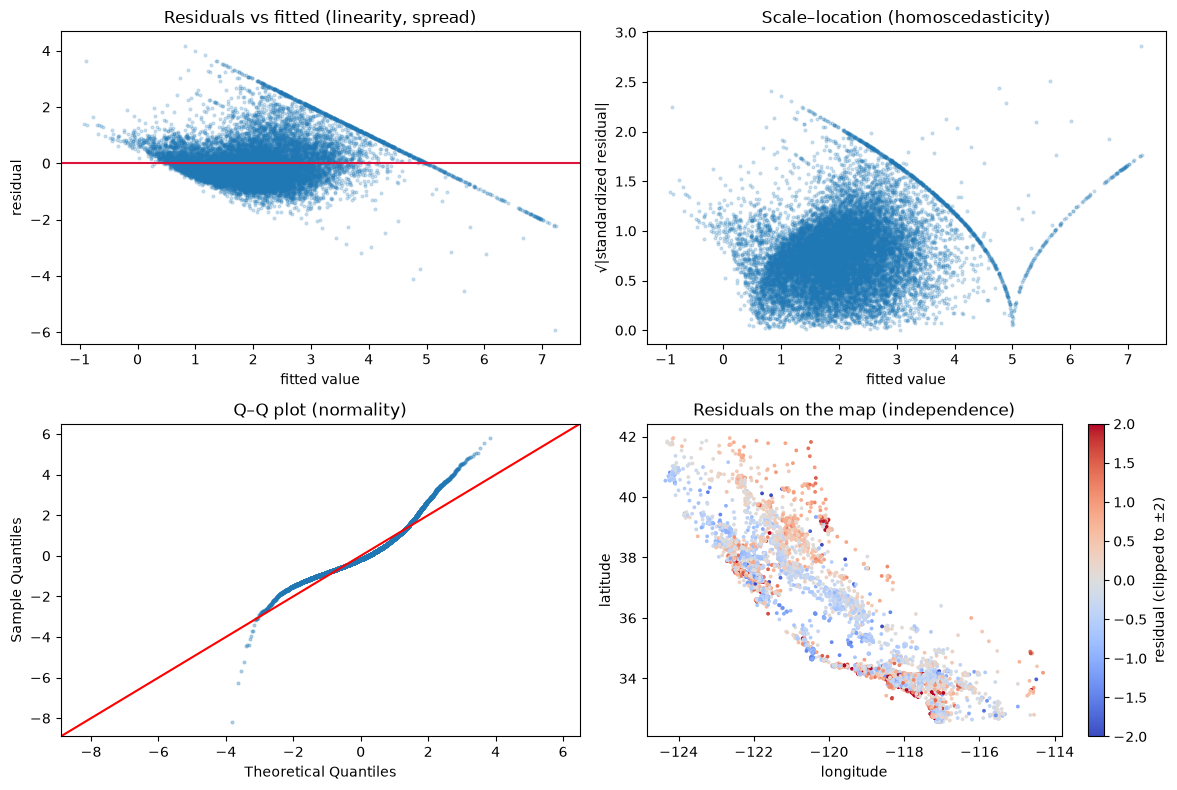

Breusch–Pagan : LM = 1120.6, p = 1.35e-236 → heteroscedastic (spread changes with the features)
Jarque–Bera   : JB = 9013, p = 0.00e+00, skew = 1.07, kurtosis = 6.06 (normal: 0 and 3) → residuals are not normal
Durbin–Watson : 0.939 in file order vs 1.963 in shuffled order (≈2 means no autocorrelation)
→ Neighbouring districts in the file have similar errors: the errors are spatially correlated.


In [13]:
ols_cal = sm.OLS(y_train, sm.add_constant(X_train)).fit()
fitted, resid = ols_cal.fittedvalues, ols_cal.resid
student = OLSInfluence(ols_cal).resid_studentized_internal

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].scatter(fitted, resid, s=4, alpha=0.2)
axes[0, 0].axhline(0, color="crimson")
axes[0, 0].set(xlabel="fitted value", ylabel="residual", title="Residuals vs fitted (linearity, spread)")
axes[0, 1].scatter(fitted, np.sqrt(np.abs(student)), s=4, alpha=0.2)
axes[0, 1].set(xlabel="fitted value", ylabel="√|standardized residual|", title="Scale–location (homoscedasticity)")
sm.qqplot(resid.to_numpy(), line="45", fit=True, ax=axes[1, 0], markersize=2, alpha=0.3)
axes[1, 0].set_title("Q–Q plot (normality)")
sc = axes[1, 1].scatter(X_train["Longitude"], X_train["Latitude"], c=resid.clip(-2, 2), cmap="coolwarm", s=3)
axes[1, 1].set(xlabel="longitude", ylabel="latitude", title="Residuals on the map (independence)")
fig.colorbar(sc, ax=axes[1, 1], label="residual (clipped to ±2)")
plt.tight_layout()
plt.show()

bp_lm, bp_p, _, _ = het_breuschpagan(resid, ols_cal.model.exog)
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
dw_file_order = durbin_watson(resid.sort_index())      # the rows as stored in the file (grouped geographically)
dw_shuffled = durbin_watson(resid)                     # train_test_split already shuffled the rows
print(f"Breusch–Pagan : LM = {bp_lm:.1f}, p = {bp_p:.2e} → "
      f"{'heteroscedastic (spread changes with the features)' if bp_p < 0.05 else 'no evidence of heteroscedasticity'}")
print(f"Jarque–Bera   : JB = {jb_stat:.0f}, p = {jb_p:.2e}, skew = {skew:.2f}, kurtosis = {kurt:.2f} (normal: 0 and 3) → "
      f"{'residuals are not normal' if jb_p < 0.05 else 'consistent with normal'}")
print(f"Durbin–Watson : {dw_file_order:.3f} in file order vs {dw_shuffled:.3f} in shuffled order (≈2 means no autocorrelation)")
print("→ Neighbouring districts in the file have similar errors: the errors are spatially correlated."
      if dw_file_order < 1.5 else "→ No strong autocorrelation in file order.")

How to read the four panels:
- **Residuals vs fitted:** the diagonal line of points at the upper right is the \$500k cap (actual = 5.0, so residual = 5 − fitted). There is also curvature, and the spread grows with the fitted value.
- **Scale–location:** a rising trend means the error spread grows (heteroscedasticity), which Breusch–Pagan confirms.
- **Q–Q plot:** the tails leave the 45° line, so the errors are heavier-tailed than a normal distribution. With 15,000 rows the CLT keeps coefficient inference roughly valid, but prediction intervals for single districts will be off.
- **Map:** red and blue clusters along the coast and in the Bay Area show errors that are **not independent**. Durbin–Watson only detects this when rows are in a meaningful order (here, file order is roughly geographic), which is a common trap.

Now two **experiments** that show what breaks and what fixes it.

In [14]:
# Experiment 1 — linearity: log-transform the heavily skewed features and compare validation RMSE
skewed = ["AveRooms", "AveBedrms", "Population", "AveOccup"]


def log_skewed(X):
    return X.assign(**{col: np.log(X[col]) for col in skewed})


print("skewness of raw features:", X_train[skewed].skew().round(1).to_dict())
rmse_raw = root_mean_squared_error(y_val, LinearRegression().fit(X_train, y_train).predict(X_val))
rmse_log = root_mean_squared_error(y_val, LinearRegression().fit(log_skewed(X_train), y_train).predict(log_skewed(X_val)))
print(f"validation RMSE: raw features {rmse_raw:.4f} | log of skewed features {rmse_log:.4f} → "
      f"{'the transform fixed part of the non-linearity' if rmse_log < rmse_raw else 'no gain from the transform'}")

# Experiment 2 — heteroscedasticity: classical vs robust (HC3) standard errors
ols_hc3 = sm.OLS(y_train, sm.add_constant(X_train)).fit(cov_type="HC3")
se_compare = pd.DataFrame({"classical SE": ols_cal.bse, "HC3 robust SE": ols_hc3.bse})
se_compare["robust / classical"] = se_compare["HC3 robust SE"] / se_compare["classical SE"]
print("\n", se_compare.round(5).to_string())
worst = se_compare["robust / classical"].drop("const").idxmax()
print(f"→ Same coefficients, but the honest (HC3) standard error of {worst} is "
      f"{se_compare.loc[worst, 'robust / classical']:.1f}× the classical one: classical p-values were overconfident.")

skewness of raw features: {'AveRooms': 18.8, 'AveBedrms': 23.4, 'Population': 5.4, 'AveOccup': 85.3}
validation RMSE: raw features 0.7356 | log of skewed features 0.6717 → the transform fixed part of the non-linearity

             classical SE  HC3 robust SE  robust / classical
const         7.5315e-01         0.9052              1.2019
MedInc        4.8500e-03         0.0092              1.9048
HouseAge      5.1000e-04         0.0006              1.1525
AveRooms      6.8200e-03         0.0140              2.0434
AveBedrms     3.4490e-02         0.0770              2.2319
Population    1.0000e-05         0.0000              0.8692
AveOccup      4.9000e-04         0.0013              2.7534
Latitude      8.2200e-03         0.0103              1.2464
Longitude     8.6000e-03         0.0105              1.2176
→ Same coefficients, but the honest (HC3) standard error of AveOccup is 2.8× the classical one: classical p-values were overconfident.


In [15]:
# Experiment 3 — multicollinearity: VIF, and how unstable coefficients are across bootstrap resamples
exog = sm.add_constant(X_train).to_numpy()
vif = pd.Series([variance_inflation_factor(exog, i) for i in range(1, exog.shape[1])], index=X_train.columns)

# Extreme AveOccup/AveRooms rows would dominate a bootstrap (Section 11), so the experiment uses the
# log-transformed skewed features from Experiment 1, standardized so the coefficients are comparable.
X_log_train = log_skewed(X_train)
exog_log = sm.add_constant(X_log_train).to_numpy()
vif_log = pd.Series([variance_inflation_factor(exog_log, i) for i in range(1, exog_log.shape[1])], index=X_train.columns)
Z_log = StandardScaler().fit_transform(X_log_train)
boot_coefs = []
boot_rng = np.random.default_rng(SEED)
for _ in range(200):
    rows = boot_rng.choice(len(y_tr), size=2000, replace=True)
    A_boot = np.column_stack([np.ones(2000), Z_log[rows]])
    boot_coefs.append(np.linalg.lstsq(A_boot, y_tr[rows], rcond=None)[0][1:])
multicol = pd.DataFrame({"VIF (raw features)": vif, "VIF (log-skewed features)": vif_log,
                         "bootstrap SD of standardized coef": np.std(boot_coefs, axis=0)})
print(multicol.sort_values("VIF (log-skewed features)", ascending=False).round(3).to_string())
rho = stats.spearmanr(multicol["VIF (log-skewed features)"], multicol["bootstrap SD of standardized coef"]).statistic
print(f"\nSpearman correlation between VIF and coefficient instability: {rho:.2f} → "
      f"{'the higher the VIF, the more a coefficient swings between resamples' if rho > 0.5 else 'instability is not explained by VIF alone here'}")
print(f"raw VIF > 5: {list(vif[vif > 5].index)} | log-skewed VIF > 5: {list(vif_log[vif_log > 5].index)}")

            VIF (raw features)  VIF (log-skewed features)  bootstrap SD of standardized coef
Latitude                 9.147                      9.637                              0.057
Longitude                8.821                      9.197                              0.055
AveRooms                 8.117                      3.057                              0.036
MedInc                   2.529                      2.489                              0.041
AveBedrms                6.805                      1.904                              0.032
HouseAge                 1.236                      1.228                              0.022
Population               1.134                      1.180                              0.023
AveOccup                 1.010                      1.090                              0.032

Spearman correlation between VIF and coefficient instability: 0.88 → the higher the VIF, the more a coefficient swings between resamples
raw VIF > 5: ['AveRooms',

**VIF** (variance inflation factor) for feature $j$ is $1/(1 - R_j^2)$, where $R_j^2$ comes from regressing feature $j$ on all the *other* features. VIF = 1 means no overlap; above 5–10 is a warning sign. `Latitude`/`Longitude` travel together (and so do `AveRooms`/`AveBedrms` on the raw scale), so the data can't tell which of the pair deserves the credit, and the high-VIF coefficients swing most across resamples while predictions barely change. Taking logs lowered the room-count VIFs: transformations change collinearity too.

### ✍️ Your Turn

Compute the VIF of `MedInc` **yourself**: regress `MedInc` on the other 7 features with `LinearRegression` (training data), take its $R^2$, and return $1/(1-R^2)$. Store it in `vif_medinc`.

In [16]:
vif_medinc = None  # TODO: your code here
check("vif_medinc", vif_medinc, vif["MedInc"], hint="others = X_train.drop(columns='MedInc'); r2 = LinearRegression().fit(others, X_train['MedInc']).score(...)")

⏳ vif_medinc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
others = X_train.drop(columns="MedInc")
r2_medinc = LinearRegression().fit(others, X_train["MedInc"]).score(others, X_train["MedInc"])
vif_medinc = 1 / (1 - r2_medinc)
check("vif_medinc", vif_medinc, vif["MedInc"])
```

`variance_inflation_factor` does exactly this regression, which is why the design matrix you pass it **must include a constant column**. Without it, VIFs come out wrong.
</details>

> 💡 **Interview angle:** "What are the assumptions of linear regression, and which matter for prediction?" — linearity, independent errors, constant variance, normal errors, no perfect multicollinearity. Prediction mainly needs linearity and a representative validation set. Heteroscedasticity and dependence break **standard errors** (use HC3/clustered SEs), non-normality matters for small-sample intervals, and multicollinearity makes **individual coefficients** unstable without hurting predictions.

## 6. Interpreting Coefficients: Raw vs Standardized 🟢

A coefficient answers: **"If this feature goes up by one unit and every other feature stays the same, how much does the prediction change?"**

- **Raw coefficients** are in the feature's own units: \$100k per \$10k of income, per year of house age, per person. You **can't compare their sizes**, because the units differ (one person vs one year).
- **Standardized coefficients** come from features rescaled to mean 0 and standard deviation 1. They read "change per **one standard deviation**", so their sizes are comparable. Conversion: $\beta^{\text{std}}_j = \beta^{\text{raw}}_j \times \text{SD}(x_j)$.
- **"Holding the others fixed"** is the part people forget. With correlated features that can describe an unrealistic situation, and a coefficient can even **flip sign** compared with the feature on its own.

            raw coef (per unit)  feature SD  standardized coef (per SD)  rank by |raw|  rank by |standardized|
MedInc                  0.44760     1.90373                     0.85211              2                       3
HouseAge                0.00957    12.61092                     0.12066              6                       6
AveRooms               -0.12476     2.42157                    -0.30211              5                       5
AveBedrms               0.79447     0.43879                     0.34861              1                       4
Population             -0.00000  1142.89394                    -0.00164              8                       8
AveOccup               -0.00344    11.95545                    -0.04116              7                       7
Latitude               -0.41856     2.13388                    -0.89315              4                       1
Longitude              -0.43341     2.00238                    -0.86784              3                       2


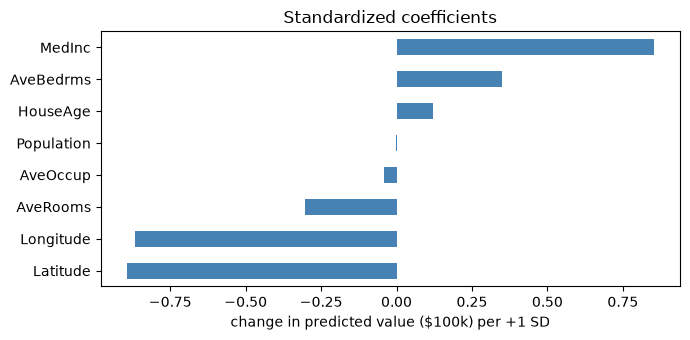

In [17]:
std_model = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
feature_sd = X_train.std(ddof=0)
coef_view = pd.DataFrame({"raw coef (per unit)": multi_model.coef_,
                          "feature SD": feature_sd,
                          "standardized coef (per SD)": std_model[-1].coef_}, index=X_train.columns)
assert np.allclose(coef_view["raw coef (per unit)"] * coef_view["feature SD"], coef_view["standardized coef (per SD)"])
coef_view["rank by |raw|"] = coef_view["raw coef (per unit)"].abs().rank(ascending=False).astype(int)
coef_view["rank by |standardized|"] = coef_view["standardized coef (per SD)"].abs().rank(ascending=False).astype(int)
print(coef_view.to_string(float_format=lambda v: f"{v:.5f}"))

fig, ax = plt.subplots(figsize=(7, 3.5))
coef_view["standardized coef (per SD)"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set(xlabel="change in predicted value (\\$100k) per +1 SD", title="Standardized coefficients")
plt.tight_layout()
plt.show()

In [18]:
flip = pd.DataFrame({"alone (simple regression)": {f: LinearRegression().fit(X_train[[f]], y_train).coef_[0] for f in X_train.columns},
                     "with all 8 features": pd.Series(multi_model.coef_, index=X_train.columns)})
flip["sign flipped?"] = np.sign(flip.iloc[:, 0]).ne(np.sign(flip.iloc[:, 1])) & flip.abs().min(axis=1).gt(1e-4)
print(flip.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\ncorrelation(AveRooms, AveBedrms) = {X_train['AveRooms'].corr(X_train['AveBedrms']):.2f}")
print("features whose sign flips once the others are included:", flip.index[flip["sign flipped?"]].tolist())

            alone (simple regression)  with all 8 features  sign flipped?
MedInc                         0.4179               0.4476          False
HouseAge                       0.0095               0.0096          False
AveRooms                       0.0748              -0.1248           True
AveBedrms                     -0.1249               0.7945           True
Population                    -0.0000              -0.0000          False
AveOccup                      -0.0021              -0.0034          False
Latitude                      -0.0771              -0.4186          False
Longitude                     -0.0273              -0.4334          False

correlation(AveRooms, AveBedrms) = 0.84
features whose sign flips once the others are included: ['AveRooms', 'AveBedrms']


`AveBedrms` on its own and `AveBedrms` "holding `AveRooms` fixed" are **different questions**. Rooms and bedrooms rise together (correlation above), so the multiple-regression coefficient describes adding bedrooms *without adding rooms*, which is rare in the data. Neither number is a bug, and neither is a causal effect. That is why we check VIF before telling a stakeholder "bedrooms increase value".

### ✍️ Your Turn

Recover the **raw** coefficient of `HouseAge` from the standardized pipeline `std_model` (don't use `multi_model`). Store it in `raw_houseage`.

In [19]:
raw_houseage = None  # TODO: your code here
check("raw_houseage", raw_houseage, multi_model.coef_[list(X_train.columns).index("HouseAge")],
      hint="standardized coef / SD of the feature (ddof=0, as StandardScaler uses).")

⏳ raw_houseage: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
j = list(X_train.columns).index("HouseAge")
raw_houseage = std_model[-1].coef_[j] / X_train["HouseAge"].std(ddof=0)
check("raw_houseage", raw_houseage, multi_model.coef_[list(X_train.columns).index("HouseAge")])
```

`StandardScaler` divides by the population SD (`ddof=0`). Pandas' `.std()` defaults to `ddof=1`, a classic off-by-a-little bug.
</details>

> 💡 **Interview angle:** "Can you rank feature importance by coefficient size?" — only for standardized features, and only if they aren't strongly correlated. Raw coefficients depend on units, and correlated features share (and can flip) credit. Prefer standardized coefficients with confidence intervals, or permutation importance on validation data.

## 7. Inference With statsmodels vs Prediction With scikit-learn 🟡

Both libraries find the **same coefficients**. They answer different questions:

| | `statsmodels` (`OLS`, `smf.ols`) | scikit-learn (`LinearRegression`, `Ridge`, …) |
|---|---|---|
| Main question | *"What is the effect of X, and how sure are we?"* | *"How well can I predict new rows?"* |
| Output | coefficients **+ standard errors, t, p-values, CIs**, R², adjusted R², F-test, AIC/BIC, diagnostics | coefficients, `predict`, `score` |
| Formulas & categoricals | R-style formulas: `y ~ x1 * C(group)` | `ColumnTransformer` + `OneHotEncoder` |
| Robust / clustered SEs | `fit(cov_type="HC3")`, `"cluster"`, `"HAC"` | — |
| Workflow | whole dataset, model checking | pipelines, CV, hyperparameter search, deployment |
| Regularization | `fit_regularized` (no valid p-values) | first-class (`RidgeCV`, `LassoCV`, …) |

**Reading the table.** For each coefficient $\hat\beta_j$:
- **std err** $= \sqrt{\hat\sigma^2 \,[(X^\top X)^{-1}]_{jj}}$ with $\hat\sigma^2 = \text{RSS}/(n-p-1)$: how much $\hat\beta_j$ would wobble across repeated samples.
- **t** $= \hat\beta_j / \text{SE}_j$, and the **p-value** is the probability of a |t| at least this large *if the true coefficient were 0* (and the assumptions held). It is **not** the probability that the feature is useless.
- **95% CI** $= \hat\beta_j \pm t_{0.975,\,n-p-1}\cdot \text{SE}_j$.
- **Adjusted R²** $= 1 - (1-R^2)\frac{n-1}{n-p-1}$ only goes up when a new feature helps more than chance would.

In [20]:
print(ols_cal.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     3023.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:57:20   Log-Likelihood:                -16912.
No. Observations:               15480   AIC:                         3.384e+04
Df Residuals:                   15471   BIC:                         3.391e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0278      0.753    -49.164      0.0

In [21]:
coef_table = pd.concat([ols_cal.params, ols_cal.bse, ols_cal.tvalues, ols_cal.pvalues, ols_cal.conf_int()], axis=1)
coef_table.columns = ["coef", "std err", "t", "p-value", "CI 2.5%", "CI 97.5%"]
assert np.allclose(ols_cal.params.drop("const"), multi_model.coef_)       # same coefficients as scikit-learn
print(coef_table.to_string(float_format=lambda v: f"{v:.3g}"))
print(f"\nR² {ols_cal.rsquared:.4f} | adjusted R² {ols_cal.rsquared_adj:.4f} | F-test p = {ols_cal.f_pvalue:.1e} | n = {int(ols_cal.nobs)}")
not_significant = coef_table.index[coef_table["p-value"] >= 0.05].tolist()
print("coefficients NOT significant at 5% (classical SEs):", not_significant or "none")
hc3_not_significant = ols_hc3.pvalues.index[ols_hc3.pvalues >= 0.05].tolist()
print("coefficients NOT significant at 5% (robust HC3 SEs):", hc3_not_significant or "none")

                coef  std err      t   p-value  CI 2.5%  CI 97.5%
const            -37    0.753  -49.2         0    -38.5     -35.6
MedInc         0.448  0.00485   92.4         0    0.438     0.457
HouseAge     0.00957 0.000511   18.7  2.95e-77  0.00857    0.0106
AveRooms      -0.125  0.00682  -18.3  7.12e-74   -0.138    -0.111
AveBedrms      0.794   0.0345     23 1.68e-115    0.727     0.862
Population -1.44e-06  5.4e-06 -0.266      0.79 -1.2e-05  9.15e-06
AveOccup    -0.00344 0.000488  -7.06  1.73e-12  -0.0044  -0.00249
Latitude      -0.419  0.00822  -50.9         0   -0.435    -0.402
Longitude     -0.433   0.0086  -50.4         0    -0.45    -0.417

R² 0.6099 | adjusted R² 0.6097 | F-test p = 0.0e+00 | n = 15480
coefficients NOT significant at 5% (classical SEs): ['Population']
coefficients NOT significant at 5% (robust HC3 SEs): ['Population']


**Experiment: R² vs adjusted R² with pure-noise features.** We append 40 columns of random numbers (synthetic on purpose: we *know* they are useless) and refit.

In [22]:
noise_rng = np.random.default_rng(SEED)
n_noise = 40
noise_cols = [f"noise_{i}" for i in range(n_noise)]
X_noisy_train = pd.concat([X_train, pd.DataFrame(noise_rng.normal(size=(len(X_train), n_noise)), index=X_train.index, columns=noise_cols)], axis=1)
X_noisy_val = pd.concat([X_val, pd.DataFrame(noise_rng.normal(size=(len(X_val), n_noise)), index=X_val.index, columns=noise_cols)], axis=1)
ols_noisy = sm.OLS(y_train, sm.add_constant(X_noisy_train)).fit()

noise_compare = pd.DataFrame({
    "8 real features": [ols_cal.rsquared, ols_cal.rsquared_adj,
                        r2_score(y_val, ols_cal.predict(sm.add_constant(X_val, has_constant="add")))],
    "+ 40 noise features": [ols_noisy.rsquared, ols_noisy.rsquared_adj,
                            r2_score(y_val, ols_noisy.predict(sm.add_constant(X_noisy_val, has_constant="add")))],
}, index=["training R²", "adjusted R²", "validation R²"])
print(noise_compare.round(5).to_string())
false_hits = int((ols_noisy.pvalues[noise_cols] < 0.05).sum())
print(f"\n→ training R² rose by {noise_compare.iloc[0, 1] - noise_compare.iloc[0, 0]:+.5f} although the new columns are pure noise; "
      f"adjusted R² changed by {noise_compare.iloc[1, 1] - noise_compare.iloc[1, 0]:+.5f}.")
print(f"→ {false_hits} of {n_noise} noise features have p < 0.05 (about {0.05 * n_noise:.0f} expected by chance): "
      "test many features and some will look 'significant'.")

               8 real features  + 40 noise features
training R²             0.6099               0.6108
adjusted R²             0.6097               0.6096
validation R²           0.5910               0.5904

→ training R² rose by +0.00093 although the new columns are pure noise; adjusted R² changed by -0.00008.
→ 1 of 40 noise features have p < 0.05 (about 2 expected by chance): test many features and some will look 'significant'.


**Confidence interval vs prediction interval.** A **confidence interval** for the *mean* prediction says where the average value of all districts like this one lies (narrow). A **prediction interval** says where *one new district's* value will fall: it adds the irreducible noise $\hat\sigma^2$, so it is much wider. Let's check how often validation districts actually land inside their 95% prediction interval.

In [23]:
pred_frame = ols_cal.get_prediction(sm.add_constant(X_val, has_constant="add")).summary_frame(alpha=0.05)
inside = (y_val >= pred_frame["obs_ci_lower"]) & (y_val <= pred_frame["obs_ci_upper"])
print(f"average width: 95% CI for the mean {(pred_frame['mean_ci_upper'] - pred_frame['mean_ci_lower']).mean():.3f} | "
      f"95% prediction interval {(pred_frame['obs_ci_upper'] - pred_frame['obs_ci_lower']).mean():.3f} ($100k)")
print(f"overall coverage of the 95% prediction interval on validation: {inside.mean():.1%}")
coverage_by_bin = inside.groupby(pd.qcut(pred_frame["mean"], 5, labels=["lowest 20%", "20-40%", "40-60%", "60-80%", "highest 20%"]),
                                 observed=True).mean()
print("coverage by predicted-value quintile:\n", coverage_by_bin.map("{:.1%}".format).to_string())
spread = coverage_by_bin.max() - coverage_by_bin.min()
print(f"→ coverage varies by {spread:.1%} across quintiles: one constant σ doesn't fit heteroscedastic errors, "
      "so intervals are too wide for some districts and too narrow for others." if spread > 0.05 else
      "→ coverage is similar in every quintile.")

average width: 95% CI for the mean 0.057 | 95% prediction interval 2.830 ($100k)
overall coverage of the 95% prediction interval on validation: 94.2%
coverage by predicted-value quintile:
 mean
lowest 20%     97.7%
20-40%         97.5%
40-60%         95.8%
60-80%         91.9%
highest 20%    88.1%
→ coverage varies by 9.6% across quintiles: one constant σ doesn't fit heteroscedastic errors, so intervals are too wide for some districts and too narrow for others.


### ✍️ Your Turn

Recompute the **p-value of `Population`** from its coefficient and standard error in `ols_cal`: $t = \hat\beta/\text{SE}$, then a two-sided p-value from Student's t distribution with `ols_cal.df_resid` degrees of freedom (`stats.t.sf`). Store it in `p_population`.

In [24]:
p_population = None  # TODO: your code here
check("p_population", p_population, ols_cal.pvalues["Population"],
      hint="t = params / bse; p = 2 * stats.t.sf(abs(t), df=ols_cal.df_resid)")

⏳ p_population: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
t_population = ols_cal.params["Population"] / ols_cal.bse["Population"]
p_population = 2 * stats.t.sf(abs(t_population), df=ols_cal.df_resid)
check("p_population", p_population, ols_cal.pvalues["Population"])
```

`sf` is the survival function $1 - \text{CDF}$. It is more accurate than `1 - cdf` for tiny p-values.
</details>

> 💡 **Interview angle:** "When would you use statsmodels instead of scikit-learn?" — when the deliverable is an **effect with uncertainty** (coefficients, CIs, p-values, robust SEs, diagnostics, formulas), e.g. pricing studies or A/B-test regression adjustment. Use scikit-learn when the deliverable is **predictions**: pipelines, CV, regularization, deployment. Say that both fit the same OLS coefficients.

## 8. Categorical Features and Interactions 🟡

Now a richer dataset: **Ames house prices**. Two preparation choices, both made *before* looking at any model results:
- The dataset's author recommends removing the few sales with more than 4,000 sq ft of living area (unusual partial sales; see De Cock, 2011, in Resources). We apply that documented rule, so our model is for ordinary sales.
- We model **log(SalePrice)**. Prices are right-skewed and effects are roughly *multiplicative* (a nicer neighbourhood adds a percentage, not a fixed number of dollars). A coefficient $b$ on the log scale means about $100\,(e^{b}-1)\%$ change in price.

We split **train 60% / validation 20% / test 20%** once. The test set is used exactly once, at the end of the Mini Project.

**Encoding a categorical feature.** A column like `CentralAir` (`Y`/`N`) becomes **dummy (one-hot) columns**. With an intercept you must **drop one level** (the *reference* level). Otherwise the dummies always add up to 1, which exactly equals the intercept column: perfect multicollinearity, the **dummy variable trap**.

In [25]:
ames_raw = fetch_openml(data_id=42165, as_frame=True, data_home=DATA_DIR).frame
ames = ames_raw.drop(columns="Id").rename(columns={"1stFlrSF": "FirstFlrSF", "2ndFlrSF": "SecondFlrSF",
                                                   "3SsnPorch": "ThreeSsnPorch"})   # formula-friendly names
huge = ames["GrLivArea"] > 4000
print(f"Ames: {len(ames):,} sales; removing {int(huge.sum())} with GrLivArea > 4,000 sq ft (the author's documented recommendation)")
ames = ames.loc[~huge].reset_index(drop=True)
ames["LogPrice"] = np.log(ames["SalePrice"])
ames_train, ames_rest = train_test_split(ames, test_size=0.4, random_state=SEED)
ames_val, ames_test = train_test_split(ames_rest, test_size=0.5, random_state=SEED)
print(f"train {len(ames_train)} · validation {len(ames_val)} · test {len(ames_test)} | "
      f"skewness: SalePrice {ames['SalePrice'].skew():.2f} → log {ames['LogPrice'].skew():.2f}")

Ames: 1,460 sales; removing 4 with GrLivArea > 4,000 sq ft (the author's documented recommendation)
train 873 · validation 291 · test 292 | skewness: SalePrice 1.57 → log 0.07


In [26]:
air_dummies = pd.get_dummies(ames_train["CentralAir"], dtype=float)          # one column per level: N and Y
trap_design = np.column_stack([np.ones(len(air_dummies)), air_dummies])
print(f"design [const, N, Y]: {trap_design.shape[1]} columns but rank {np.linalg.matrix_rank(trap_design)} → XᵀX is singular")

trap_fit = LinearRegression().fit(air_dummies, ames_train["LogPrice"])        # silently "works"
reference_fit = LinearRegression().fit(air_dummies[["Y"]], ames_train["LogPrice"])   # drop level N (the reference)
group_means = ames_train.groupby("CentralAir")["LogPrice"].mean()
assert np.allclose(trap_fit.predict(air_dummies), reference_fit.predict(air_dummies[["Y"]]))
print(f"all levels  : intercept {trap_fit.intercept_:.4f}, coefs N={trap_fit.coef_[0]:+.4f}, Y={trap_fit.coef_[1]:+.4f}  (one arbitrary split)")
print(f"drop 'N'    : intercept {reference_fit.intercept_:.4f} (= mean log price without AC {group_means['N']:.4f}), "
      f"coef Y={reference_fit.coef_[0]:+.4f} (= difference in means {group_means['Y'] - group_means['N']:+.4f})")
print(f"→ same predictions, but only the reference coding has a meaning: houses with central air sell for "
      f"{100 * (np.exp(reference_fit.coef_[0]) - 1):.0f}% more on average (not causal: they are also newer and bigger).")

design [const, N, Y]: 3 columns but rank 2 → XᵀX is singular
all levels  : intercept 11.7766, coefs N=-0.2951, Y=+0.2951  (one arbitrary split)
drop 'N'    : intercept 11.4815 (= mean log price without AC 11.4815), coef Y=+0.5903 (= difference in means +0.5903)
→ same predictions, but only the reference coding has a meaning: houses with central air sell for 80% more on average (not causal: they are also newer and bigger).


**Interactions.** An interaction lets the effect of one feature **depend on another**. In the formula `LogPrice ~ GrLivArea * C(CentralAir)` (short for main effects + `GrLivArea:C(CentralAir)`), each group gets its own slope:

$$\log(\text{price}) = \beta_0 + \beta_1\,\text{area} + \beta_2\,\text{AC} + \beta_3\,(\text{area}\times\text{AC})$$

Without AC the slope is $\beta_1$; with AC it is $\beta_1 + \beta_3$. `statsmodels` formulas build the dummies (dropping the first level) and the product column for you.

                                 coef  p-value
Intercept                        10.8        0
C(CentralAir)[T.Y]              0.381 5.33e-05
GrLivArea                    0.000493 5.31e-15
GrLivArea:C(CentralAir)[T.Y] 7.41e-05    0.251

+100 sq ft → price change: without AC 5.1% | with AC 5.8%
F-test for the interaction: F = 1.32, p = 0.251 → no evidence the slopes differ
✅ scikit-learn with a manual interaction column reproduces the statsmodels coefficients


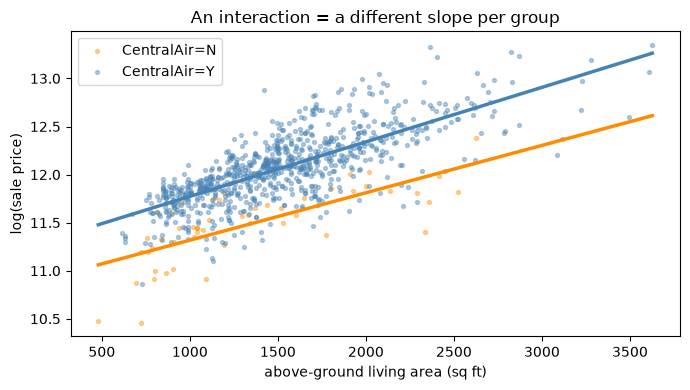

In [27]:
additive_fit = smf.ols("LogPrice ~ GrLivArea + C(CentralAir)", data=ames_train).fit()
interaction_fit = smf.ols("LogPrice ~ GrLivArea * C(CentralAir)", data=ames_train).fit()
inter_term = "GrLivArea:C(CentralAir)[T.Y]"
print(pd.DataFrame({"coef": interaction_fit.params, "p-value": interaction_fit.pvalues}).to_string(float_format=lambda v: f"{v:.3g}"))

slope_no_ac = interaction_fit.params["GrLivArea"]
slope_ac = slope_no_ac + interaction_fit.params[inter_term]
f_stat, f_p, df_diff = interaction_fit.compare_f_test(additive_fit)
print(f"\n+100 sq ft → price change: without AC {100 * (np.exp(100 * slope_no_ac) - 1):.1f}% | with AC {100 * (np.exp(100 * slope_ac) - 1):.1f}%")
print(f"F-test for the interaction: F = {f_stat:.2f}, p = {f_p:.3g} → "
      f"{'the slopes really differ' if f_p < 0.05 else 'no evidence the slopes differ'}")

# The same model in scikit-learn: reference-coded dummy + a hand-made product column
ac_yes = (ames_train["CentralAir"] == "Y").astype(float)
X_inter = pd.DataFrame({"GrLivArea": ames_train["GrLivArea"], "CentralAir_Y": ac_yes, "GrLivArea_x_CentralAir_Y": ames_train["GrLivArea"] * ac_yes})
sk_inter = LinearRegression().fit(X_inter, ames_train["LogPrice"])
assert np.allclose(sk_inter.coef_, interaction_fit.params[["GrLivArea", "C(CentralAir)[T.Y]", inter_term]])
print("✅ scikit-learn with a manual interaction column reproduces the statsmodels coefficients")

fig, ax = plt.subplots(figsize=(7, 4))
for level, color in [("N", "darkorange"), ("Y", "steelblue")]:
    rows = ames_train["CentralAir"] == level
    ax.scatter(ames_train.loc[rows, "GrLivArea"], ames_train.loc[rows, "LogPrice"], s=8, alpha=0.4, color=color, label=f"CentralAir={level}")
    area_grid = np.linspace(ames_train["GrLivArea"].min(), ames_train["GrLivArea"].max(), 50)
    line = interaction_fit.predict(pd.DataFrame({"GrLivArea": area_grid, "CentralAir": level}))
    ax.plot(area_grid, line, color=color, lw=2.5)
ax.set(xlabel="above-ground living area (sq ft)", ylabel="log(sale price)", title="An interaction = a different slope per group")
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
with_hood = smf.ols("LogPrice ~ GrLivArea * C(CentralAir) + C(Neighborhood)", data=ames_train).fit()
f_hood, p_hood, df_hood = with_hood.compare_f_test(interaction_fit)
print(f"adding Neighborhood ({ames_train['Neighborhood'].nunique()} levels → {int(df_hood)} dummy columns): "
      f"adjusted R² {interaction_fit.rsquared_adj:.3f} → {with_hood.rsquared_adj:.3f} | partial F = {f_hood:.1f}, p = {p_hood:.1e}")

adding Neighborhood (25 levels → 24 dummy columns): adjusted R² 0.605 → 0.789 | partial F = 32.5, p = 7.0e-103


A **partial F-test** (`compare_f_test`) asks whether a *group* of columns (all the neighbourhood dummies) improves the fit more than chance would. Use it for categoricals: the p-value of a single dummy only compares that level with the reference level.

### ✍️ Your Turn

From `interaction_fit.params`, compute the **log-price slope per square foot for houses WITH central air**. Store it in `slope_with_ac`.

In [29]:
slope_with_ac = None  # TODO: your code here
check("slope_with_ac", slope_with_ac, sk_inter.coef_[0] + sk_inter.coef_[2], rtol=1e-6, atol=1e-10,
      hint="The base slope 'GrLivArea' plus the interaction term 'GrLivArea:C(CentralAir)[T.Y]'.")

⏳ slope_with_ac: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
slope_with_ac = interaction_fit.params["GrLivArea"] + interaction_fit.params["GrLivArea:C(CentralAir)[T.Y]"]
check("slope_with_ac", slope_with_ac, sk_inter.coef_[0] + sk_inter.coef_[2], rtol=1e-6, atol=1e-10)
```

With an interaction, the "main effect" `GrLivArea` is the slope **for the reference group only** (no central air). Always state which group a main effect refers to.
</details>

> 💡 **Interview angle:** "How do you put a categorical feature into linear regression?" — one-hot encode and drop a reference level when there is an intercept (dummy variable trap); coefficients are differences from the reference. Test the whole categorical with a partial F-test. For very high cardinality use regularization or target encoding with cross-fitting. Interactions (`x * C(g)`) give each group its own slope.

## 9. Polynomial Features and Overfitting 🟡

`PolynomialFeatures(degree=d)` adds powers and products of the features ($x_1^2$, $x_1 x_2$, …). The model is still **linear in the coefficients**, so OLS still works, but it can now bend. The number of columns explodes: for $p$ features and degree $d$ it is $\binom{p+d}{d}$ (including the constant).

More flexibility means lower training error but, beyond some point, **higher validation error** (overfitting: the model fits noise and goes wild outside the training range). Let's see it first with one feature and just 40 training districts.

degree  1: train RMSE 0.902 | validation RMSE (all 5,160 districts) 0.868
degree  3: train RMSE 0.883 | validation RMSE (all 5,160 districts) 0.884


degree  9: train RMSE 0.854 | validation RMSE (all 5,160 districts) 1.52e+03


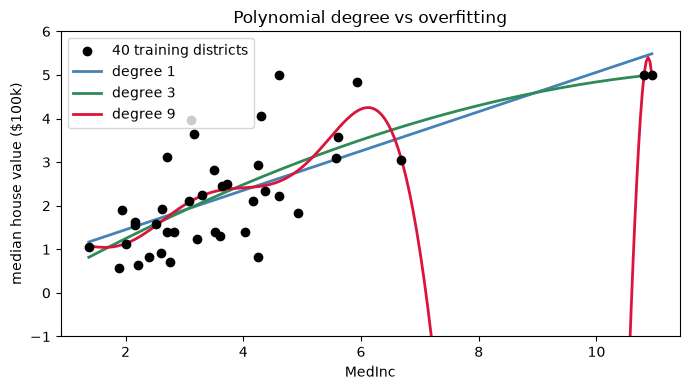

In [30]:
few = rng.choice(len(X_train), size=40, replace=False)
x_few, y_few = X_train[["MedInc"]].iloc[few], y_train.iloc[few]
inc_grid = pd.DataFrame({"MedInc": np.linspace(x_few["MedInc"].min(), x_few["MedInc"].max(), 300)})

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_few["MedInc"], y_few, color="black", zorder=3, label="40 training districts")
for degree, color in [(1, "steelblue"), (3, "seagreen"), (9, "crimson")]:
    poly_model = make_pipeline(StandardScaler(), PolynomialFeatures(degree), StandardScaler(), LinearRegression()).fit(x_few, y_few)
    ax.plot(inc_grid["MedInc"], poly_model.predict(inc_grid), color=color, lw=2, label=f"degree {degree}")
    print(f"degree {degree:>2}: train RMSE {root_mean_squared_error(y_few, poly_model.predict(x_few)):.3f} | "
          f"validation RMSE (all {len(X_val):,} districts) {root_mean_squared_error(y_val, poly_model.predict(X_val[['MedInc']])):.3g}")
ax.set(ylim=(-1, 6), xlabel="MedInc", ylabel="median house value (\\$100k)", title="Polynomial degree vs overfitting")
ax.legend()
plt.tight_layout()
plt.show()

Now all 8 features, degrees 1–4, with **400** training rows vs the **full** training set (≈15,000 rows). The skewed features are log-transformed first, as Section 5 recommends.

In [31]:
poly_rows = []
for n_rows in [400, len(X_train)]:
    X_sub, y_sub = X_train.iloc[:n_rows], y_train.iloc[:n_rows]
    for degree in [1, 2, 3, 4]:
        poly_model = make_pipeline(FunctionTransformer(log_skewed), StandardScaler(), PolynomialFeatures(degree), StandardScaler(), LinearRegression())
        poly_model.fit(X_sub, y_sub)
        poly_rows.append({"train rows": n_rows, "degree": degree, "columns": poly_model[3].n_features_in_,
                          "train RMSE": root_mean_squared_error(y_sub, poly_model.predict(X_sub)),
                          "validation RMSE": root_mean_squared_error(y_val, poly_model.predict(X_val))})
poly_table = pd.DataFrame(poly_rows)
print(poly_table.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
best_small = poly_table[poly_table["train rows"] == 400].sort_values("validation RMSE").iloc[0]
best_full = poly_table[poly_table["train rows"] == len(X_train)].sort_values("validation RMSE").iloc[0]
print(f"\n→ with 400 rows the best degree is {int(best_small['degree'])}; with the full training set it is {int(best_full['degree'])}. "
      "More data supports more flexibility.")

 train rows  degree  columns  train RMSE  validation RMSE
        400       1        9       0.601           0.6943
        400       2       45      0.4919           0.9073
        400       3      165      0.3481            6.154
        400       4      495    2.94e-14            954.1
      15480       1        9      0.6684           0.6717
      15480       2       45      0.6025            0.606
      15480       3      165      0.5655           0.5911
      15480       4      495      0.5209            1.003

→ with 400 rows the best degree is 1; with the full training set it is 3. More data supports more flexibility.


In [32]:
# Can regularization rescue the flexible model on small data?
X_400, y_400 = X_train.iloc[:400], y_train.iloc[:400]
rescue = make_pipeline(FunctionTransformer(log_skewed), StandardScaler(), PolynomialFeatures(3), StandardScaler(),
                       RidgeCV(alphas=np.logspace(-3, 4, 30))).fit(X_400, y_400)
rmse_rescue = root_mean_squared_error(y_val, rescue.predict(X_val))
rmse_deg3_ols = poly_table.query("`train rows` == 400 and degree == 3")["validation RMSE"].iloc[0]
rmse_deg1_ols = poly_table.query("`train rows` == 400 and degree == 1")["validation RMSE"].iloc[0]
print(f"400 rows, degree 3: OLS val RMSE {rmse_deg3_ols:.4g} | RidgeCV (alpha={rescue[-1].alpha_:.3g}) val RMSE {rmse_rescue:.4g} | "
      f"plain degree-1 OLS {rmse_deg1_ols:.4f}")
if rmse_rescue < rmse_deg1_ols:
    print("→ Ridge tamed the 165 coefficients enough to beat the simple model.")
else:
    print(f"→ Ridge cut the degree-3 error by {100 * (1 - rmse_rescue / rmse_deg3_ols):.0f}%, but degree 1 is still better: shrinking "
          "coefficients can't stop cubic terms from extrapolating on validation districts far outside the 400 training rows.")

400 rows, degree 3: OLS val RMSE 6.154 | RidgeCV (alpha=38.6) val RMSE 4.214 | plain degree-1 OLS 0.6943
→ Ridge cut the degree-3 error by 32%, but degree 1 is still better: shrinking coefficients can't stop cubic terms from extrapolating on validation districts far outside the 400 training rows.


With few rows, high-degree OLS has almost as many columns as rows and extrapolates wildly on unusual validation districts: squares, cubes and products of values outside the training range become enormous. Regularization helps but is not magic. The reliable fixes are more data, a lower degree, or basis functions that don't explode (splines, logs, clipping). Section 10 studies regularization properly.

### ✍️ Your Turn

How many columns does `PolynomialFeatures(degree=3)` produce for the 8 California features (constant included)? Compute it with `math.comb`, without fitting anything. Store it in `n_poly_columns`.

In [33]:
n_poly_columns = None  # TODO: your code here
check("n_poly_columns", n_poly_columns, PolynomialFeatures(degree=3).fit(X_train.iloc[:5]).n_output_features_,
      hint="Number of monomials of degree ≤ d in p variables: comb(p + d, d).")

⏳ n_poly_columns: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_poly_columns = math.comb(8 + 3, 3)
check("n_poly_columns", n_poly_columns, PolynomialFeatures(degree=3).fit(X_train.iloc[:5]).n_output_features_)
```

165 columns from 8 features. With 50 features, degree 3 would already give 23,426 columns, which is why people use `interaction_only=True`, splines, or tree models instead.
</details>

> 💡 **Interview angle:** "Is polynomial regression a linear model?" — yes: it's linear in the parameters, so OLS, the normal equations and all the inference still apply. Watch the $\binom{p+d}{d}$ column explosion, scale features first (powers of large numbers are ill-conditioned), choose the degree on validation data, and regularize.

## 10. Regularization: Ridge, Lasso, and ElasticNet 🟡

**Regularization** adds a penalty on coefficient size, accepting a little bias for a big drop in variance. The exact objectives in scikit-learn (note the different scalings!):

| Model | scikit-learn objective | Effect |
|---|---|---|
| **Ridge** (L2) | $\lVert y - X\beta\rVert_2^2 + \alpha\lVert\beta\rVert_2^2$ | shrinks all coefficients smoothly; closed form $(X^\top X + \alpha I)^{-1}X^\top y$ |
| **Lasso** (L1) | $\frac{1}{2n}\lVert y - X\beta\rVert_2^2 + \alpha\lVert\beta\rVert_1$ | sets many coefficients **exactly to 0** (feature selection); no closed form, uses coordinate descent |
| **ElasticNet** | $\frac{1}{2n}\lVert y - X\beta\rVert_2^2 + \alpha\rho\lVert\beta\rVert_1 + \frac{\alpha(1-\rho)}{2}\lVert\beta\rVert_2^2$ | sparsity **and** stability with correlated features ($\rho$ = `l1_ratio`) |

Rules: the **intercept is never penalized**, and features must be **standardized** (otherwise the penalty punishes features just for their units).

**Why does Lasso give exact zeros?** Two views (Section 6 of [ML Fundamentals](01_ML_Fundamentals_From_Scratch.ipynb) implements the coordinate-descent version):
1. **Calculus.** For orthonormal features ($X^\top X = I$) and the textbook objective $\tfrac12\lVert y-X\beta\rVert^2 + \lambda\lVert\beta\rVert_1$, the Lasso solution is the **soft threshold** of the OLS coefficient $b_j$: $\;\hat\beta_j = \text{sign}(b_j)\max(|b_j| - \lambda, 0)$. Ridge ($\tfrac{\lambda}{2}\lVert\beta\rVert^2$) gives $b_j/(1+\lambda)$: smaller, but never zero. The L1 penalty pushes with a **constant** force $\lambda$ however small $\beta_j$ is. The L2 push $\lambda\beta_j$ fades near zero.
2. **Geometry.** Penalized regression = minimize RSS inside a budget region. The L1 region is a **diamond with corners on the axes**, and the elliptical RSS contours usually first touch it **at a corner**, where some coefficients are 0. The L2 region is a circle with no corners.

Let's draw the geometry with two real, correlated Ames features.

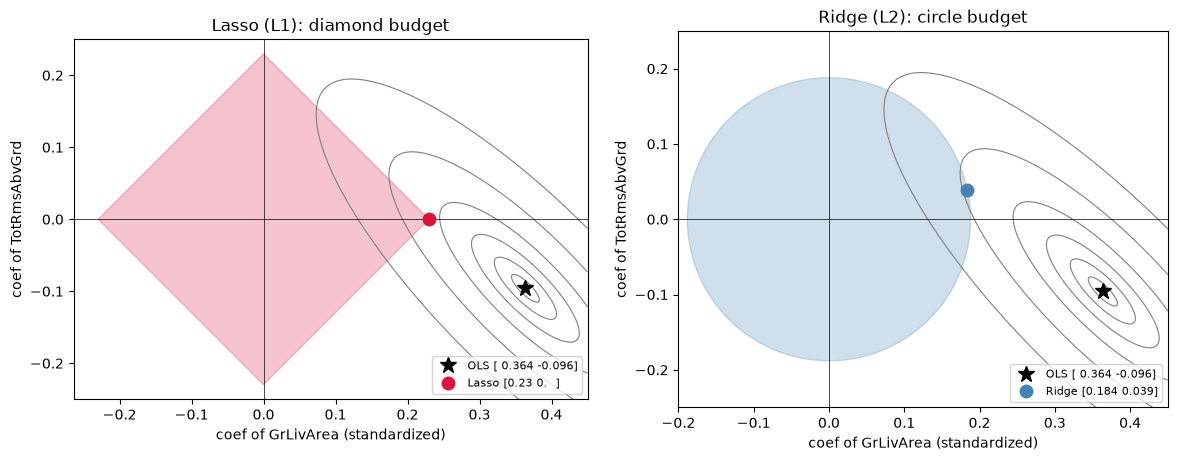

OLS [ 0.3638 -0.0959] | Lasso at half the L1 budget [0.23 0.  ] | Ridge at half the L2 budget [0.184 0.039]
→ The Lasso solution sits on a corner of the diamond: TotRmsAbvGrd is exactly 0.


In [34]:
ya_tr, ya_va = ames_train["LogPrice"].to_numpy(), ames_val["LogPrice"].to_numpy()
two_features = ["GrLivArea", "TotRmsAbvGrd"]
X_two = StandardScaler().fit_transform(ames_train[two_features])
y_two = ya_tr - ya_tr.mean()
b_ols_two = np.linalg.lstsq(X_two, y_two, rcond=None)[0]

l1_budget = 0.5 * np.abs(b_ols_two).sum()                    # allow half of the OLS L1 norm
alphas_two, path_two, _ = lasso_path(X_two, y_two, alphas=np.logspace(-6, 0, 3000))
b_lasso_two = path_two[:, np.argmin(np.abs(np.abs(path_two).sum(axis=0) - l1_budget))]


def ridge_two(alpha):
    return np.linalg.solve(X_two.T @ X_two + alpha * np.eye(2), X_two.T @ y_two)


l2_budget = 0.5 * np.linalg.norm(b_ols_two)
b_ridge_two = ridge_two(brentq(lambda a: np.linalg.norm(ridge_two(a)) - l2_budget, 1e-9, 1e9))

g1, g2 = np.meshgrid(np.linspace(-0.2, 0.45, 300), np.linspace(-0.25, 0.25, 300))
rss_grid = ((y_two[:, None] - X_two[:, [0]] * g1.ravel() - X_two[:, [1]] * g2.ravel()) ** 2).sum(axis=0).reshape(g1.shape)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, title in zip(axes, ["Lasso (L1): diamond budget", "Ridge (L2): circle budget"]):
    ax.contour(g1, g2, rss_grid, levels=np.quantile(rss_grid, [0.002, 0.01, 0.03, 0.07, 0.15, 0.3]), colors="gray", linewidths=0.8)
    ax.plot(*b_ols_two, "k*", ms=12, label=f"OLS {np.round(b_ols_two, 3)}")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    ax.set(xlabel="coef of GrLivArea (standardized)", ylabel="coef of TotRmsAbvGrd", title=title)
    ax.set_aspect("equal")
diamond = np.array([[l1_budget, 0], [0, l1_budget], [-l1_budget, 0], [0, -l1_budget], [l1_budget, 0]])
axes[0].fill(diamond[:, 0], diamond[:, 1], alpha=0.25, color="crimson")
axes[0].plot(*b_lasso_two, "o", color="crimson", ms=9, label=f"Lasso {np.round(b_lasso_two, 3)}")
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].fill(l2_budget * np.cos(theta), l2_budget * np.sin(theta), alpha=0.25, color="steelblue")
axes[1].plot(*b_ridge_two, "o", color="steelblue", ms=9, label=f"Ridge {np.round(b_ridge_two, 3)}")
for ax in axes:
    ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()
print(f"OLS {np.round(b_ols_two, 4)} | Lasso at half the L1 budget {np.round(b_lasso_two, 4)} | Ridge at half the L2 budget {np.round(b_ridge_two, 4)}")
print("→ The Lasso solution sits on a corner of the diamond: TotRmsAbvGrd is exactly 0." if np.any(b_lasso_two == 0)
      else "→ Here the Lasso solution touches an edge, not a corner; both coefficients stay non-zero.")

Now the full picture: **coefficient paths** for all 36 numeric Ames features (median-imputed and standardized on the training split) as the penalty grows.

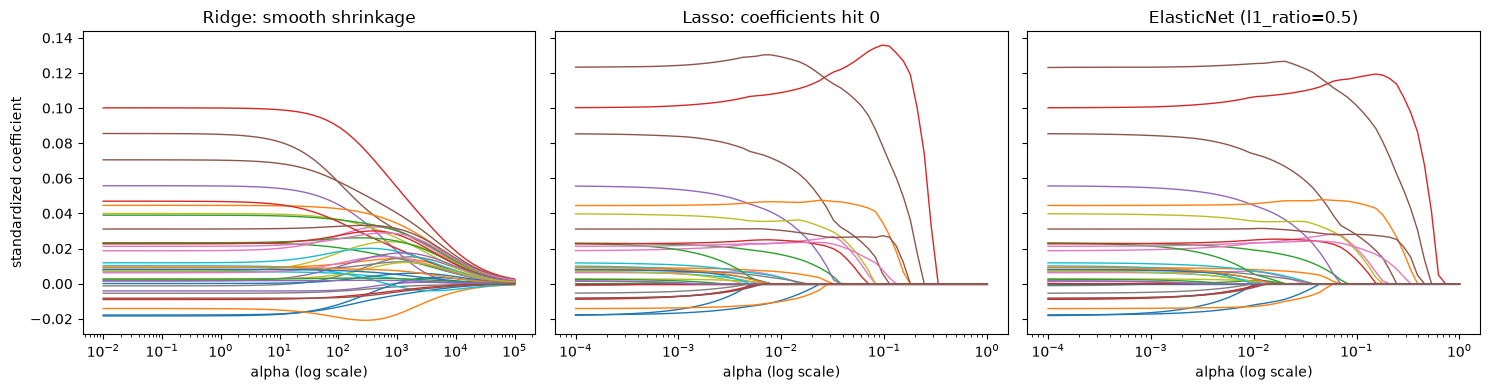

lasso alpha≈0.001: 32 of 36 coefficients non-zero
lasso alpha≈0.01: 17 of 36 coefficients non-zero
lasso alpha≈0.1: 6 of 36 coefficients non-zero
ridge: exact zeros anywhere on its path: 0


In [35]:
ames_num_cols = ames_train.drop(columns=["SalePrice", "LogPrice"]).select_dtypes("number").columns.tolist()
num_prep = make_pipeline(SimpleImputer(strategy="median"), StandardScaler()).fit(ames_train[ames_num_cols])
Xa_tr = num_prep.transform(ames_train[ames_num_cols])
Xa_va = num_prep.transform(ames_val[ames_num_cols])
ya_tr_centered = ya_tr - ya_tr.mean()          # the path functions fit no intercept; X is already centered

path_alphas = np.logspace(-4, 0, 60)
lasso_alphas, lasso_coefs, _ = lasso_path(Xa_tr, ya_tr_centered, alphas=path_alphas, max_iter=50_000)
enet_alphas, enet_coefs, _ = enet_path(Xa_tr, ya_tr_centered, l1_ratio=0.5, alphas=path_alphas, max_iter=50_000)
ridge_alphas = np.logspace(-2, 5, 60)
ridge_coefs = np.array([Ridge(alpha=a).fit(Xa_tr, ya_tr).coef_ for a in ridge_alphas]).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, alphas_, coefs_, title in [(axes[0], ridge_alphas, ridge_coefs, "Ridge: smooth shrinkage"),
                                   (axes[1], lasso_alphas, lasso_coefs, "Lasso: coefficients hit 0"),
                                   (axes[2], enet_alphas, enet_coefs, "ElasticNet (l1_ratio=0.5)")]:
    ax.plot(alphas_, coefs_.T, lw=1)
    ax.set(xscale="log", xlabel="alpha (log scale)", title=title)
axes[0].set_ylabel("standardized coefficient")
plt.tight_layout()
plt.show()

for alpha in [1e-3, 1e-2, 1e-1]:
    j = np.argmin(np.abs(lasso_alphas - alpha))
    print(f"lasso alpha≈{alpha:g}: {int(np.sum(lasso_coefs[:, j] != 0))} of {len(ames_num_cols)} coefficients non-zero")
print(f"ridge: exact zeros anywhere on its path: {int(np.sum(ridge_coefs == 0))}")

**Choosing alpha by cross-validation.** `RidgeCV`, `LassoCV` and `ElasticNetCV` try a grid of alphas with K-fold CV on the training data and refit with the best one. (`LassoCV` also accepts `alphas=<int>` to build its own grid.) Inside a pipeline, the scaler is fit once on all training rows before the internal CV — a tiny, usually harmless leak. The strict version is `GridSearchCV` over the whole pipeline, which the validation curve below uses.

In [36]:
cv5 = KFold(5, shuffle=True, random_state=SEED)
cv_models = {
    "OLS (no penalty)": LinearRegression(),
    "RidgeCV": RidgeCV(alphas=np.logspace(-2, 4, 40), cv=cv5),
    "LassoCV": LassoCV(alphas=np.logspace(-5, 0, 40), cv=cv5, max_iter=50_000),
    "ElasticNetCV": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], alphas=np.logspace(-5, 0, 40), cv=cv5, max_iter=50_000),
}
reg_rows, fitted_reg = [], {}
for name, estimator in cv_models.items():
    pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), estimator).fit(ames_train[ames_num_cols], ya_tr)
    fitted_reg[name] = pipe
    final = pipe[-1]
    reg_rows.append({"model": name, "alpha": getattr(final, "alpha_", np.nan), "l1_ratio": getattr(final, "l1_ratio_", np.nan),
                     "non-zero coefs": int(np.sum(final.coef_ != 0)),
                     "val RMSE (log price)": root_mean_squared_error(ya_va, pipe.predict(ames_val[ames_num_cols]))})
reg_table = pd.DataFrame(reg_rows).set_index("model")
print(reg_table.to_string(float_format=lambda v: f"{v:.4g}"))
best_reg_name = reg_table["val RMSE (log price)"].idxmin()
reg_spread = reg_table["val RMSE (log price)"].max() - reg_table["val RMSE (log price)"].min()
print(f"\n→ best on validation: {best_reg_name}, but all four are within {reg_spread:.4f} RMSE → "
      f"{'practically tied: 36 numeric features for 873 rows are not enough to make OLS overfit' if reg_spread < 0.003 else 'regularization makes a real difference'}.")
print(f"→ Lasso kept {reg_table.loc['LassoCV', 'non-zero coefs']} of {len(ames_num_cols)} features.")
lasso_dropped = [c for c, w in zip(ames_num_cols, fitted_reg["LassoCV"][-1].coef_) if w == 0]
print("features LassoCV set to exactly 0:", lasso_dropped)

                    alpha  l1_ratio  non-zero coefs  val RMSE (log price)
model                                                                    
OLS (no penalty)      NaN       NaN              36                0.1448
RidgeCV             24.24       NaN              36                0.1451
LassoCV          0.001125       NaN              32                0.1446
ElasticNetCV      0.01194       0.1              34                0.1447

→ best on validation: LassoCV, but all four are within 0.0004 RMSE → practically tied: 36 numeric features for 873 rows are not enough to make OLS overfit.
→ Lasso kept 32 of 36 features.
features LassoCV set to exactly 0: ['MasVnrArea', 'BsmtUnfSF', 'FirstFlrSF', 'SecondFlrSF']


Ridge: best CV RMSE 0.1284 at alpha=14.4 | at the smallest alpha 0.1286 | at the largest 0.2895
Lasso: best CV RMSE 0.1284 at alpha=0.00127 | at the smallest alpha 0.1286 | at the largest 0.3922


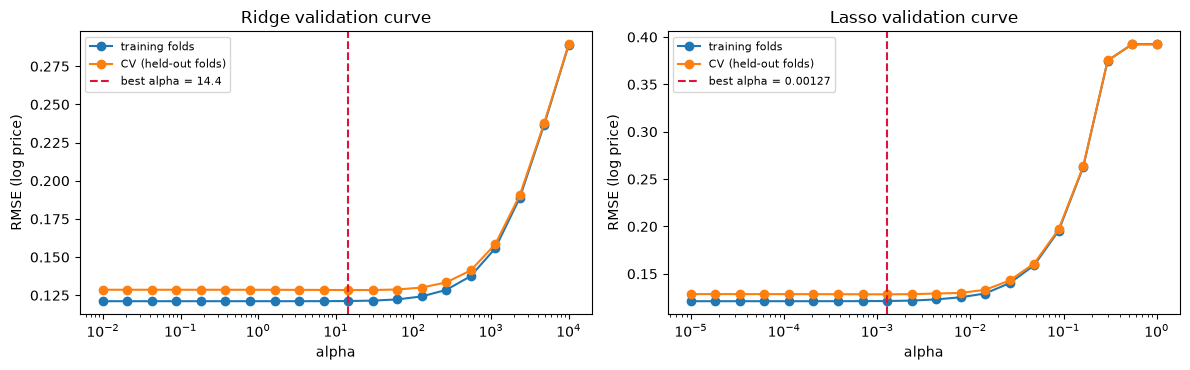

In [37]:
# Hyperparameter experiment: validation curves (strict CV — the whole pipeline is refit in every fold)
vc_rows = {}
for label, pipe, param, grid in [
    ("Ridge", make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge()), "ridge__alpha", np.logspace(-2, 4, 20)),
    ("Lasso", make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Lasso(max_iter=50_000)), "lasso__alpha", np.logspace(-5, 0, 20)),
]:
    train_sc, cv_sc = validation_curve(pipe, ames_train[ames_num_cols], ya_tr, param_name=param, param_range=grid,
                                       cv=cv5, scoring="neg_root_mean_squared_error")
    vc_rows[label] = (grid, -train_sc.mean(axis=1), -cv_sc.mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (label, (grid, tr_rmse, cv_rmse)) in zip(axes, vc_rows.items()):
    ax.plot(grid, tr_rmse, marker="o", label="training folds")
    ax.plot(grid, cv_rmse, marker="o", label="CV (held-out folds)")
    best = grid[np.argmin(cv_rmse)]
    ax.axvline(best, ls="--", color="crimson", label=f"best alpha = {best:.3g}")
    ax.set(xscale="log", xlabel="alpha", ylabel="RMSE (log price)", title=f"{label} validation curve")
    ax.legend(fontsize=8)
    print(f"{label}: best CV RMSE {cv_rmse.min():.4f} at alpha={best:.3g} | at the smallest alpha {cv_rmse[0]:.4f} | at the largest {cv_rmse[-1]:.4f}")
plt.tight_layout()
plt.show()

Reading a validation curve: on the **left** (tiny alpha) the model is plain OLS, so training error is lowest and the gap to CV error is largest (variance). On the **right** (huge alpha) every coefficient is crushed and both errors rise together (bias). The best alpha sits in the valley. Here the valley is shallow: with 36 numeric features and 873 rows, plain OLS barely overfits (regularization helps more in the Mini Project, with ~280 one-hot columns). **Sensible defaults:** search alpha on a log grid spanning ~6 orders of magnitude, and try `l1_ratio` in {0.1, 0.5, 0.9, 1} for ElasticNet.

### ✍️ Your Turn

Suppose the features are orthonormal and the OLS coefficients are `b = [3.0, -0.5, 1.2]`. Using the textbook formulas above with λ = 1, compute the **Lasso** coefficients (soft threshold) and the **Ridge** coefficients ($b/(1+\lambda)$). Store them in `lasso_b` and `ridge_b`.

In [38]:
b_orth = np.array([3.0, -0.5, 1.2])
lam_orth = 1.0
lasso_b = None  # TODO
ridge_b = None  # TODO
check("lasso_b", lasso_b, [2.0, 0.0, 0.2], hint="np.sign(b) * np.maximum(np.abs(b) - lam, 0)")
check("ridge_b", ridge_b, [1.5, -0.25, 0.6], hint="b / (1 + lam)")

⏳ lasso_b: not attempted yet — replace None with your answer.
⏳ ridge_b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
b_orth = np.array([3.0, -0.5, 1.2])
lam_orth = 1.0
lasso_b = np.sign(b_orth) * np.maximum(np.abs(b_orth) - lam_orth, 0)
ridge_b = b_orth / (1 + lam_orth)
check("lasso_b", lasso_b, [2.0, 0.0, 0.2])
check("ridge_b", ridge_b, [1.5, -0.25, 0.6])
```

Lasso subtracts a constant (and kills −0.5 completely). Ridge divides by a constant (it halves everything, but nothing reaches zero).
</details>

> 💡 **Interview angle:** "Ridge vs Lasso vs ElasticNet?" — Ridge (L2) shrinks smoothly, keeps all features, handles correlated features by sharing weight, and has a closed form. Lasso (L1) gives sparse models because its constant-force penalty soft-thresholds small coefficients to exactly 0 (diamond corners), but it picks one feature arbitrarily from a correlated group. ElasticNet mixes both. Standardize first, don't penalize the intercept, and pick alpha by CV.

## 11. Outliers, Leverage, and Robust Regression 🔴

Squared error lets a few points **pull the whole line**. Three different ideas:

| Term | Meaning | Measure | Rule of thumb |
|---|---|---|---|
| **Outlier** | unusual **y** given its x (big residual) | studentized residual $t_i$ | $\lvert t_i\rvert > 3$ |
| **Leverage** | unusual **x** (far from the other rows) | hat value $h_{ii}$ (diagonal of H) | $h_{ii} > 2(p+1)/n$ |
| **Influence** | removing the row **changes the fit** | Cook's distance $D_i \propto t_i^2\,\frac{h_{ii}}{1-h_{ii}}$ | $D_i > 4/n$ (flag), $D_i > 1$ (serious) |

A high-leverage point with a small residual is harmless. A high-leverage point with a large residual is **influential**.

high leverage (h > 2(p+1)/n = 0.0012): 603 rows | outliers (|t| > 3): 260 | influential (D > 4/n): 719 | D > 1: 0
       leverage  studentized resid  Cook's D  AveRooms  AveBedrms  Population  AveOccup
1914      0.256              3.942     0.593   141.909     25.636        30.0     2.727
19006     0.696              1.488     0.564     3.167      0.833      7460.0  1243.333
11862     0.082             -5.931     0.350    59.875     15.312        28.0     1.750
16669     0.115              3.659     0.193     9.077      1.308      6532.0   502.462
1102      0.042             -4.510     0.100    31.778      9.704        47.0     1.741


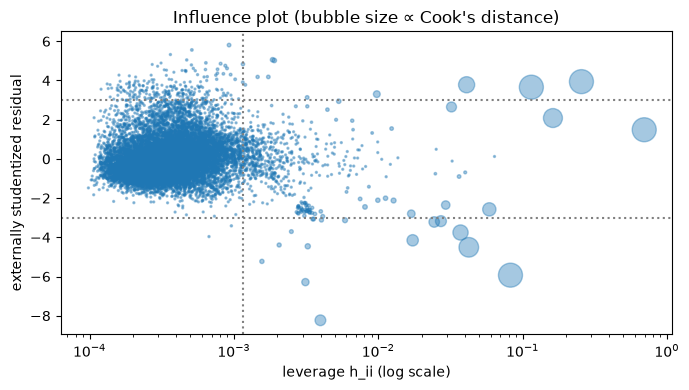

In [39]:
influence = OLSInfluence(ols_cal)
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]
stud_ext = influence.resid_studentized_external
n_obs, n_cols = ols_cal.model.exog.shape

flags = pd.DataFrame({"leverage": leverage, "studentized resid": stud_ext, "Cook's D": cooks_d}, index=X_train.index)
print(f"high leverage (h > 2(p+1)/n = {2 * n_cols / n_obs:.4f}): {int((leverage > 2 * n_cols / n_obs).sum())} rows | "
      f"outliers (|t| > 3): {int((np.abs(stud_ext) > 3).sum())} | influential (D > 4/n): {int((cooks_d > 4 / n_obs).sum())} | D > 1: {int((cooks_d > 1).sum())}")
top_influence = flags.sort_values("Cook's D", ascending=False).head(5).join(X_train[["AveRooms", "AveBedrms", "Population", "AveOccup"]])
print(top_influence.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(leverage, stud_ext, s=np.clip(cooks_d * 2000, 2, 300), alpha=0.4)
ax.axhline(3, ls=":", color="gray")
ax.axhline(-3, ls=":", color="gray")
ax.axvline(2 * n_cols / n_obs, ls=":", color="gray")
ax.set(xscale="log", xlabel="leverage h_ii (log scale)", ylabel="externally studentized residual",
       title="Influence plot (bubble size ∝ Cook's distance)")
plt.tight_layout()
plt.show()

In [40]:
drop_rows = flags["Cook's D"].nlargest(10).index
refit = LinearRegression().fit(X_train.drop(index=drop_rows), y_train.drop(index=drop_rows))
coef_shift = pd.DataFrame({"all rows": multi_model.coef_, "without top-10 Cook's D": refit.coef_}, index=X_train.columns)
coef_shift["relative change"] = (coef_shift.iloc[:, 1] - coef_shift.iloc[:, 0]) / coef_shift.iloc[:, 0].abs()
print(coef_shift.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nvalidation RMSE: all rows {root_mean_squared_error(y_val, multi_model.predict(X_val)):.4f} | "
      f"without 10 influential training rows {root_mean_squared_error(y_val, refit.predict(X_val)):.4f}")
most_moved = coef_shift["relative change"].abs().idxmax()
print(f"→ removing 10 of {n_obs:,} rows ({10 / n_obs:.2%}) moved the {most_moved} coefficient by {coef_shift.loc[most_moved, 'relative change']:+.0%}.")

            all rows  without top-10 Cook's D  relative change
MedInc        0.4476                   0.4569           0.0208
HouseAge      0.0096                   0.0099           0.0326
AveRooms     -0.1248                  -0.1421          -0.1390
AveBedrms     0.7945                   0.9075           0.1423
Population   -0.0000                   0.0000           4.9858
AveOccup     -0.0034                  -0.0445         -11.9198
Latitude     -0.4186                  -0.4109           0.0182
Longitude    -0.4334                  -0.4247           0.0201

validation RMSE: all rows 0.7356 | without 10 influential training rows 0.7344
→ removing 10 of 15,480 rows (0.06%) moved the AveOccup coefficient by -1192%.


The most influential rows are districts with extreme averages (e.g. hundreds of occupants per household: dormitories, prisons, tiny block groups). Deleting points is a **judgement call you must document**. A cleaner alternative is a loss that simply doesn't let big residuals dominate.

**`HuberRegressor`** uses the **Huber loss**: squared error for small residuals ($|r| \le \epsilon\sigma$), absolute error beyond. Big errors pull linearly instead of quadratically. It jointly estimates the scale $\sigma$, so `epsilon` is in units of that scale (default 1.35, which is 95% as efficient as OLS when errors really are normal). Its `alpha` is an L2 penalty, so scale the features.

**Controlled experiment.** Real data often contains a few gross errors (typos, unit mix-ups). To see what they do, we corrupt **5% of the training labels on purpose** (add 10, i.e. \$1M too much) and always evaluate on the **clean** validation set.

In [41]:
corrupt_rng = np.random.default_rng(SEED)
y_corrupt = y_train.to_numpy().copy()
corrupted = corrupt_rng.choice(len(y_corrupt), size=int(0.05 * len(y_corrupt)), replace=False)
y_corrupt[corrupted] += 10.0

robust_rows = []
for label, estimator, target in [("OLS on clean labels (reference)", LinearRegression(), y_train.to_numpy()),
                                 ("OLS on corrupted labels", LinearRegression(), y_corrupt),
                                 ("Huber on corrupted labels", HuberRegressor(max_iter=1000), y_corrupt)]:
    pipe = make_pipeline(StandardScaler(), estimator).fit(X_train, target)
    robust_rows.append({"model": label, "clean validation RMSE": root_mean_squared_error(y_val, pipe.predict(X_val)),
                        "MedInc coef (std)": pipe[-1].coef_[0]})
    if isinstance(estimator, HuberRegressor):
        huber_pipe = pipe
robust_table = pd.DataFrame(robust_rows).set_index("model")
print(robust_table.round(4).to_string())

flagged = huber_pipe[-1].outliers_
is_corrupt = np.zeros(len(y_corrupt), dtype=bool)
is_corrupt[corrupted] = True
print(f"\nHuber flagged {flagged.sum():,} rows as outliers: it caught {np.mean(flagged[is_corrupt]):.1%} of the corrupted rows; "
      f"{np.mean(is_corrupt[flagged]):.1%} of the flagged rows were corrupted.")
print(f"→ 5% bad labels raised OLS validation RMSE from {robust_table.iloc[0, 0]:.3f} to {robust_table.iloc[1, 0]:.3f}; "
      f"Huber got {robust_table.iloc[2, 0]:.3f}.")

for eps in [1.1, 1.35, 2.0, 5.0]:
    pipe = make_pipeline(StandardScaler(), HuberRegressor(epsilon=eps, max_iter=1000)).fit(X_train, y_corrupt)
    print(f"  epsilon={eps:<4}: clean validation RMSE {root_mean_squared_error(y_val, pipe.predict(X_val)):.4f}")

                                 clean validation RMSE  MedInc coef (std)
model                                                                    
OLS on clean labels (reference)                 0.7356             0.8521
OLS on corrupted labels                         0.8889             0.8427
Huber on corrupted labels                       0.7462             0.9292

Huber flagged 5,655 rows as outliers: it caught 100.0% of the corrupted rows; 13.7% of the flagged rows were corrupted.
→ 5% bad labels raised OLS validation RMSE from 0.736 to 0.889; Huber got 0.746.
  epsilon=1.1 : clean validation RMSE 0.7482
  epsilon=1.35: clean validation RMSE 0.7462
  epsilon=2.0 : clean validation RMSE 0.7415


  epsilon=5.0 : clean validation RMSE 0.8886


Larger `epsilon` behaves more like OLS (more of the corrupted rows fall in the quadratic zone). Other robust options: `QuantileRegressor` (median regression, pure absolute loss), `RANSACRegressor` (fit on inlier subsets), `TheilSenRegressor`, and `statsmodels.RLM`.

### ✍️ Your Turn

Leverage without forming the $n \times n$ hat matrix: if $X = QR$ (thin QR), then $H = QQ^\top$ and $h_{ii} = \sum_j Q_{ij}^2$. Compute the leverages of `A_small` (500 rows, Section 3) this way and store them in `lev_qr`. The checker compares them with `np.diag(H)`.

In [42]:
lev_qr = None  # TODO: your code here
check("lev_qr", lev_qr, np.diag(H), hint="Q, _ = np.linalg.qr(A_small); (Q ** 2).sum(axis=1)")

⏳ lev_qr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
Q_small, _ = np.linalg.qr(A_small)          # thin QR: Q has shape (500, 9)
lev_qr = (Q_small ** 2).sum(axis=1)
check("lev_qr", lev_qr, np.diag(H))
```

This costs $O(np^2)$ time and $O(np)$ memory instead of $O(n^2)$ for H. The same trick is how `statsmodels` gets `hat_matrix_diag` for 15,000 rows.
</details>

> 💡 **Interview angle:** "Outlier vs leverage vs influence?" — an outlier has an unusual y (large studentized residual), a leverage point has unusual x (large $h_{ii}$), and an influential point changes the fit when removed (Cook's distance combines both). Handle them with investigation first (data errors?), then robust losses (Huber, quantile) or documented removal, never by silently deleting inconvenient rows.

## 12. Regression Metrics and When They Mislead 🟢

| Metric | Formula | Units | Optimal constant prediction | Watch out |
|---|---|---|---|---|
| **MAE** | $\frac1n\sum\lvert y-\hat y\rvert$ | target units | the **median** | treats all errors linearly; robust to outliers |
| **MSE** | $\frac1n\sum (y-\hat y)^2$ | units² | the **mean** | dominated by the largest errors |
| **RMSE** | $\sqrt{\text{MSE}}$ | target units | the mean | same as MSE but readable; always ≥ MAE |
| **R²** | $1 - \frac{\text{SS}_\text{res}}{\text{SS}_\text{tot}}$ | unitless | — | depends on the **variance of y** in the evaluation set; can be negative |
| **Adjusted R²** | $1 - (1-R^2)\frac{n-1}{n-p-1}$ | unitless | — | for in-sample model comparison, not a substitute for validation |
| **MAPE** | $\frac1n\sum\lvert\frac{y-\hat y}{y}\rvert$ | % | — | explodes when y is near 0; asymmetric |

In [43]:
val_pred = multi_model.predict(X_val)
n_val, p_feat = len(y_val), X_val.shape[1]
r2_val = r2_score(y_val, val_pred)
metrics = {"MAE": mean_absolute_error(y_val, val_pred), "MSE": mean_squared_error(y_val, val_pred),
           "RMSE": root_mean_squared_error(y_val, val_pred), "R²": r2_val,
           "adjusted R²": 1 - (1 - r2_val) * (n_val - 1) / (n_val - p_feat - 1),
           "MAPE": mean_absolute_percentage_error(y_val, val_pred)}
for name, value in metrics.items():
    print(f"{name:12s} {value:.4f}")

MAE          0.5297
MSE          0.5411
RMSE         0.7356
R²           0.5911
adjusted R²  0.5904
MAPE         0.3198


In [44]:
misleading = []
# 1) One disastrous prediction: RMSE reacts much more than MAE
bad_pred = val_pred.copy()
bad_pred[0] += 100.0
misleading.append(("one prediction off by 100", f"MAE ×{mean_absolute_error(y_val, bad_pred) / metrics['MAE']:.2f}",
                   f"RMSE ×{root_mean_squared_error(y_val, bad_pred) / metrics['RMSE']:.2f}"))
# 2) Same model, narrow slice of districts: RMSE similar, R² collapses because y varies less there
narrow = X_val["MedInc"].between(3, 4)
misleading.append((f"only MedInc in [3, 4] ({narrow.sum():,} districts)",
                   f"RMSE {root_mean_squared_error(y_val[narrow], val_pred[narrow]):.3f} (all: {metrics['RMSE']:.3f})",
                   f"R² {r2_score(y_val[narrow], val_pred[narrow]):.3f} (all: {r2_val:.3f})"))
# 3) A constant model scores R² ≈ 0; a bad model scores below 0
constant_r2 = r2_score(y_val, np.full(n_val, y_train.mean()))
misleading.append(("predict the training mean", f"R² {constant_r2:.4f}", "worse-than-constant models have R² < 0"))
# 4) MAPE is dominated by the cheapest districts
ape = np.abs((y_val - val_pred) / y_val)
cheapest = y_val <= y_val.quantile(0.05)
misleading.append(("cheapest 5% of districts", f"their share of total MAPE: {ape[cheapest].sum() / ape.sum():.1%}",
                   f"their mean APE {ape[cheapest].mean():.1%} vs others {ape[~cheapest].mean():.1%}"))
print(pd.DataFrame(misleading, columns=["scenario", "effect", "detail"]).to_string(index=False))

                               scenario                           effect                                 detail
              one prediction off by 100                        MAE ×1.04                             RMSE ×2.14
only MedInc in [3, 4] (1,321 districts)          RMSE 0.734 (all: 0.736)                  R² 0.303 (all: 0.591)
              predict the training mean                       R² -0.0000 worse-than-constant models have R² < 0
               cheapest 5% of districts their share of total MAPE: 14.7%   their mean APE 93.9% vs others 28.7%


**Choose the metric from the decision it supports.** Is a \$50k miss twice as bad as a \$25k miss (MAE) or four times as bad (MSE)? Are relative errors what matter (log-RMSE or MAPE)? Report R² only alongside an error in real units, and **never compare R² across datasets with different target spreads**.

### ✍️ Your Turn

Implement R² from scratch for the validation predictions `val_pred` (don't call `r2_score`). Store it in `r2_manual`.

In [45]:
r2_manual = None  # TODO: your code here
check("r2_manual", r2_manual, r2_score(y_val, val_pred), hint="1 - sum((y - ŷ)²) / sum((y - mean(y))²), with the mean of the evaluation y.")

⏳ r2_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_val_np = y_val.to_numpy()
r2_manual = 1 - np.sum((y_val_np - val_pred) ** 2) / np.sum((y_val_np - y_val_np.mean()) ** 2)
check("r2_manual", r2_manual, r2_score(y_val, val_pred))
```

The baseline in the denominator uses the mean of the **evaluation** set. That's why a model that predicts the *training* mean can score slightly below 0 on validation.
</details>

> 💡 **Interview angle:** "MAE or RMSE?" — RMSE (squared loss) targets the conditional mean and punishes large errors heavily; MAE targets the median and is robust to outliers. Report both: RMSE ≫ MAE signals a few large errors. R² is scale-free but depends on the target's variance in the evaluation set and can be negative out of sample.

## 13. Large Data With SGDRegressor 🟡

When data doesn't fit in memory, or arrives as a stream, use **stochastic gradient descent**. `SGDRegressor` minimizes a loss (`squared_error`, `huber`, `epsilon_insensitive`) plus a penalty (`l2`, `l1`, `elasticnet`) one row at a time, with a decaying learning rate (`learning_rate="invscaling"` by default) and optional early stopping. `partial_fit` updates the model **one chunk at a time**.

| Hyperparameter | Controls | Sensible start |
|---|---|---|
| `alpha`, `penalty`, `l1_ratio` | regularization | `alpha=1e-4`, `"l2"` |
| `learning_rate`, `eta0`, `power_t` | step-size schedule | `"invscaling"`, `eta0=0.01`; try `"adaptive"` |
| `max_iter`, `tol`, `early_stopping`, `n_iter_no_change` | when to stop | defaults, or `early_stopping=True` |
| `average` | averaged SGD (smoother final weights) | `True` for noisy problems |

⚠️ SGD is **very sensitive to feature scale**. Watch what happens without a scaler.

In [46]:
unscaled_sgd = SGDRegressor(random_state=SEED).fit(X_train, y_train)
print(f"❌ unscaled            : largest |coef| {np.abs(unscaled_sgd.coef_).max():.3e} | validation RMSE {root_mean_squared_error(y_val, unscaled_sgd.predict(X_val)):.3e}")
scaled_sgd = make_pipeline(StandardScaler(), SGDRegressor(random_state=SEED)).fit(X_train, y_train)
print(f"🆗 scaled              : largest |coef| {np.abs(scaled_sgd[-1].coef_).max():.3f} | validation RMSE {root_mean_squared_error(y_val, scaled_sgd.predict(X_val)):.4f} "
      f"(closed-form OLS: {root_mean_squared_error(y_val, multi_model.predict(X_val)):.4f})")
log_sgd = make_pipeline(FunctionTransformer(log_skewed), StandardScaler(), SGDRegressor(random_state=SEED)).fit(X_train, y_train)
log_ols = make_pipeline(FunctionTransformer(log_skewed), LinearRegression()).fit(X_train, y_train)
print(f"✅ log-skewed + scaled : validation RMSE {root_mean_squared_error(y_val, log_sgd.predict(X_val)):.4f} "
      f"(closed-form OLS on the same features: {root_mean_squared_error(y_val, log_ols.predict(X_val)):.4f})")

❌ unscaled            : largest |coef| 4.859e+11 | validation RMSE 3.639e+14
🆗 scaled              : largest |coef| 0.888 | validation RMSE 0.7651 (closed-form OLS: 0.7356)
✅ log-skewed + scaled : validation RMSE 0.6719 (closed-form OLS on the same features: 0.6717)


Scaling fixes the units, but plain SGD can still trail OLS: a few districts sit ~100 standard deviations out (Section 4), and every visit to them kicks the weights. Log-transforming the skewed features first lets SGD match OLS. Now the streaming version, on the same log-transformed features:

In [47]:
# Streaming: pretend the training data arrives in 20 chunks that never sit in memory together
stream_scaler = StandardScaler()
stream_model = SGDRegressor(learning_rate="adaptive", eta0=0.01, average=True, random_state=SEED)
chunks = np.array_split(np.arange(len(X_train)), 20)
for chunk in chunks:                                   # pass 1: learn the scaling statistics incrementally
    stream_scaler.partial_fit(log_skewed(X_train.iloc[chunk]))
stream_rmse = []
start = time.perf_counter()
for epoch in range(5):
    for chunk in chunks:
        stream_model.partial_fit(stream_scaler.transform(log_skewed(X_train.iloc[chunk])), y_train.iloc[chunk])
    stream_rmse.append(root_mean_squared_error(y_val, stream_model.predict(stream_scaler.transform(log_skewed(X_val)))))
print("validation RMSE after each pass over the stream:", np.round(stream_rmse, 4), f"({time.perf_counter() - start:.2f}s)")
gap = stream_rmse[-1] - root_mean_squared_error(y_val, log_ols.predict(X_val))
print(f"→ after 5 passes the streaming model is within {abs(gap):.4f} RMSE of the exact OLS solution on the same features, "
      "without ever holding the full dataset in one array.")

validation RMSE after each pass over the stream: [0.6724 0.6719 0.6718 0.6717 0.6717] (0.06s)
→ after 5 passes the streaming model is within 0.0000 RMSE of the exact OLS solution on the same features, without ever holding the full dataset in one array.


> 💡 **Interview angle:** "How would you train linear regression on 1 TB of data?" — mini-batch/stochastic gradient descent with `partial_fit` (or Spark/Vowpal Wabbit), incremental scaling statistics, a decaying or adaptive learning rate, averaged weights, and a held-out stream for early stopping. Alternatively, accumulate $X^\top X$ and $X^\top y$ in one pass when $p$ is small: they are only $p \times p$.

## 14. A Fair Head-to-Head Comparison 🟡

How does linear regression compare with its neighbours on the same data? We use the **same 5 folds** on the California training split for every model, and record score, fit time and predict time.

In [48]:
h2h_cv = KFold(5, shuffle=True, random_state=SEED)
contenders = {
    "LinearRegression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge + log skewed features": make_pipeline(FunctionTransformer(log_skewed), StandardScaler(), Ridge(alpha=1.0)),
    "KNeighborsRegressor (k=15)": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15)),
    "DecisionTreeRegressor (depth 10)": DecisionTreeRegressor(max_depth=10, random_state=SEED),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=SEED),
}
h2h_rows = []
for name, model in contenders.items():
    res = cross_validate(model, X_train, y_train, cv=h2h_cv, scoring=["neg_root_mean_squared_error", "r2"])
    h2h_rows.append({"model": name, "CV RMSE": -res["test_neg_root_mean_squared_error"].mean(),
                     "± std": res["test_neg_root_mean_squared_error"].std(), "CV R²": res["test_r2"].mean(),
                     "fit (s)": res["fit_time"].mean(), "predict (s)": res["score_time"].mean()})
h2h = pd.DataFrame(h2h_rows).set_index("model").sort_values("CV RMSE")
print(h2h.to_string(float_format=lambda v: f"{v:.4f}"))

best_model = h2h.index[0]
linear_rmse = h2h.loc["LinearRegression", "CV RMSE"]
print(f"\n→ Most accurate: {best_model} (CV RMSE {h2h.iloc[0]['CV RMSE']:.3f} vs {linear_rmse:.3f} for plain linear regression).")
print(f"→ Linear regression fits in {h2h.loc['LinearRegression', 'fit (s)'] * 1000:.0f} ms, "
      f"{h2h.loc[best_model, 'fit (s)'] / h2h.loc['LinearRegression', 'fit (s)']:.0f}× faster than {best_model}, and is fully interpretable.")
print(f"→ Simple feature engineering (log of skewed features) changed linear CV RMSE by "
      f"{h2h.loc['Ridge + log skewed features', 'CV RMSE'] - linear_rmse:+.3f}.")

                                  CV RMSE  ± std  CV R²  fit (s)  predict (s)
model                                                                        
HistGradientBoostingRegressor      0.4734 0.0127 0.8319   0.9195       0.0074
KNeighborsRegressor (k=15)         0.6464 0.0208 0.6866   0.0031       0.0464
DecisionTreeRegressor (depth 10)   0.6670 0.0154 0.6663   0.0326       0.0010
Ridge + log skewed features        0.6690 0.0142 0.6643   0.0016       0.0008
LinearRegression                   0.7225 0.0145 0.6085   0.0019       0.0007

→ Most accurate: HistGradientBoostingRegressor (CV RMSE 0.473 vs 0.722 for plain linear regression).
→ Linear regression fits in 2 ms, 477× faster than HistGradientBoostingRegressor, and is fully interpretable.
→ Simple feature engineering (log of skewed features) changed linear CV RMSE by -0.053.


The non-linear models win on California because location and income interact in complex ways (coastal price bands) that a single plane can't draw. That doesn't make linear regression useless: it is the **baseline** that tells you how much non-linearity is worth, the model you can **explain** coefficient by coefficient, and often the winner when data is small, as in the Ames Mini Project.

> 💡 **Interview angle:** "Your gradient-boosting model beats linear regression by 0.2 RMSE. Would you ship it?" — compare on the same folds with a spread (± std), then weigh accuracy against latency, interpretability, monitoring and robustness to distribution shift (trees can't extrapolate, linear models can extrapolate *wrongly*). Often you ship the GBM and keep the linear model as a sanity check.

## 🔧 Build It From Scratch

Three builds, each **asserted** against the libraries:
1. **OLS three ways** (normal equations, `lstsq`, gradient descent) plus the classical inference table (standard errors, t, p-values, adjusted R²), matched against `LinearRegression` and `statsmodels`.
2. **Ridge in closed form** with an **unpenalized intercept**, matched against `Ridge`, plus the "augmented data" trick.
3. A demonstration of **why the intercept must not be penalized**.

The formulas:

$$\hat\beta = (X^\top X)^{-1}X^\top y, \qquad \hat\sigma^2 = \frac{\lVert y - X\hat\beta\rVert^2}{n - k}, \qquad \widehat{\text{Cov}}(\hat\beta) = \hat\sigma^2 (X^\top X)^{-1}, \qquad \hat\beta_{\text{ridge}} = (X^\top X + \alpha D)^{-1} X^\top y$$

where $k$ counts all columns including the intercept, and $D = \text{diag}(0, 1, \dots, 1)$ leaves the intercept out of the penalty.

In [49]:
class LinearRegressionScratch:
    """Ordinary least squares in NumPy: three solvers + classical (non-robust) inference."""

    def __init__(self, method="lstsq", tol=1e-10, max_iter=200_000):
        self.method, self.tol, self.max_iter = method, tol, max_iter

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
        A = np.column_stack([np.ones(len(X)), X])
        if self.method == "normal":
            beta = np.linalg.solve(A.T @ A, A.T @ y)
        elif self.method == "lstsq":
            beta = np.linalg.lstsq(A, y, rcond=None)[0]
        elif self.method == "gd":
            beta = self._gradient_descent(X, y)
        else:
            raise ValueError(f"unknown method {self.method!r}")
        self.intercept_, self.coef_ = beta[0], beta[1:]

        n, k = A.shape
        resid = y - A @ beta
        self.sigma2_ = resid @ resid / (n - k)                      # unbiased noise variance
        A_pinv = np.linalg.pinv(A)                                  # (AᵀA)⁻¹ = A⁺(A⁺)ᵀ, computed stably via SVD
        self.bse_ = np.sqrt(self.sigma2_ * np.sum(A_pinv ** 2, axis=1))
        self.tvalues_ = beta / self.bse_
        self.pvalues_ = 2 * stats.t.sf(np.abs(self.tvalues_), df=n - k)
        self.r2_ = 1 - resid @ resid / np.sum((y - y.mean()) ** 2)
        self.r2_adj_ = 1 - (1 - self.r2_) * (n - 1) / (n - k)
        return self

    def _gradient_descent(self, X, y):
        mu, sd = X.mean(axis=0), X.std(axis=0)
        Z = np.column_stack([np.ones(len(X)), (X - mu) / sd])       # standardize → a round, well-conditioned bowl
        lr = 1 / np.linalg.eigvalsh(2 / len(y) * Z.T @ Z).max()      # safely below the 2/L stability limit
        theta = np.zeros(Z.shape[1])
        for self.n_iter_ in range(1, self.max_iter + 1):
            grad = 2 / len(y) * Z.T @ (Z @ theta - y)
            theta -= lr * grad
            if np.abs(grad).max() < self.tol:
                break
        slopes = theta[1:] / sd                                     # undo the standardization
        return np.concatenate([[theta[0] - slopes @ mu], slopes])

    def predict(self, X):
        return self.intercept_ + np.asarray(X, dtype=float) @ self.coef_


sk_reference = LinearRegression().fit(X_train, y_train)
for method in ["normal", "lstsq", "gd"]:
    start = time.perf_counter()
    ours = LinearRegressionScratch(method=method).fit(X_train, y_train)
    seconds = time.perf_counter() - start
    assert np.allclose(ours.coef_, sk_reference.coef_, rtol=1e-5, atol=1e-8), method
    assert np.isclose(ours.intercept_, sk_reference.intercept_, rtol=1e-5, atol=1e-8), method
    assert np.allclose(ours.predict(X_val), sk_reference.predict(X_val), atol=1e-6), method
    extra = f" ({ours.n_iter_:,} iterations)" if method == "gd" else ""
    print(f"✅ {method:6s} matches LinearRegression — max |coef diff| {np.abs(ours.coef_ - sk_reference.coef_).max():.1e}{extra} [{seconds:.2f}s]")

ours = LinearRegressionScratch().fit(X_train, y_train)
assert np.allclose(ours.bse_, ols_cal.bse, rtol=1e-6)
assert np.allclose(ours.tvalues_, ols_cal.tvalues, rtol=1e-6)
assert np.allclose(ours.pvalues_, ols_cal.pvalues, rtol=1e-4, atol=1e-12)
assert np.isclose(ours.r2_adj_, ols_cal.rsquared_adj)
print("✅ standard errors, t-values, p-values and adjusted R² match statsmodels")
print(pd.DataFrame({"coef": np.r_[ours.intercept_, ours.coef_], "std err": ours.bse_, "t": ours.tvalues_, "p": ours.pvalues_},
                   index=["intercept", *X_train.columns]).to_string(float_format=lambda v: f"{v:.4g}"))

✅ normal matches LinearRegression — max |coef diff| 1.1e-10 [0.00s]
✅ lstsq  matches LinearRegression — max |coef diff| 1.5e-14 [0.00s]
✅ gd     matches LinearRegression — max |coef diff| 1.6e-09 (824 iterations) [0.02s]
✅ standard errors, t-values, p-values and adjusted R² match statsmodels
                 coef   std err       t          p
intercept      -37.03    0.7532  -49.16          0
MedInc         0.4476  0.004845   92.38          0
HouseAge     0.009568 0.0005114   18.71  2.947e-77
AveRooms      -0.1248  0.006825  -18.28  7.121e-74
AveBedrms      0.7945   0.03449   23.04 1.685e-115
Population -1.439e-06 5.404e-06 -0.2663       0.79
AveOccup    -0.003443 0.0004876  -7.061  1.726e-12
Latitude      -0.4186  0.008222  -50.91          0
Longitude     -0.4334  0.008604  -50.37          0


In [50]:
def ridge_closed_form(X, y, alpha):
    """Ridge with an UNPENALIZED intercept: β = (AᵀA + αD)⁻¹Aᵀy, D = diag(0, 1, …, 1)."""
    A = np.column_stack([np.ones(len(X)), X])
    D = np.eye(A.shape[1])
    D[0, 0] = 0.0                                     # no penalty on the intercept
    beta = np.linalg.solve(A.T @ A + alpha * D, A.T @ y)
    return beta[0], beta[1:]


def ridge_augmented(X, y, alpha):
    """The same Ridge via plain least squares: center, then append √α·I rows with target 0."""
    x_mean, y_mean = X.mean(axis=0), y.mean()
    X_aug = np.vstack([X - x_mean, np.sqrt(alpha) * np.eye(X.shape[1])])
    y_aug = np.concatenate([y - y_mean, np.zeros(X.shape[1])])
    w = np.linalg.lstsq(X_aug, y_aug, rcond=None)[0]
    return y_mean - x_mean @ w, w


Z_std = gd_scaler.transform(X_train)                  # standardized California features (fit on train)
for alpha in [0.1, 10.0, 1_000.0, 100_000.0]:
    b0, w = ridge_closed_form(Z_std, y_tr, alpha)
    b0_aug, w_aug = ridge_augmented(Z_std, y_tr, alpha)
    sk_ridge = Ridge(alpha=alpha).fit(Z_std, y_tr)
    assert np.allclose(w, sk_ridge.coef_, rtol=1e-6, atol=1e-9) and np.isclose(b0, sk_ridge.intercept_)
    assert np.allclose(w, w_aug, rtol=1e-6, atol=1e-9) and np.isclose(b0, b0_aug)
    print(f"✅ alpha={alpha:>9,.1f}: closed form = augmented lstsq = sklearn Ridge | ‖w‖₂ = {np.linalg.norm(w):.4f}")

# Raw (unstandardized) features too — the intercept handling must still match
b0_raw, w_raw = ridge_closed_form(X_train.to_numpy(), y_tr, 10.0)
sk_raw = Ridge(alpha=10.0).fit(X_train, y_train)
assert np.allclose(w_raw, sk_raw.coef_, rtol=1e-5, atol=1e-9) and np.isclose(b0_raw, sk_raw.intercept_, rtol=1e-6)
print("✅ raw features: closed form matches sklearn Ridge as well")

✅ alpha=      0.1: closed form = augmented lstsq = sklearn Ridge | ‖w‖₂ = 1.5829
✅ alpha=     10.0: closed form = augmented lstsq = sklearn Ridge | ‖w‖₂ = 1.5728
✅ alpha=  1,000.0: closed form = augmented lstsq = sklearn Ridge | ‖w‖₂ = 1.0627
✅ alpha=100,000.0: closed form = augmented lstsq = sklearn Ridge | ‖w‖₂ = 0.1123
✅ raw features: closed form matches sklearn Ridge as well


In [51]:
def ridge_penalize_everything(X, y, alpha):
    """❌ The wrong version: the intercept is penalized too (αI instead of αD)."""
    A = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.solve(A.T @ A + alpha * np.eye(A.shape[1]), A.T @ y)
    return beta[0], beta[1:]


ALPHA_DEMO, SHIFT = 5_000.0, 100.0
for label, solver in [("✅ intercept NOT penalized", ridge_closed_form), ("❌ intercept penalized", ridge_penalize_everything)]:
    b0, w = solver(Z_std, y_tr, ALPHA_DEMO)
    b0_shift, w_shift = solver(Z_std, y_tr + SHIFT, ALPHA_DEMO)
    mean_pred = b0 + (Z_std @ w).mean()
    print(f"{label:27s} mean prediction {mean_pred:.4f} vs mean target {y_tr.mean():.4f} | "
          f"adding {SHIFT:g} to every y moves the intercept by {b0_shift - b0:.3f}")
print("→ Penalizing the intercept shrinks predictions toward 0 and makes the model depend on where y's zero happens to be.")

✅ intercept NOT penalized   mean prediction 2.0703 vs mean target 2.0703 | adding 100 to every y moves the intercept by 100.000
❌ intercept penalized       mean prediction 1.5649 vs mean target 2.0703 | adding 100 to every y moves the intercept by 75.586
→ Penalizing the intercept shrinks predictions toward 0 and makes the model depend on where y's zero happens to be.


Three lessons from the builds: `lstsq`, the normal equations and gradient descent reach the **same** optimum (GD only needs standardization and $\eta < 2/L$). The classical standard errors are just $\sqrt{\hat\sigma^2 [(X^\top X)^{-1}]_{jj}}$. And Ridge must leave the intercept alone, otherwise shifting the target (e.g. prices in dollars vs dollars − 100) changes the fitted model.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Regularizing features on different scales

The penalty treats every coefficient equally, so a feature measured in large units (square feet, dollars) needs only a tiny coefficient and is barely penalized, while a feature in small units (a 1–10 quality score) is hammered.

In [52]:
lasso_alpha_demo = 0.01
raw_lasso = make_pipeline(SimpleImputer(strategy="median"), Lasso(alpha=lasso_alpha_demo, max_iter=200_000)).fit(ames_train[ames_num_cols], ya_tr)
scaled_lasso = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Lasso(alpha=lasso_alpha_demo, max_iter=200_000)).fit(ames_train[ames_num_cols], ya_tr)
kept_raw = {c for c, w in zip(ames_num_cols, raw_lasso[-1].coef_) if w != 0}
kept_scaled = {c for c, w in zip(ames_num_cols, scaled_lasso[-1].coef_) if w != 0}
print(f"❌ no scaling : kept {len(kept_raw):>2} features | val RMSE {root_mean_squared_error(ya_va, raw_lasso.predict(ames_val[ames_num_cols])):.4f}")
print(f"✅ scaled     : kept {len(kept_scaled):>2} features | val RMSE {root_mean_squared_error(ya_va, scaled_lasso.predict(ames_val[ames_num_cols])):.4f}")
print("kept only WITHOUT scaling (large-unit columns escape the penalty):", sorted(kept_raw - kept_scaled))
print("dropped only WITHOUT scaling (small-unit columns get crushed):  ", sorted(kept_scaled - kept_raw))

❌ no scaling : kept 26 features | val RMSE 0.1481
✅ scaled     : kept 17 features | val RMSE 0.1503
kept only WITHOUT scaling (large-unit columns escape the penalty): ['BsmtFinSF2', 'BsmtUnfSF', 'EnclosedPorch', 'FirstFlrSF', 'GarageYrBlt', 'LowQualFinSF', 'MasVnrArea', 'MiscVal', 'OpenPorchSF', 'PoolArea', 'ScreenPorch', 'SecondFlrSF', 'ThreeSsnPorch']
dropped only WITHOUT scaling (small-unit columns get crushed):   ['BsmtFullBath', 'GarageCars', 'HalfBath', 'KitchenAbvGr']


The validation scores are close; what changes is **which** features survive. Any "Lasso selected these features" story built on unscaled data is an artifact of units, not of signal.

### ❌ Pitfall 2 — Assuming `alpha` means the same thing in `Ridge` and `Lasso`

`Ridge` penalizes a **sum** of squared errors, `Lasso` a **mean** ($\frac{1}{2n}$). With $n \approx 870$ rows, the same `alpha` is roughly $2n$ times stronger in Lasso.

In [53]:
for alpha in [1.0, 10.0]:
    ridge_same = Ridge(alpha=alpha).fit(Xa_tr, ya_tr)
    lasso_same = Lasso(alpha=alpha).fit(Xa_tr, ya_tr)
    print(f"alpha={alpha:>4}: Ridge keeps {int(np.sum(ridge_same.coef_ != 0))} coefs, val RMSE {root_mean_squared_error(ya_va, ridge_same.predict(Xa_va)):.4f} | "
          f"❌ Lasso keeps {int(np.sum(lasso_same.coef_ != 0))} coefs, val RMSE {root_mean_squared_error(ya_va, lasso_same.predict(Xa_va)):.4f} "
          f"(= predicting the mean: {root_mean_squared_error(ya_va, np.full(len(ya_va), ya_tr.mean())):.4f})")
print("✅ Tune each model's alpha on its own log-spaced grid with RidgeCV / LassoCV.")

alpha= 1.0: Ridge keeps 36 coefs, val RMSE 0.1448 | ❌ Lasso keeps 0 coefs, val RMSE 0.4341 (= predicting the mean: 0.4341)
alpha=10.0: Ridge keeps 36 coefs, val RMSE 0.1448 | ❌ Lasso keeps 0 coefs, val RMSE 0.4341 (= predicting the mean: 0.4341)
✅ Tune each model's alpha on its own log-spaced grid with RidgeCV / LassoCV.


### ❌ Pitfall 3 — `statsmodels` formulas silently drop rows with missing values

`smf.ols` removes any row with a NaN in a used column (`missing="drop"` is the default). Two models can end up fitted on **different rows**, which makes their R², AIC and coefficients incomparable.

In [54]:
fit_a = smf.ols("LogPrice ~ GrLivArea + OverallQual", data=ames_train).fit()
fit_b = smf.ols("LogPrice ~ GrLivArea + OverallQual + LotFrontage", data=ames_train).fit()
print(f"❌ model A n = {int(fit_a.nobs)}, AIC {fit_a.aic:.1f} | model B (adds LotFrontage) n = {int(fit_b.nobs)}, AIC {fit_b.aic:.1f} "
      f"→ {int(fit_a.nobs - fit_b.nobs)} rows vanished without a message; the AIC comparison is invalid")
try:
    smf.ols("LogPrice ~ GrLivArea + OverallQual + LotFrontage", data=ames_train, missing="raise").fit()
except Exception as err:                                  # statsmodels raises MissingDataError
    print(f"✅ missing='raise' makes it loud: {type(err).__name__}: {str(err).splitlines()[0][:80]}")
same_rows = ames_train.dropna(subset=["LotFrontage"])
fit_a2 = smf.ols("LogPrice ~ GrLivArea + OverallQual", data=same_rows).fit()
fit_b2 = smf.ols("LogPrice ~ GrLivArea + OverallQual + LotFrontage", data=same_rows).fit()
print(f"✅ on the same {len(same_rows)} rows: AIC A {fit_a2.aic:.1f} vs B {fit_b2.aic:.1f} → "
      f"{'LotFrontage helps' if fit_b2.aic < fit_a2.aic else 'LotFrontage does not help'}")

❌ model A n = 873, AIC -398.2 | model B (adds LotFrontage) n = 703, AIC -330.3 → 170 rows vanished without a message; the AIC comparison is invalid
✅ missing='raise' makes it loud: PatsyError: factor contains missing values
✅ on the same 703 rows: AIC A -293.4 vs B -330.3 → LotFrontage helps


### ❌ Pitfall 4 — Back-transforming log predictions with a plain `exp`

A model of $\log y$ predicts the **mean of log price**. Because $\exp$ is convex, $\exp(E[\log y]) < E[y]$ (Jensen's inequality): naive back-transformed predictions are biased **low**. Duan's **smearing** estimator multiplies them by the average of $\exp(\text{training residual})$. The bias grows with the residual spread: for roughly normal log-errors with SD σ, the mean is understated by about $1 - e^{-\sigma^2/2}$. We compare four simple Ames models with different amounts of residual noise.

In [55]:
smear_rows = []
for cols in [["OverallQual", "GrLivArea"], ["OverallQual"], ["GrLivArea"], ["YearBuilt"]]:
    log_model = LinearRegression().fit(ames_train[cols], ya_tr)
    train_resid = ya_tr - log_model.predict(ames_train[cols])
    smear_factor = np.mean(np.exp(train_resid))                          # Duan's smearing estimate
    row = {"features": " + ".join(cols), "residual SD (log)": train_resid.std(),
           "theory: 1 − e^(−σ²/2)": 1 - np.exp(-train_resid.var() / 2)}
    for split, frame in [("train", ames_train), ("validation", ames_val)]:
        naive = np.exp(log_model.predict(frame[cols]))
        row[f"❌ naive bias ({split})"] = naive.mean() / frame["SalePrice"].mean() - 1
        row[f"✅ smeared bias ({split})"] = naive.mean() * smear_factor / frame["SalePrice"].mean() - 1
    smear_rows.append(row)
smear_table = pd.DataFrame(smear_rows).set_index("features")
print(smear_table.to_string(formatters={c: ("{:.3f}".format if c == "residual SD (log)" else "{:+.2%}".format) for c in smear_table.columns}))
always_low = bool((smear_table[["❌ naive bias (train)", "❌ naive bias (validation)"]] < 0).all().all())
print(f"\n→ naive exp() under-predicts the average price for every model on both splits: {always_low}; the bias grows with the residual SD.")
print(f"→ smearing removes it on the training rows (max |bias| {smear_table['✅ smeared bias (train)'].abs().max():.2%}); on validation all models land within "
      f"{smear_table['✅ smeared bias (validation)'].abs().max():.2%}, since 291 houses add their own sampling noise.")

                        residual SD (log) theory: 1 − e^(−σ²/2) ❌ naive bias (train) ✅ smeared bias (train) ❌ naive bias (validation) ✅ smeared bias (validation)
features                                                                                                                                                         
OverallQual + GrLivArea             0.192                +1.83%               -1.77%                 -0.01%                    -0.29%                      +1.49%
OverallQual                         0.228                +2.57%               -2.64%                 -0.11%                    -1.46%                      +1.10%
GrLivArea                           0.271                +3.60%               -3.43%                 +0.04%                    -1.06%                      +2.50%
YearBuilt                           0.320                +4.98%               -5.27%                 -0.01%                    -4.08%                      +1.25%

→ naive exp() under-predict

### ❌ Pitfall 5 — The dummy variable trap hidden by a pseudo-inverse

`statsmodels.OLS` solves with a pseudo-inverse, so a design with **all** neighbourhood dummies **plus** a constant fits without an error. The coefficients are then just one arbitrary choice among infinitely many.

In [56]:
hood_all = pd.get_dummies(ames_train["Neighborhood"], dtype=float)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    trap_ols = sm.OLS(ames_train["LogPrice"].to_numpy(), sm.add_constant(hood_all.to_numpy(), has_constant="add")).fit()
print("❌ statsmodels only warns:", [f"{w.category.__name__}: {str(w.message)[:70]}" for w in caught] or "(no warning)")
print(f"❌ all {hood_all.shape[1]} dummies + const: smallest eigenvalue of XᵀX {trap_ols.eigenvals.min():.1e} "
      f"(≈ 0 → singular), condition number {trap_ols.condition_number:.1e}")
shifted_params = trap_ols.params.copy()
shifted_params[0] += 5.0                                  # add 5 to the constant…
shifted_params[1:] -= 5.0                                 # …and subtract 5 from every dummy
same_predictions = np.allclose(trap_ols.model.exog @ shifted_params, trap_ols.fittedvalues)
print(f"   a completely different coefficient vector gives identical predictions: {same_predictions}")
ref_coded = smf.ols("LogPrice ~ C(Neighborhood)", data=ames_train).fit()
print(f"✅ formula C(Neighborhood) drops the reference level '{sorted(ames_train['Neighborhood'].unique())[0]}': "
      f"condition number {ref_coded.condition_number:.1f}, unique coefficients = differences from the reference")

❌ statsmodels only warns: ['SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniq']
❌ all 25 dummies + const: smallest eigenvalue of XᵀX 8.3e-29 (≈ 0 → singular), condition number 3.3e+15
   a completely different coefficient vector gives identical predictions: True
✅ formula C(Neighborhood) drops the reference level 'Blmngtn': condition number 45.4, unique coefficients = differences from the reference


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Adjusted R²
Write `adjusted_r2(r2, n, p)` where `p` is the number of features (not counting the intercept).

In [57]:
def adjusted_r2(r2, n, p):
    return None  # TODO


check("adjusted_r2", adjusted_r2(ols_cal.rsquared, int(ols_cal.nobs), 8), ols_cal.rsquared_adj,
      hint="1 - (1 - r2) * (n - 1) / (n - p - 1)")

⏳ adjusted_r2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


check("adjusted_r2", adjusted_r2(ols_cal.rsquared, int(ols_cal.nobs), 8), ols_cal.rsquared_adj)
```

With 15,000 rows and 8 features the penalty is tiny. It matters when p is a sizeable fraction of n.
</details>

### 🟢 Exercise 2 — Reading a log-target coefficient
In a model of **log(price)**, the coefficient of living area is `0.0004` per square foot. By what **percentage** does the predicted price change for **+250 sq ft**? Store the percentage (e.g. `12.3` for 12.3%) in `pct_change_250`.

In [58]:
b_area = 0.0004
pct_change_250 = None  # TODO
check("pct_change_250", pct_change_250, 100 * (np.exp(0.1) - 1), hint="100 * (exp(b × Δx) − 1); the 'b × Δx × 100' shortcut is only approximate.")

⏳ pct_change_250: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
b_area = 0.0004
pct_change_250 = 100 * (np.exp(b_area * 250) - 1)
check("pct_change_250", pct_change_250, 100 * (np.exp(0.1) - 1))
```

$e^{0.1} - 1 = 10.52\%$. The shortcut "coefficient × 100 = percent" (10%) is fine for small changes but drifts for large ones.
</details>

### 🟢 Exercise 3 — Durbin–Watson from scratch
$DW = \frac{\sum_{t=2}^n (e_t - e_{t-1})^2}{\sum_{t=1}^n e_t^2}$. Compute it for the training residuals **in file order** (`resid.sort_index()`) and store it in `dw_manual`.

In [59]:
dw_manual = None  # TODO
check("dw_manual", dw_manual, dw_file_order, hint="e = resid.sort_index().to_numpy(); np.sum(np.diff(e)**2) / np.sum(e**2)")

⏳ dw_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
e_ordered = resid.sort_index().to_numpy()
dw_manual = np.sum(np.diff(e_ordered) ** 2) / np.sum(e_ordered ** 2)
check("dw_manual", dw_manual, dw_file_order)
```

$DW \approx 2(1 - \hat\rho)$, where $\hat\rho$ is the lag-1 autocorrelation of the residuals. Values well below 2 mean neighbouring errors are positively correlated.
</details>

### 🟡 Exercise 4 — Choose Lasso's alpha with your own cross-validation loop
For each alpha in `alpha_grid`, loop over the 5 `folds` of the Ames training data (numeric columns `ames_num_cols`, target `ya_tr`). In each fold fit `make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Lasso(alpha=a, max_iter=50_000))` on the training folds and compute the **MSE** on the held-out fold. Pick the alpha with the lowest **mean** MSE. It must match `GridSearchCV`.

In [60]:
alpha_grid = [1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
folds = KFold(5, shuffle=True, random_state=SEED)
best_alpha_manual = None  # TODO

reference_search = GridSearchCV(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Lasso(max_iter=50_000)),
                                {"lasso__alpha": alpha_grid}, cv=folds, scoring="neg_mean_squared_error")
reference_search.fit(ames_train[ames_num_cols], ya_tr)
check("best_alpha_manual", best_alpha_manual, reference_search.best_params_["lasso__alpha"],
      hint="for a in alpha_grid: for tr, te in folds.split(X): fit on tr, MSE on te; average; take the argmin.")

⏳ best_alpha_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
alpha_grid = [1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
folds = KFold(5, shuffle=True, random_state=SEED)
X_cv, y_cv = ames_train[ames_num_cols], ya_tr
mean_mse = {}
for a in alpha_grid:
    fold_mse = []
    for tr_idx, te_idx in folds.split(X_cv):
        model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Lasso(alpha=a, max_iter=50_000))
        model.fit(X_cv.iloc[tr_idx], y_cv[tr_idx])
        fold_mse.append(mean_squared_error(y_cv[te_idx], model.predict(X_cv.iloc[te_idx])))
    mean_mse[a] = np.mean(fold_mse)
best_alpha_manual = min(mean_mse, key=mean_mse.get)
print({a: round(m, 5) for a, m in mean_mse.items()})

reference_search = GridSearchCV(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Lasso(max_iter=50_000)),
                                {"lasso__alpha": alpha_grid}, cv=folds, scoring="neg_mean_squared_error")
reference_search.fit(ames_train[ames_num_cols], ya_tr)
check("best_alpha_manual", best_alpha_manual, reference_search.best_params_["lasso__alpha"])
```

The imputer and scaler are refit inside every fold: that is exactly what makes pipeline-based CV leakage-free.
</details>

### 🟡 Exercise 5 — Weighted least squares in closed form
When error variance changes across rows, **weighted least squares** gives each row weight $w_i \propto 1/\text{Var}(\varepsilon_i)$ and solves $\hat\beta = (X^\top W X)^{-1} X^\top W y$. Using the weights `w_rows` below (which assume the error SD grows with the fitted value) and the design `sm.add_constant(X_train)`, compute `beta_wls` without statsmodels. It must match `sm.WLS`.

In [61]:
w_rows = 1 / ols_cal.fittedvalues.clip(lower=0.5).to_numpy() ** 2
beta_wls = None  # TODO

check("beta_wls", beta_wls, sm.WLS(y_train, sm.add_constant(X_train), weights=w_rows).fit().params.to_numpy(), rtol=1e-5, atol=1e-8,
      hint="Multiply each row of X and y by sqrt(w), then run ordinary lstsq on the 'whitened' data.")

⏳ beta_wls: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
w_rows = 1 / ols_cal.fittedvalues.clip(lower=0.5).to_numpy() ** 2
A_wls = sm.add_constant(X_train).to_numpy()
sqrt_w = np.sqrt(w_rows)
beta_wls = np.linalg.lstsq(A_wls * sqrt_w[:, None], y_train.to_numpy() * sqrt_w, rcond=None)[0]
check("beta_wls", beta_wls, sm.WLS(y_train, sm.add_constant(X_train), weights=w_rows).fit().params.to_numpy(), rtol=1e-5, atol=1e-8)
```

Scaling rows by $\sqrt{w_i}$ turns WLS into OLS on transformed data, which is also how `statsmodels` does it. It is numerically nicer than forming $X^\top W X$.
</details>

### 🔴 Exercise 6 — Leave-one-out CV in one fit (interview classic)

For OLS the leave-one-out residual has a closed form: $e_{(i)} = \dfrac{e_i}{1 - h_{ii}}$, where $e_i$ is the ordinary residual and $h_{ii}$ the leverage. Implement `loo_residuals_fast(X, y)` with **one** least-squares fit (include an intercept column) and match 300 separate fits from `cross_val_predict(..., cv=LeaveOneOut())`.

In [62]:
X_loo, y_loo = X_train.iloc[:300], y_train.iloc[:300]


def loo_residuals_fast(X, y):
    # TODO: one fit → residuals e and leverages h → return e / (1 - h)
    return None


reference_loo = y_loo.to_numpy() - cross_val_predict(LinearRegression(), X_loo, y_loo, cv=LeaveOneOut())
check("loo_shortcut", loo_residuals_fast(X_loo, y_loo), reference_loo, rtol=1e-6, atol=1e-8,
      hint="A = [1, X]; Q, _ = qr(A); h = (Q**2).sum(1); e = y - A @ lstsq(A, y); return e / (1 - h)")

⏳ loo_shortcut: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_loo, y_loo = X_train.iloc[:300], y_train.iloc[:300]


def loo_residuals_fast(X, y):
    A = np.column_stack([np.ones(len(X)), np.asarray(X, dtype=float)])
    y = np.asarray(y, dtype=float)
    beta = np.linalg.lstsq(A, y, rcond=None)[0]
    e = y - A @ beta
    Q, _ = np.linalg.qr(A)
    h = (Q ** 2).sum(axis=1)
    return e / (1 - h)


reference_loo = y_loo.to_numpy() - cross_val_predict(LinearRegression(), X_loo, y_loo, cv=LeaveOneOut())
check("loo_shortcut", loo_residuals_fast(X_loo, y_loo), reference_loo, rtol=1e-6, atol=1e-8)
print(f"PRESS (sum of squared LOO residuals) = {np.sum(loo_residuals_fast(X_loo, y_loo) ** 2):.3f}")
```

High-leverage rows ($h_{ii}$ near 1) have tiny ordinary residuals but large LOO residuals: the model bent itself towards them. The sum of squared LOO residuals is the **PRESS** statistic, and `RidgeCV`'s default efficient LOO uses the same idea.
</details>

## 🚀 Mini Project: Ames House Prices With Diagnostics and Regularization

**Goal:** predict the sale price of houses in Ames, Iowa from 79 features with a regularized linear model, check the diagnostics, interpret the drivers with confidence intervals, and report **one** honest test score.

**Rules:** everything is chosen on **train** (cross-validation) and **validation**. The test split from Section 8 is touched exactly once, in Step 7.

**Steps:** check the splits → preprocessing → baselines → regularized candidates → diagnostics → interpretation → single test evaluation → conclusions.

### Step 1 — Check the splits and the target

            rows  median price
train        873      166000.0
validation   291      159000.0
test         292      153500.0


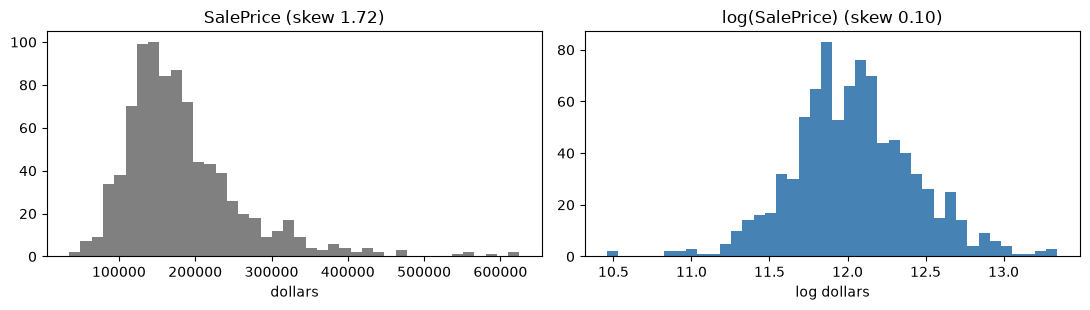

In [63]:
assert not (set(ames_train.index) & set(ames_val.index)) and not (set(ames_train.index) & set(ames_test.index)) \
    and not (set(ames_val.index) & set(ames_test.index)), "splits overlap!"
print(pd.DataFrame({"rows": [len(ames_train), len(ames_val), len(ames_test)],
                    "median price": [s["SalePrice"].median() for s in (ames_train, ames_val, ames_test)]},
                   index=["train", "validation", "test"]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(ames_train["SalePrice"], bins=40, color="gray")
axes[0].set(title=f"SalePrice (skew {ames_train['SalePrice'].skew():.2f})", xlabel="dollars")
axes[1].hist(ames_train["LogPrice"], bins=40, color="steelblue")
axes[1].set(title=f"log(SalePrice) (skew {ames_train['LogPrice'].skew():.2f})", xlabel="log dollars")
plt.tight_layout()
plt.show()

### Step 2 — Preprocessing: impute, scale, one-hot encode

Numeric columns: median imputation + standardization. Categorical columns: an explicit `"missing"` category (in Ames, NaN usually means "no pool", "no garage", …) + one-hot encoding. Rare categories (fewer than 5 training rows) are grouped into an "infrequent" column, so unseen or rare levels at prediction time don't break anything. `MSSubClass` is a *code* for the dwelling type, so we treat it as categorical.

In [64]:
feature_cols = [c for c in ames_train.columns if c not in ("SalePrice", "LogPrice")]
cat_features = ames_train[feature_cols].select_dtypes(exclude="number").columns.tolist() + ["MSSubClass"]
num_features = [c for c in feature_cols if c not in cat_features]


def as_text(frame):
    return frame.astype(str)


def make_preprocessor():
    return make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_features),
        (make_pipeline(FunctionTransformer(as_text, feature_names_out="one-to-one"),
                       OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5, sparse_output=False)), cat_features),
        verbose_feature_names_out=False,
    )


X_ames_tr, X_ames_va = ames_train[feature_cols], ames_val[feature_cols]
design_preview = make_preprocessor().fit(X_ames_tr)
print(f"{len(num_features)} numeric + {len(cat_features)} categorical columns → {len(design_preview.get_feature_names_out())} model columns "
      f"for {len(X_ames_tr)} training rows")

35 numeric + 44 categorical columns → 277 model columns for 873 training rows


`astype(str)` turns a missing category into the text `"nan"`, which then acts as its own "missing" level.

### Step 3 — Baselines to beat (validation)

We report **RMSE on log price** (it measures *relative* error, ≈ "typical % miss", and is the Kaggle metric for this data) and **MAE in dollars** (easy to explain).

In [65]:
def dollar_mae(log_true, log_pred, factor=1.0):
    return mean_absolute_error(np.exp(log_true), np.exp(log_pred) * factor)


def show_project_table(table):
    fmt = {"val RMSE (log)": "{:.4f}".format, "val MAE ($)": "{:,.0f}".format, "columns used": "{:.0f}".format,
           "alpha": "{:.3g}".format, "l1_ratio": "{:.2g}".format, "fit (s)": "{:.2f}".format}
    print(table.to_string(formatters={k: v for k, v in fmt.items() if k in table.columns}))


project_rows = []
median_log = np.full(len(ya_va), np.median(ya_tr))
project_rows.append({"model": "median price (no features)", "val RMSE (log)": root_mean_squared_error(ya_va, median_log),
                     "val MAE ($)": dollar_mae(ya_va, median_log), "columns used": 0})
two_feature = make_pipeline(StandardScaler(), LinearRegression()).fit(ames_train[["OverallQual", "GrLivArea"]], ya_tr)
two_pred = two_feature.predict(ames_val[["OverallQual", "GrLivArea"]])
project_rows.append({"model": "OLS: OverallQual + GrLivArea", "val RMSE (log)": root_mean_squared_error(ya_va, two_pred),
                     "val MAE ($)": dollar_mae(ya_va, two_pred), "columns used": 2})
show_project_table(pd.DataFrame(project_rows).set_index("model"))

                             val RMSE (log) val MAE ($) columns used
model                                                               
median price (no features)           0.4327      58,031            0
OLS: OverallQual + GrLivArea         0.2200      26,664            2


### Step 4 — Regularized candidates (alpha by 5-fold CV on train, compared on validation)

In [66]:
candidates = {
    "OLS (all columns)": LinearRegression(),
    "RidgeCV": RidgeCV(alphas=np.logspace(-1, 3, 30), cv=cv5),
    "LassoCV": LassoCV(alphas=np.logspace(-5, -1, 30), cv=cv5, max_iter=50_000),
    "ElasticNetCV": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-5, 0, 30), cv=cv5, max_iter=50_000),
    "HuberRegressor (alpha=1)": HuberRegressor(alpha=1.0, max_iter=5000),
}
candidate_fits = {}
for name, estimator in candidates.items():
    start = time.perf_counter()
    pipe = make_pipeline(make_preprocessor(), estimator).fit(X_ames_tr, ya_tr)
    seconds = time.perf_counter() - start
    candidate_fits[name] = pipe
    pred = pipe.predict(X_ames_va)
    final = pipe[-1]
    project_rows.append({"model": name, "val RMSE (log)": root_mean_squared_error(ya_va, pred), "val MAE ($)": dollar_mae(ya_va, pred),
                         "columns used": int(np.sum(final.coef_ != 0)), "alpha": getattr(final, "alpha_", getattr(final, "alpha", np.nan)),
                         "l1_ratio": getattr(final, "l1_ratio_", np.nan), "fit (s)": seconds})
project_table = pd.DataFrame(project_rows).set_index("model")
show_project_table(project_table)

winner_name = project_table.drop(index=["median price (no features)", "OLS: OverallQual + GrLivArea"])["val RMSE (log)"].idxmin()
winner = candidate_fits[winner_name]
print(f"\n🏆 validation winner: {winner_name} | val RMSE (log) {project_table.loc[winner_name, 'val RMSE (log)']:.4f} | "
      f"val MAE ${project_table.loc[winner_name, 'val MAE ($)']:,.0f}")

                             val RMSE (log) val MAE ($) columns used    alpha l1_ratio fit (s)
model                                                                                         
median price (no features)           0.4327      58,031            0      NaN      NaN     NaN
OLS: OverallQual + GrLivArea         0.2200      26,664            2      NaN      NaN     NaN
OLS (all columns)                    0.1344      14,986          277      NaN      NaN    0.09
RidgeCV                              0.1305      14,710          277     16.1      NaN    0.17
LassoCV                              0.1294      14,479          102 0.000621      NaN    0.47
ElasticNetCV                         0.1295      14,489          103  0.00117      0.5    1.86
HuberRegressor (alpha=1)             0.1389      15,137          277        1      NaN    0.26

🏆 validation winner: LassoCV | val RMSE (log) 0.1294 | val MAE $14,479


### Step 5 — Diagnostics for the winner

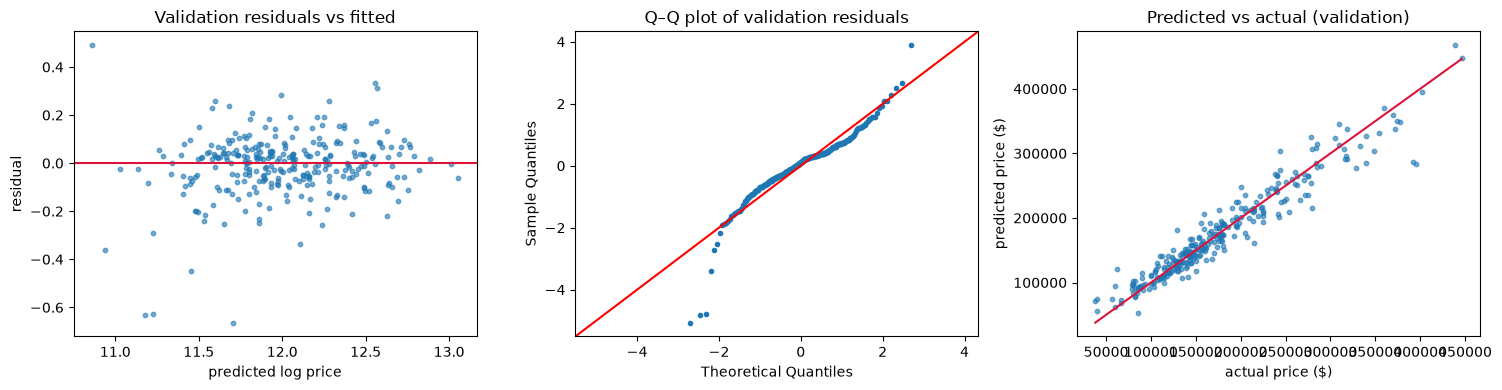

Breusch–Pagan on training residuals vs fitted: p = 0.0135 → spread changes with price level (use robust SEs for inference)
Jarque–Bera on validation residuals: skew -1.11, kurtosis 8.93, p = 2.74e-106

largest validation misses:
    SaleCondition  OverallQual  GrLivArea  YearBuilt  SalePrice  predicted_price  abs_log_error
462        Normal            5        864       1965      62383       121121.224          0.663
966       Abnorml            3        968       1910      37900        71349.977          0.633
30         Normal            4       1317       1920      40000        74866.386          0.627
88        Abnorml            3       1526       1915      85000        52041.201          0.491
410       Abnorml            5       1276       1958      60000        94066.045          0.450
sale conditions among the 5 worst: {'Abnorml': 3, 'Normal': 2} (overall share of non-'Normal' sales in validation: 21%)


In [67]:
fitted_tr = winner.predict(X_ames_tr)
resid_tr = ya_tr - fitted_tr
fitted_va = winner.predict(X_ames_va)
resid_va = ya_va - fitted_va

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted_va, resid_va, s=10, alpha=0.6)
axes[0].axhline(0, color="crimson")
axes[0].set(xlabel="predicted log price", ylabel="residual", title="Validation residuals vs fitted")
sm.qqplot(resid_va, line="45", fit=True, ax=axes[1], markersize=3)
axes[1].set_title("Q–Q plot of validation residuals")
axes[2].scatter(np.exp(ya_va), np.exp(fitted_va), s=10, alpha=0.6)
lims = [np.exp(ya_va).min(), np.exp(ya_va).max()]
axes[2].plot(lims, lims, color="crimson")
axes[2].set(xlabel="actual price (\\$)", ylabel="predicted price (\\$)", title="Predicted vs actual (validation)")
plt.tight_layout()
plt.show()

bp_proj = het_breuschpagan(resid_tr, sm.add_constant(fitted_tr))
jb_proj = jarque_bera(resid_va)
print(f"Breusch–Pagan on training residuals vs fitted: p = {bp_proj[1]:.3g} → "
      f"{'spread changes with price level (use robust SEs for inference)' if bp_proj[1] < 0.05 else 'no evidence of heteroscedasticity'}")
print(f"Jarque–Bera on validation residuals: skew {jb_proj[2]:.2f}, kurtosis {jb_proj[3]:.2f}, p = {jb_proj[1]:.3g}")

worst = ames_val.assign(predicted_price=np.exp(fitted_va), abs_log_error=np.abs(resid_va)).nlargest(5, "abs_log_error")
print("\nlargest validation misses:")
print(worst[["SaleCondition", "OverallQual", "GrLivArea", "YearBuilt", "SalePrice", "predicted_price", "abs_log_error"]].round(3).to_string())
print(f"sale conditions among the 5 worst: {worst['SaleCondition'].value_counts().to_dict()} "
      f"(overall share of non-'Normal' sales in validation: {(ames_val['SaleCondition'] != 'Normal').mean():.0%})")

### Step 6 — Interpretation: what drives price?

**(a) The winner's largest coefficients.** All numeric columns are standardized, so $100(e^{\beta}-1)$ is the % price change per +1 SD. For one-hot columns it's the % difference for houses in that category, relative to a regularized average (with regularization and no dropped level there is no single reference category).

In [68]:
coef_names = winner[0].get_feature_names_out()
winner_coefs = pd.Series(winner[-1].coef_, index=coef_names)
effects = pd.DataFrame({"coef": winner_coefs, "% price change": 100 * (np.exp(winner_coefs) - 1)})
effects = effects[effects["coef"] != 0]
print("top 8 positive:")
print(effects.nlargest(8, "coef").round(3).to_string())
print("\ntop 8 negative:")
print(effects.nsmallest(8, "coef").round(3).to_string())

top 8 positive:
                       coef  % price change
GrLivArea             0.116          12.244
Neighborhood_Crawfor  0.099          10.445
Exterior1st_BrkFace   0.080           8.315
MSZoning_FV           0.078           8.059
Neighborhood_StoneBr  0.072           7.486
OverallQual           0.068           7.005
SaleType_New          0.061           6.328
KitchenQual_Ex        0.058           5.934

top 8 negative:
                        coef  % price change
MSZoning_'C (all)'    -0.217         -19.486
MSSubClass_30         -0.055          -5.310
SaleCondition_Abnorml -0.054          -5.272
CentralAir_N          -0.043          -4.244
MSSubClass_160        -0.035          -3.453
GarageType_nan        -0.032          -3.159
Neighborhood_MeadowV  -0.028          -2.772
PavedDrive_N          -0.028          -2.763


**(b) A small inference model with confidence intervals.** Regularized coefficients are biased on purpose and have no valid p-values. For *explanation* we fit a compact OLS model with `statsmodels` on the training rows, with **HC3 robust** standard errors (Step 5 found heteroscedasticity). `np.log(GrLivArea)` makes its coefficient an **elasticity**: +1% living area → +β% price.

In [69]:
inference_formula = ("LogPrice ~ OverallQual + np.log(GrLivArea) + YearBuilt + TotalBsmtSF + GarageCars"
                     " + C(CentralAir) + C(Neighborhood)")
inference_fit = smf.ols(inference_formula, data=ames_train).fit(cov_type="HC3")
key_terms = ["OverallQual", "np.log(GrLivArea)", "YearBuilt", "TotalBsmtSF", "GarageCars", "C(CentralAir)[T.Y]"]
ci = inference_fit.conf_int().loc[key_terms]
inference_table = pd.DataFrame({"coef": inference_fit.params[key_terms], "HC3 p-value": inference_fit.pvalues[key_terms],
                                "CI low": ci[0], "CI high": ci[1]})
per_unit = {"OverallQual": "+1 quality point", "np.log(GrLivArea)": "+1% living area (elasticity, %)", "YearBuilt": "+10 years newer",
            "TotalBsmtSF": "+100 sq ft basement", "GarageCars": "+1 garage car space", "C(CentralAir)[T.Y]": "has central air"}
scale = {"OverallQual": 1, "np.log(GrLivArea)": None, "YearBuilt": 10, "TotalBsmtSF": 100, "GarageCars": 1, "C(CentralAir)[T.Y]": 1}
readable = []
for term in key_terms:
    if scale[term] is None:                                    # elasticity: already "% per %"
        est, lo, hi = inference_table.loc[term, ["coef", "CI low", "CI high"]]
    else:
        est, lo, hi = (100 * (np.exp(scale[term] * inference_table.loc[term, col]) - 1) for col in ["coef", "CI low", "CI high"])
    readable.append({"term": term, "meaning": per_unit[term], "effect on price (%)": est, "95% CI low": lo, "95% CI high": hi,
                     "HC3 p-value": inference_table.loc[term, "HC3 p-value"]})
print(pd.DataFrame(readable).set_index("term").to_string(float_format=lambda v: f"{v:.3g}"))
print(f"\nn = {int(inference_fit.nobs)} | adjusted R² = {inference_fit.rsquared_adj:.3f} | "
      f"validation RMSE (log) of this compact model: {root_mean_squared_error(ya_va, inference_fit.predict(ames_val)):.4f}")
compact_exog = sm.add_constant(ames_train[["OverallQual", "GrLivArea", "YearBuilt", "TotalBsmtSF", "GarageCars"]].astype(float)).to_numpy()
print("VIF of the numeric predictors:", {name: round(variance_inflation_factor(compact_exog, i + 1), 2)
                                         for i, name in enumerate(["OverallQual", "GrLivArea", "YearBuilt", "TotalBsmtSF", "GarageCars"])})

                                            meaning  effect on price (%)  95% CI low  95% CI high  HC3 p-value
term                                                                                                          
OverallQual                        +1 quality point                 8.21        6.68         9.77     2.78e-27
np.log(GrLivArea)   +1% living area (elasticity, %)                0.418       0.371        0.466     8.65e-67
YearBuilt                           +10 years newer                 1.35        0.45         2.25      0.00318
TotalBsmtSF                     +100 sq ft basement                 1.63        1.28         1.97     1.18e-20
GarageCars                      +1 garage car space                 6.69        4.28         9.16     2.73e-08
C(CentralAir)[T.Y]                  has central air                   16        9.33         23.1     9.09e-07

n = 873 | adjusted R² = 0.871 | validation RMSE (log) of this compact model: 0.1559
VIF of the numeric predicto

### Step 7 — Freeze the choices, refit on train + validation, evaluate once on test

We keep the winner's hyperparameters **fixed** (no new search), refit on train + validation (more data, same recipe), estimate Duan's smearing factor from those residuals, and score the untouched test set once.

In [70]:
def frozen(name, fitted_pipe):
    """The winning estimator with its chosen hyperparameters fixed (no CV inside)."""
    est = fitted_pipe[-1]
    if name == "RidgeCV":
        return Ridge(alpha=est.alpha_)
    if name == "LassoCV":
        return Lasso(alpha=est.alpha_, max_iter=50_000)
    if name == "ElasticNetCV":
        return ElasticNet(alpha=est.alpha_, l1_ratio=est.l1_ratio_, max_iter=50_000)
    if name.startswith("HuberRegressor"):
        return HuberRegressor(alpha=est.alpha, max_iter=5000)
    return LinearRegression()


ames_trval = pd.concat([ames_train, ames_val])
final_model = make_pipeline(make_preprocessor(), frozen(winner_name, winner)).fit(ames_trval[feature_cols], ames_trval["LogPrice"])
smear_final = np.mean(np.exp(ames_trval["LogPrice"] - final_model.predict(ames_trval[feature_cols])))

# ---- the one and only look at the test set ----
log_pred_test = final_model.predict(ames_test[feature_cols])
price_pred_test = np.exp(log_pred_test) * smear_final
y_test_log, y_test_price = ames_test["LogPrice"].to_numpy(), ames_test["SalePrice"].to_numpy()
test_results = {
    "RMSE (log price)": root_mean_squared_error(y_test_log, log_pred_test),
    "R² (log price)": r2_score(y_test_log, log_pred_test),
    "MAE ($)": mean_absolute_error(y_test_price, price_pred_test),
    "RMSE ($)": root_mean_squared_error(y_test_price, price_pred_test),
    "MAPE": mean_absolute_percentage_error(y_test_price, price_pred_test),
    "baseline MAE: median train+val price ($)": mean_absolute_error(y_test_price, np.full(len(y_test_price), ames_trval["SalePrice"].median())),
}
for name, value in test_results.items():
    print(f"{name:44s} {value:,.4f}" if abs(value) < 10 else f"{name:44s} {value:,.0f}")

RMSE (log price)                             0.0990
R² (log price)                               0.9264
MAE ($)                                      12,318
RMSE ($)                                     16,859
MAPE                                         0.0736
baseline MAE: median train+val price ($)     51,920


### Step 8 — Conclusions (computed)

In [71]:
val_rmse_winner = project_table.loc[winner_name, "val RMSE (log)"]
gap = test_results["RMSE (log price)"] - val_rmse_winner
ols_all = project_table.loc["OLS (all columns)", "val RMSE (log)"]
baseline_two = project_table.loc["OLS: OverallQual + GrLivArea", "val RMSE (log)"]
print(f"1. {winner_name} won on validation (RMSE log {val_rmse_winner:.4f}) vs unregularized OLS on all columns ({ols_all:.4f}) "
      f"and the 2-feature baseline ({baseline_two:.4f}).")
if abs(gap) < 0.02:
    gap_note = "validation was a reliable guide"
elif gap < 0:
    gap_note = ("test error is LOWER than validation: with ~290 houses per split, scores move by a few hundredths between random "
                "subsets, so quote a range (e.g. CV mean ± std), not one number")
else:
    gap_note = "test error is higher than validation: some overfitting to validation or a harder test subset; report it honestly"
print(f"2. Test RMSE (log) {test_results['RMSE (log price)']:.4f} vs validation {val_rmse_winner:.4f} (gap {gap:+.4f}) → {gap_note}.")
print(f"3. Typical miss on test: ${test_results['MAE ($)']:,.0f} (MAPE {test_results['MAPE']:.1%}) vs "
      f"${test_results['baseline MAE: median train+val price ($)']:,.0f} for always predicting the median price.")
top_driver = pd.DataFrame(readable).set_index("term")["effect on price (%)"]
print(f"4. Compact inference model (HC3): +1 quality point ≈ {top_driver['OverallQual']:+.1f}% price; +1% living area ≈ "
      f"{top_driver['np.log(GrLivArea)']:+.2f}% price; +10 years newer ≈ {top_driver['YearBuilt']:+.1f}%.")
print(f"5. Diagnostics: Breusch–Pagan p = {bp_proj[1]:.2g}, so report robust intervals; the largest misses were mostly "
      f"'{worst['SaleCondition'].mode().iloc[0]}' sales.")

1. LassoCV won on validation (RMSE log 0.1294) vs unregularized OLS on all columns (0.1344) and the 2-feature baseline (0.2200).
2. Test RMSE (log) 0.0990 vs validation 0.1294 (gap -0.0304) → test error is LOWER than validation: with ~290 houses per split, scores move by a few hundredths between random subsets, so quote a range (e.g. CV mean ± std), not one number.
3. Typical miss on test: $12,318 (MAPE 7.4%) vs $51,920 for always predicting the median price.
4. Compact inference model (HC3): +1 quality point ≈ +8.2% price; +1% living area ≈ +0.42% price; +10 years newer ≈ +1.3%.
5. Diagnostics: Breusch–Pagan p = 0.014, so report robust intervals; the largest misses were mostly 'Abnorml' sales.


**Stretch goals**
1. Add engineered features (total square footage, house age at sale, bathrooms per bedroom) and see whether the winner changes.
2. Replace `min_frequency=5` with target encoding (`TargetEncoder`, cross-fitted) for `Neighborhood` and compare.
3. Fit `QuantileRegressor(quantile=0.1 / 0.9)` to get price *ranges* and check their validation coverage.
4. Compare with `HistGradientBoostingRegressor` using the same splits: how much accuracy does non-linearity buy on 1,400 houses?
5. Use `statsmodels` `get_prediction` on the compact model to build prediction intervals, then check how many test houses fall inside (after freezing everything).

### 🗣️ How to talk about this in an interview
- "I modelled **log price**, because prices are skewed and effects are multiplicative, and I corrected the back-transform bias with Duan's smearing factor when reporting dollars."
- "Alpha was chosen by 5-fold CV inside the training data, models were compared on a validation split, and the test set was scored exactly once after freezing all choices."
- "With about 300 one-hot columns for 870 rows, unregularized OLS overfits; Ridge/Lasso/ElasticNet control variance, and Lasso doubles as feature selection."
- "For explanation I used a separate compact OLS model with HC3 robust standard errors, because the diagnostics showed heteroscedasticity, and I reported effects as percentages with confidence intervals, not as causal claims."
- "The biggest errors were unusual sales (e.g. partial or abnormal sale conditions): a candidate for a separate model, a feature, or a business rule."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What are the assumptions of linear regression, and what happens when each one is violated?**

<details><summary>Show answer</summary>

- **30-second answer:** Linearity (the mean of y is linear in the parameters), independent errors, constant error variance (homoscedasticity), normally distributed errors, and no perfect multicollinearity. Violated linearity biases predictions. Dependence and heteroscedasticity leave coefficients unbiased but make **standard errors and p-values wrong**. Non-normality mostly affects small-sample intervals. Multicollinearity inflates coefficient variance without hurting predictions.
- **Go deeper:** Name the diagnostics: residuals vs fitted and component plots (linearity), Durbin–Watson or residual maps in a meaningful order (independence), scale–location plot + Breusch–Pagan/White (variance), Q–Q plot + Jarque–Bera (normality), VIF (collinearity). Fixes: transforms/splines, clustered or HAC SEs, HC3 robust SEs or WLS, bootstrap, Ridge. Also mention **exogeneity** ($E[\varepsilon \mid X] = 0$): omitted confounders bias coefficients, and no diagnostic plot reveals that.
- **❌ Common wrong answer:** "The features (or y) must be normally distributed." The assumption is about the **errors**, conditional on X.

</details>

**Q2. Derive the OLS estimator. When is it not unique, and how do you compute it in practice?**

<details><summary>Show answer</summary>

- **30-second answer:** Minimize $\lVert y - X\beta\rVert^2$. The gradient $-2X^\top(y - X\beta)$ set to zero gives the normal equations $X^\top X\beta = X^\top y$, so $\hat\beta = (X^\top X)^{-1}X^\top y$. It is unique when $X$ has full column rank. With perfectly collinear columns (a dummy trap, or $p > n$) there are infinitely many solutions.
- **Go deeper:** Don't invert: use QR or SVD (`lstsq`), since forming $X^\top X$ squares the condition number. Cost is $O(np^2 + p^3)$. Rank-deficient cases: `lstsq`/`pinv` return the minimum-norm solution, and Ridge makes $X^\top X + \alpha I$ invertible. Under the Gauss–Markov assumptions OLS is **BLUE** (best linear unbiased estimator).
- **❌ Common wrong answer:** "Just compute `inv(X.T @ X) @ X.T @ y`, it always works."

</details>

**Q3. Give a geometric interpretation of least squares.**

<details><summary>Show answer</summary>

- **30-second answer:** $\hat y$ is the **orthogonal projection** of $y$ onto the column space of $X$, so the residual vector is perpendicular to every column: $X^\top e = 0$. The projection matrix is $H = X(X^\top X)^{-1}X^\top$.
- **Go deeper:** $H$ is symmetric and idempotent with trace $p+1$. Its diagonal entries are the leverages. Pythagoras gives TSS = ESS + RSS (with an intercept), which is why in-sample R² is in [0, 1]. Consequence: in-sample residuals are uncorrelated with each feature by construction, so linear trends in residual-vs-feature plots can't appear, only curves.
- **❌ Common wrong answer:** "It minimizes the perpendicular distance from the points to the line." That's total least squares / PCA. OLS minimizes **vertical** distances.

</details>

**Q4. What's the difference between R² and adjusted R²? Can R² be negative?**

<details><summary>Show answer</summary>

- **30-second answer:** R² = 1 − RSS/TSS, the share of variance explained. In-sample it never decreases when you add features, even pure noise. Adjusted R² $= 1-(1-R^2)\frac{n-1}{n-p-1}$ penalizes extra features. Out of sample, R² **can be negative**: the model is worse than predicting the mean.
- **Go deeper:** We showed 40 noise columns raising training R² while adjusted R² barely moved and validation R² fell. R² depends on the target's variance in the evaluation set (a narrow slice of districts gave a much lower R² at similar RMSE). For model selection prefer cross-validated error, AIC/BIC, or adjusted R² only in-sample.
- **❌ Common wrong answer:** "Higher R² always means a better model" or "R² is between 0 and 1 by definition."

</details>

**Q5. Ridge vs Lasso: what's the difference, and why does Lasso give exactly zero coefficients?**

<details><summary>Show answer</summary>

- **30-second answer:** Ridge adds $\alpha\lVert\beta\rVert_2^2$: it shrinks all coefficients smoothly and keeps every feature. Lasso adds $\alpha\lVert\beta\rVert_1$ and produces sparse models. The L1 penalty's pull on a coefficient is a constant $\alpha$ even near zero, so any coefficient whose data signal is weaker than $\alpha$ is soft-thresholded to exactly 0. Geometrically, the L1 ball is a diamond whose corners lie on the axes, and the loss contours tend to touch it at a corner.
- **Go deeper:** Orthonormal case: Lasso $= \text{sign}(b)\max(|b|-\lambda, 0)$, Ridge $= b/(1+\lambda)$. With correlated features Lasso picks one arbitrarily and is unstable; ElasticNet fixes that. Ridge has a closed form; Lasso uses coordinate descent or LARS. Bayesian view: Ridge = Gaussian prior (MAP), Lasso = Laplace prior. Standardize first, don't penalize the intercept, and choose alpha by CV (`RidgeCV`, `LassoCV`).
- **❌ Common wrong answer:** "Ridge also sets coefficients to zero, just fewer of them," or "Lasso is always better because it does feature selection."

</details>

**Q6. What is multicollinearity? How do you detect it, and does it hurt predictions?**

<details><summary>Show answer</summary>

- **30-second answer:** Features that are (nearly) linear combinations of each other. It makes $X^\top X$ ill-conditioned, so coefficient **variances explode**: coefficients become unstable, can flip sign, and get large p-values even when the group is clearly useful. Predictions within the data's range are largely unaffected. Detect it with correlation matrices, **VIF** $= 1/(1-R_j^2)$ (> 5–10 is a warning), or the condition number.
- **Go deeper:** We showed coefficient instability across bootstrap samples tracking VIF, and `AveBedrms` flipping sign once `AveRooms` was included. Fixes: drop or combine features, use domain ratios, Ridge, PCA/PLS, or test the group jointly with an F-test. It hurts predictions when the correlation structure changes in production.
- **❌ Common wrong answer:** "Multicollinearity biases the coefficients" (they stay unbiased, just very noisy), or "it ruins the model's accuracy."

</details>

**Q7. What does the p-value of a regression coefficient tell you, and what doesn't it tell you?**

<details><summary>Show answer</summary>

- **30-second answer:** Assuming the model's assumptions hold, it's the probability of seeing a t-statistic at least this extreme **if the true coefficient were zero**, given the other features in the model. A small p-value means the data are hard to reconcile with a zero effect *conditional on the other features*.
- **Go deeper:** It is not the probability that the feature is useless, not an effect size, and not causal. With huge n, trivial effects become "significant". Testing many features gives false positives (we found noise columns with p < 0.05). Classical p-values are wrong under heteroscedasticity or clustering (use HC3/cluster SEs), and invalid after data-driven selection (e.g. running OLS on Lasso-selected features). Report confidence intervals.
- **❌ Common wrong answer:** "p = 0.03 means there's a 97% chance the feature matters."

</details>

**Q8. What is heteroscedasticity, why does it matter, and how do you handle it?**

<details><summary>Show answer</summary>

- **30-second answer:** Error variance that changes with the features or the fitted value (the "funnel" in a residual plot). OLS coefficients remain unbiased, but the usual standard errors, p-values and prediction intervals are wrong, and OLS is no longer the most efficient estimator. Detect it with a residual plot and the Breusch–Pagan or White test.
- **Go deeper:** Fixes: heteroscedasticity-robust (HC3) standard errors (`fit(cov_type="HC3")`), transforming y (log for prices), weighted least squares when you can model the variance, or modelling the variance explicitly (GLMs, quantile regression). In our California model, HC3 standard errors were up to about 3× the classical ones, and 95% prediction intervals covered very different shares of districts across price levels.
- **❌ Common wrong answer:** "It biases the coefficients, so the model is useless."

</details>

**Q9. When would you use statsmodels instead of scikit-learn for linear regression?**

<details><summary>Show answer</summary>

- **30-second answer:** statsmodels for **inference**: standard errors, p-values, confidence and prediction intervals, robust or clustered SEs, R-style formulas with categoricals and interactions, and diagnostic tests. scikit-learn for **prediction**: pipelines, cross-validation, hyperparameter search, regularization, and deployment. Both fit identical OLS coefficients.
- **Go deeper:** Common combination: build and validate a predictive pipeline in scikit-learn, and explain a compact model in statsmodels with HC3 intervals (as in the Mini Project). Regularized coefficients (Ridge/Lasso) are biased by design, so don't attach classical p-values to them. For A/B tests, a statsmodels regression with covariates (CUPED-style adjustment) gives the effect and its CI.
- **❌ Common wrong answer:** "They are interchangeable" or "statsmodels is just the older, slower version."

</details>

**Q10. MAE or RMSE: how do you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** It depends on the cost of errors. RMSE (squared loss) penalizes large errors heavily and is minimized by the **conditional mean**. MAE penalizes linearly, is robust to outliers, and is minimized by the **conditional median**. If one \$200k miss is much worse than four \$50k misses, use RMSE. If not, MAE.
- **Go deeper:** RMSE ≥ MAE always; a large ratio reveals a few big errors (one bad prediction multiplied our RMSE far more than our MAE). For relative errors use RMSE on log(y) or MAPE (which explodes near y = 0 and punishes over- and under-prediction asymmetrically). Train with the loss that matches the metric: `HuberRegressor`, `QuantileRegressor(quantile=0.5)` for MAE.
- **❌ Common wrong answer:** "RMSE is always better because it's differentiable."

</details>

**Q11. Why must features be scaled for Ridge, Lasso and gradient descent, but not for OLS? And why isn't the intercept penalized?**

<details><summary>Show answer</summary>

- **30-second answer:** OLS predictions are invariant to rescaling a feature (its coefficient just rescales). A penalty on $\lVert\beta\rVert$ is not: a feature in large units needs a tiny coefficient and escapes the penalty, while a small-unit feature is crushed. Gradient descent needs scaling because unequal scales create a long, thin loss valley and force a tiny learning rate. The intercept isn't penalized because it only sets the prediction's level: penalizing it would shrink predictions toward 0 and make the model depend on the arbitrary origin of y.
- **Go deeper:** We showed Lasso keeping and dropping different Ames features with and without scaling, and a penalized intercept moving by less than a shift added to y. Implementation: $D = \text{diag}(0, 1, \dots, 1)$ in the closed form, or center X and y first. Fit the scaler inside a pipeline so CV folds don't leak.
- **❌ Common wrong answer:** "Scaling improves OLS accuracy" or "the intercept is penalized like any other weight."

</details>

### 💻 Coding

**Q12. Implement linear regression with batch gradient descent in NumPy, and the Ridge closed form.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def fit_gd(X, y, lr=0.1, epochs=2000):
      mu, sd = X.mean(0), X.std(0)
      Z = np.c_[np.ones(len(X)), (X - mu) / sd]          # scale + intercept column
      w = np.zeros(Z.shape[1])
      for _ in range(epochs):
          w -= lr * 2 / len(y) * Z.T @ (Z @ w - y)       # gradient of MSE
      slopes = w[1:] / sd
      return w[0] - slopes @ mu, slopes                  # back to raw units

  def ridge(X, y, alpha):
      A = np.c_[np.ones(len(X)), X]
      D = np.eye(A.shape[1]); D[0, 0] = 0                # don't penalize the intercept
      beta = np.linalg.solve(A.T @ A + alpha * D, A.T @ y)
      return beta[0], beta[1:]
  ```
- **Go deeper:** Mention convergence (η < 2/λ_max of $\frac{2}{n}X^\top X$), a stopping rule on the gradient norm, mini-batches for large n, and verifying against `LinearRegression`/`Ridge` with `np.allclose` (done in 🔧 Build It From Scratch). For the closed form use `solve`, not `inv`.
- **❌ Common wrong answer:** Forgetting the intercept, not scaling (so GD diverges or crawls), or penalizing the intercept in Ridge.

</details>

### 🐛 Debugging Scenarios

**Q13. A stakeholder asks why "number of bedrooms" has a negative coefficient in your house-price model. What do you say and check?**

<details><summary>Show answer</summary>

- **30-second answer:** The coefficient is the effect of one more bedroom **holding the other features fixed**, including total rooms and living area. For a fixed size, more bedrooms means smaller rooms, which can lower the price. Check correlations and VIF, compare with the simple regression (the sign often flips), and look at the confidence interval: an unstable coefficient may not be distinguishable from zero.
- **Go deeper:** Bootstrap the coefficient to show instability. Consider removing one of the collinear features, combining them (rooms per bedroom), or Ridge. For communication, show partial dependence or the effect of a realistic scenario ("adding a bedroom *and* 150 sq ft"). Never present it as causal without a design that supports causality.
- **❌ Common wrong answer:** "The model is broken, drop the feature" or "bedrooms reduce value."

</details>

**Q14. Your regression has training R² = 0.95 but validation R² = −3. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Severe overfitting or extrapolation. Typical causes: too many features for the rows (polynomial expansion, many one-hot columns), no regularization, leakage in training features that isn't available at validation, or a few extreme validation rows outside the training range where a flexible model explodes. A negative R² means the model is worse than predicting the mean.
- **Go deeper:** We saw exactly this with a degree-4 polynomial on 400 rows: training RMSE ≈ 0 and validation RMSE orders of magnitude larger than the plain linear model's, driven by unusual feature values. Debug with learning curves, the train/validation gap vs number of features, per-row errors (a handful of huge ones?), feature ranges in validation vs training, and a leakage audit. Fixes: Ridge/Lasso chosen by CV, fewer features, clipping or transforming extreme features, more data.
- **❌ Common wrong answer:** "R² can't be negative, so there must be a bug in scikit-learn."

</details>

### 🏗️ Design

**Q15. Design a price-estimate model for a real-estate platform that must explain its estimates to users and regulators.**

<details><summary>Show answer</summary>

- **30-second answer:** Model log(price) with a regularized linear model (or a GBM with a linear/monotonic explanation layer), using location, size, quality, age and recent-comparables features. Validate with **time-based** splits (train on past sales, test on later ones). Report errors in % and dollars with smearing-corrected back-transforms, show prediction **ranges** (quantile regression or conformal intervals), and explain an estimate as a sum of feature contributions.
- **Go deeper:** Neighbourhood effects need hierarchical/regularized encoding. Interactions (size × neighbourhood) matter. Check residuals by segment for fairness and heteroscedasticity. Monitor drift (interest rates move all prices). Retrain on a schedule and keep a simple, auditable baseline to catch regressions. For "what drives value" reports, use a compact inference model with robust CIs, and say clearly that the coefficients are associations, not causal effects.
- **❌ Common wrong answer:** "Train the most accurate black-box model with a random split and report R²."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `LinearRegression().fit([[0], [1], [2]], [1, 3, 5]).coef_`
<details><summary>Answer</summary>

`array([2.])` — the points lie exactly on $y = 1 + 2x$ (the intercept is `1.0`).
</details>

**2.** `r2_score([1, 2, 3], [2, 2, 2])` and `r2_score([1, 2, 3], [3, 3, 3])`
<details><summary>Answer</summary>

`0.0` and `-1.5`. Predicting the mean gives R² = 0; a constant that isn't the mean is worse than that, so R² is negative (RSS = 5 vs TSS = 2).
</details>

**3.** How many columns does `PolynomialFeatures(degree=2)` output for 3 input features?
<details><summary>Answer</summary>

**10** = $\binom{3+2}{2}$: the constant, 3 linear terms, 3 squares, 3 pairwise products.
</details>

**4.** `m = Lasso(alpha=1e6).fit([[0.], [1.], [2.], [3.]], [1., 2., 3., 10.])` — what are `m.coef_` and `m.intercept_`?
<details><summary>Answer</summary>

`array([0.])` and `4.0`. A huge L1 penalty zeroes every coefficient, and the unpenalized intercept becomes the mean of y.
</details>

**5.** `Ridge(alpha=1e6).fit([[0.], [1.], [2.]], [10., 11., 12.]).intercept_` — close to 0, or close to 11?
<details><summary>Answer</summary>

About **11.0** (the slope is ≈ 2e-6). scikit-learn never penalizes the intercept, so heavy Ridge shrinks the slope toward 0 and the intercept becomes the mean of y.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — 1.1. Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) — OLS, Ridge, Lasso, ElasticNet, Huber, SGD, with their exact objectives
- [scikit-learn — Common pitfalls in the interpretation of coefficients of linear models](https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html) — scaling, correlated features, coefficient variability
- [scikit-learn — HuberRegressor vs Ridge on dataset with strong outliers](https://scikit-learn.org/stable/auto_examples/linear_model/plot_huber_vs_ridge.html) — robust regression in pictures
- [scikit-learn — 1.5. Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html) — `SGDRegressor`, learning-rate schedules, tips for scaling
- [statsmodels — Linear Regression](https://www.statsmodels.org/stable/regression.html) — OLS, WLS, GLS, results attributes
- [statsmodels — Regression Diagnostics and Specification Tests](https://www.statsmodels.org/stable/diagnostic.html) — Breusch–Pagan, White, influence, VIF
- [statsmodels — Regression diagnostics](https://www.statsmodels.org/stable/examples/notebooks/generated/regression_diagnostics.html) — worked example notebook
- [statsmodels — Fitting models using R-style formulas](https://www.statsmodels.org/stable/example_formulas.html) — `C()`, interactions, transforms

### 🎥 Videos
- [StatQuest (Josh Starmer) — Linear Regression, Clearly Explained!!!](https://www.youtube.com/watch?v=nk2CQITm_eo) (~27 min) — least squares, R² and the p-value of the fit, drawn step by step; pairs with Sections 1–7
- [StatQuest (Josh Starmer) — Regularization Part 1: Ridge (L2) Regression](https://www.youtube.com/watch?v=Q81RR3yKn30) (~20 min) — why a little bias buys a big drop in variance, and choosing λ by cross-validation
- [StatQuest (Josh Starmer) — Regularization Part 2: Lasso (L1) Regression](https://www.youtube.com/watch?v=NGf0voTMlcs) (~8 min) — how Lasso differs from Ridge and why it can remove useless features; watch before Section 10

### 📄 Papers
- [Efron, Hastie, Johnstone & Tibshirani (2004) — Least Angle Regression](https://arxiv.org/abs/math/0406456) — the LARS algorithm and the whole Lasso path
- [Friedman, Hastie & Tibshirani (2010) — Regularization Paths for Generalized Linear Models via Coordinate Descent](https://www.jstatsoft.org/article/view/v033i01) — the glmnet algorithm behind `Lasso`/`ElasticNet` solvers
- [De Cock (2011) — Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project](https://jse.amstat.org/v19n3/decock.pdf) — the Ames dataset, its variables, and the > 4,000 sq ft recommendation (PDF)

### 📘 Books & Courses
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 3 (Linear Regression) and Chapter 6 (Linear Model Selection and Regularization)
- [The Elements of Statistical Learning (free PDF)](https://hastie.su.domains/ElemStatLearn/) — Chapter 3 derives OLS, Ridge, Lasso and LARS at graduate depth
- [Regression and Other Stories (free PDF + examples)](https://avehtari.github.io/ROS-Examples/) — Gelman, Hill & Vehtari on building, checking and interpreting regressions
- [MLU-Explain — Linear Regression](https://mlu-explain.github.io/linear-regression/) — an interactive visual essay from Amazon's Machine Learning University

### 🏋️ Practice
- [Kaggle — House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) — the Ames data from the Mini Project, with a public leaderboard (RMSE on log price)

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| OLS | minimizes squared residuals | $\hat\beta = (X^\top X)^{-1}X^\top y$ · `LinearRegression`, `np.linalg.lstsq` |
| Geometry | projection onto the column space | $H = X(X^\top X)^{-1}X^\top$, $X^\top e = 0$, leverage $h_{ii}$ |
| Gradient descent | iterative OLS for big data | $\beta \leftarrow \beta - \eta\frac{2}{n}X^\top(X\beta - y)$, $\eta < 2/L$ · scale first |
| Diagnostics | trust the fit | residual plots · `sm.qqplot` · `durbin_watson` · `het_breuschpagan` · `variance_inflation_factor` |
| Coefficients | effect holding others fixed | raw (per unit) vs standardized (per SD); log target → $100(e^{b}-1)\%$ |
| Inference | uncertainty of effects | `sm.OLS(y, sm.add_constant(X)).fit(cov_type="HC3")` · `.conf_int()` · `.get_prediction().summary_frame()` |
| Categoricals & interactions | group offsets and slopes | `smf.ols("y ~ x * C(g)")` · `OneHotEncoder(drop="first")` · `compare_f_test` |
| Polynomial features | curves with a linear model | `PolynomialFeatures(d)` → $\binom{p+d}{d}$ columns; regularize |
| Ridge / Lasso / ElasticNet | shrink / select / both | `RidgeCV`, `LassoCV`, `ElasticNetCV`, `lasso_path` · standardize · intercept unpenalized |
| Outliers & robust | limit influence of big residuals | `OLSInfluence` (Cook's D, leverage) · `HuberRegressor(epsilon=1.35)` |
| Metrics | error in context | MAE (median), RMSE (mean), R², adjusted R² $= 1-(1-R^2)\frac{n-1}{n-p-1}$ |
| Large data | streaming fits | `SGDRegressor` + `StandardScaler`, `partial_fit` |
| Log targets | multiplicative effects | predict $\exp(\hat y)\times$ smearing factor $\overline{e^{\text{resid}}}$ |

## ➡️ What's Next

**[04 · Logistic Regression](04_Logistic_Regression.ipynb)** — keep the same linear score $\beta_0 + \beta^\top x$, pass it through a sigmoid, and you get probabilities for classification. You'll reuse gradient descent, regularization, `statsmodels` inference (now as odds ratios) and the diagnostics mindset from this notebook.